# Validación mediante escenarios sintéticos

Notebook independiente para la construcción y validación del modelo Risk(t) mediante escenarios sintéticos.
No reentrena ni modifica el
clasificador StressLoad(t) — parte de los datos ya procesados y del modelo ya entrenado
en `01_WESAD_preprocesamiento.ipynb` y `02_StressLoad.ipynb`.

**Sujetos utilizados:** exclusivamente los 4 sujetos reservados (`S5, S6, S10, S11`),
excluidos por diseño del entrenamiento/LOSO del clasificador — nunca se usan aquí datos
de los 11 sujetos de entrenamiento, para evitar cualquier circularidad entre
entrenamiento y validación.

### Fases de validación

La matriz completa de escenarios tiene 3 ejes: intensidad de estrés (2 niveles:
ninguno/alto), patrón de dosificación (3: a tiempo/retrasada/omitida) y timing del
*bout* de estrés respecto al ciclo de dosis (3 niveles: en el valle de cobertura / a mitad
del intervalo  / justo tras la toma ) — 2×3×3 = 18 combinaciones en total.

- **Nivel 1** : en el valle de cobertura. 
- **Nivel 2** : justo tras la toma. 
- **Nivel 3** : a mitad del intervalo

### Índice de capítulos

1. **Preparación de datos** — carga, filtrado y extracción de los segmentos reales.
2. **Creación del día sintético** — fondo generado por bootstrap, ensamblaje, features y clasificador (común a las tres fases).
3. **Fase 1** — timing en el valle de cobertura.
4. **Fase 2** — timing justo tras la toma.
5. **Fase 3** — timing a mitad del intervalo.
6. **Conclusiones generales**


# 1. Preparación de datos

Carga del dataset maestro y del clasificador ya entrenados en `01_WESAD_preprocesamiento.ipynb`
y `02_StressLoad.ipynb`, filtrado a los 4 sujetos reservados para escenarios sintéticos, y extracción
de los segmentos reales (Relajado; Transición+Estresado+Rest+Recuperación) que sirven de semilla para
todo lo que sigue. Este capítulo no depende de qué fase se vaya a construir después — es común a las tres.

## 1.1 Carga de configuración y del dataset maestro

Se reutiliza el mismo `WESAD_config_rutas.json` que ya usan los otros dos notebooks,
para no duplicar rutas y evitar el riesgo de que diverjan. Este notebook debe vivir en la
misma carpeta que ese archivo de configuración.

Se parte del dataset maestro **a 1 minuto** (no el de 1Hz) — es el que ya tiene
calculadas las columnas normalizadas (`HR_mean_norm`) y las de rolling/lag que el
modelo Camino B espera como input.

In [1]:
# ======================================================================================================
# IMPORTS Y CARGA DEL MAPA DE RUTAS
# ======================================================================================================
import json
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

# Mismo patrón de carga de configuración que en los otros dos notebooks del proyecto
ruta_config = Path("WESAD_config_rutas.json")
if not ruta_config.exists():
    raise FileNotFoundError("No se encontró 'WESAD_config_rutas.json'. Este notebook debe "
                             "colocarse en la misma carpeta que los otros notebooks del proyecto.")

with open(ruta_config, "r", encoding="utf-8") as f:
    config = json.load(f)

print("Configuración cargada correctamente.")

Configuración cargada correctamente.


In [2]:
# ======================================================================================================
# CARGA DEL DATASET MAESTRO A 1 MINUTO
# ======================================================================================================
# Usamos la misma ruta que ya emplea 02_StressLoad.ipynb para cargar el dataset de entrenamiento —
# aquí no reentrenamos nada, solo leemos el mismo parquet como fuente de segmentos reales.

ruta_parquet_1min = Path(config["rutas_procesamiento"]["ruta_salida_parquet_1min"])

df = pd.read_parquet(ruta_parquet_1min)

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas.")
print(f"Sujetos presentes: {sorted(df['ID_sujeto'].unique().tolist())}")

Dataset cargado: 1425 filas, 89 columnas.
Sujetos presentes: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


## 1.2 Filtrado a los sujetos reservados y comprobación de sensatez.

Se filtra el dataset maestro a `RESERVED_SUBJECTS = ['S5', 'S6', 'S10', 'S11']` (fijados en `02_StressLoad.ipynb`, seed=42) y se comprueba la distribución de `Etiqueta` por sujeto antes de extraer ningún segmento.

In [3]:
# ======================================================================================================
# FILTRADO A LOS SUJETOS RESERVADOS PARA ESCENARIOS SINTÉTICOS
# ======================================================================================================
RESERVED_SUBJECTS = ['S5', 'S6', 'S10', 'S11']  # fijados en 02_StressLoad.ipynb (seed=42)

df_reservados = df[df['ID_sujeto'].isin(RESERVED_SUBJECTS)].copy()

print(f"Filas tras filtrar: {df_reservados.shape[0]}")
print(f"Sujetos: {sorted(df_reservados['ID_sujeto'].unique().tolist())}")

Filas tras filtrar: 388
Sujetos: ['S10', 'S11', 'S5', 'S6']



--- Sujeto S5 ---
Etiqueta
0    45
1    20
2    11
3     6
4    12
5     1
7     1
Name: count, dtype: int64
Orden real de aparición (minuto_id, Etiqueta):
 minuto_id  Etiqueta
         0         0
         4         1
        24         5
        30         3
        39         7
        44         4
        59         2

--- Sujeto S6 ---
Etiqueta
0    63
1    19
2    11
3     6
4    14
5     1
7     1
Name: count, dtype: int64
Orden real de aparición (minuto_id, Etiqueta):
 minuto_id  Etiqueta
         0         0
        10         1
        30         5
        40         2
        74         4
        92         3
       103         7

--- Sujeto S10 ---
Etiqueta
0    37
1    19
2    12
3     6
4    14
5     1
6     1
7     1
Name: count, dtype: int64
Orden real de aparición (minuto_id, Etiqueta):
 minuto_id  Etiqueta
         0         0
         1         1
        21         5
        26         3
        33         7
        36         4
        52         2
        69      

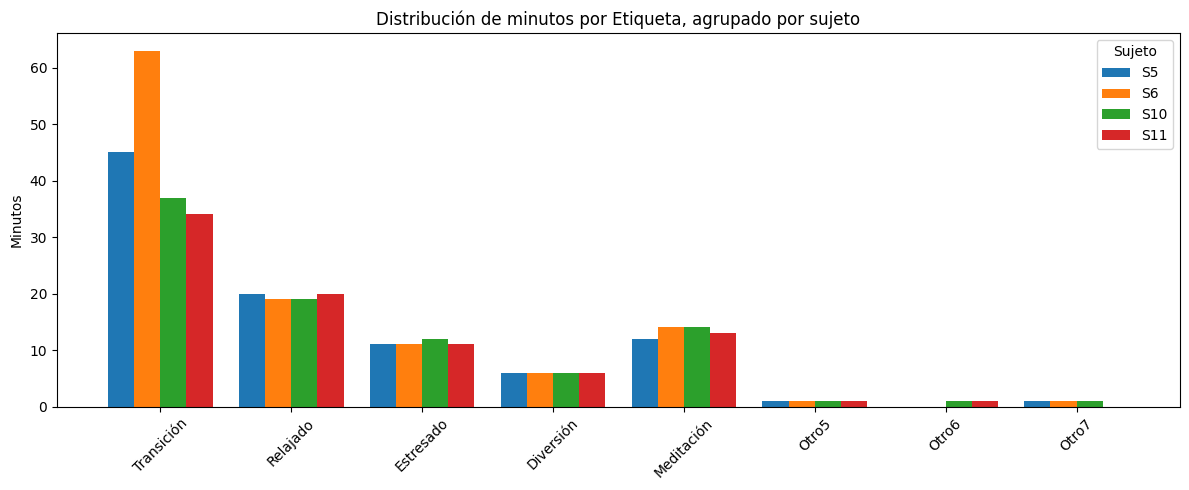

In [4]:
# ======================================================================================================
# COMPROBACIÓN DE SENSATEZ: DISTRIBUCIÓN DE ETIQUETA POR SUJETO
# ======================================================================================================
# Etiqueta: 1=Relajado (baseline), 2=Estresado (TSST), 3=Diversión, 4=Meditación
# (0=Transición, 5-7=Otros — no nos interesan para los escenarios)

for sujeto in RESERVED_SUBJECTS:
    df_suj = df_reservados[df_reservados['ID_sujeto'] == sujeto].sort_values('minuto_id')
    print(f"\n--- Sujeto {sujeto} ---")
    print(df_suj['Etiqueta'].value_counts().sort_index())

    # Orden cronológico real de aparición de cada Etiqueta (primera vez que aparece cada una)
    orden_aparicion = df_suj.drop_duplicates('Etiqueta', keep='first')[['minuto_id', 'Etiqueta']]
    print("Orden real de aparición (minuto_id, Etiqueta):")
    print(orden_aparicion.to_string(index=False))

# ======================================================================================================
# VISUALIZACIÓN: DISTRIBUCIÓN DE ETIQUETA — BARRAS AGRUPADAS, 4 SUJETOS POR ETIQUETA
# ======================================================================================================
ETIQUETAS_NOMBRE = {0: 'Transición', 1: 'Relajado', 2: 'Estresado', 3: 'Diversión',
                    4: 'Meditación', 5: 'Otro5', 6: 'Otro6', 7: 'Otro7'}

# Tabla sujeto x etiqueta, con 0 donde un sujeto no tenga esa etiqueta (evita desalinear las barras)
tabla = (
    df_reservados[df_reservados['ID_sujeto'].isin(RESERVED_SUBJECTS)]
    .groupby(['Etiqueta', 'ID_sujeto']).size()
    .unstack(fill_value=0)
    .reindex(columns=RESERVED_SUBJECTS)
    .sort_index()
)
etiquetas_texto = [ETIQUETAS_NOMBRE.get(e, str(e)) for e in tabla.index]

x = np.arange(len(tabla.index))
ancho_barra = 0.8 / len(RESERVED_SUBJECTS)

fig, ax = plt.subplots(figsize=(12, 5))
for i, sujeto in enumerate(RESERVED_SUBJECTS):
    ax.bar(x + i * ancho_barra, tabla[sujeto].values, width=ancho_barra, label=sujeto)

ax.set_xticks(x + ancho_barra * (len(RESERVED_SUBJECTS) - 1) / 2)
ax.set_xticklabels(etiquetas_texto, rotation=45)
ax.set_ylabel('Minutos')
ax.set_title('Distribución de minutos por Etiqueta, agrupado por sujeto')
ax.legend(title='Sujeto')
plt.tight_layout()
plt.show()

Los 4 sujetos (S5, S6, S10, S11) tienen presentes todas las condiciones necesarias para la
extracción de segmentos: Relajado (19-20 min), Estresado (11-12 min), Diversión (6 min) y
Meditación (12-14 min, repartidos en dos bloques por sujeto — Medi I y Medi II). Transición
(Etiqueta 0) es, como cabía esperar por el propio diseño del protocolo, el bloque más largo en
los 4 casos (34-63 min) — son los tramos de espera/instrucciones entre condiciones, no un
problema de calidad de datos. Los códigos residuales (5, 6, 7) aparecen solo 1 minuto cada uno,
consistente con marcas puntuales del protocolo sin relevancia para el pipeline.

El gráfico de barras agrupadas confirma visualmente lo mismo: ninguna condición necesaria falta
en ningún sujeto, y las magnitudes relativas entre sujetos son comparables, sin ningún caso
claramente atípico en esta comprobación — la variabilidad real entre sujetos (por ejemplo, el
mayor volumen de Transición en S6) se investiga más adelante si resulta relevante, no aquí.

Con esto, se da por cerrada la comprobación de sensatez inicial y se pasa a la detección de
bloques contiguos (Sección 1.3).

## 1.3 Detección de bloques contiguos por sujeto.

La etiqueta de condición no basta por sí sola: hace falta saber dónde empieza y acaba cada bloque contiguo (Relajado, Transición, Estresado, Meditación...) para poder extraer segmentos reales con precisión, sin asumir un orden fijo entre sujetos (el orden de condiciones está contrabalanceado).

Además la tabla de "primera aparición" del apartado anterior no distingue si una Etiqueta aparece una sola vez de
forma continua o en varios bloques separados (por ejemplo, Meditación suele aparecer
dos veces en el protocolo de WESAD: una antes del estrés y otra después). Antes de
escribir la función de extracción de segmentos necesitamos ver la estructura real de
bloques contiguos de cada sujeto, para no asumir una secuencia que no se corresponda
con los datos.

In [5]:
# ======================================================================================================
# DETECCIÓN DE BLOQUES CONTIGUOS DE ETIQUETA POR SUJETO
# ======================================================================================================
# Etiqueta: 0=Transición, 1=Relajado, 2=Estresado, 3=Diversión, 4=Meditación, 5/6/7=Otros (ignorar)

def detectar_bloques(df_sujeto):
    """
    Recibe el dataframe de UN sujeto, ya ordenado por minuto_id, y devuelve una tabla
    con el inicio, fin y duración (en minutos) de cada bloque contiguo de la misma Etiqueta.

    La clave es el truco de 'cambio de valor': cada vez que Etiqueta difiere de la fila
    anterior, se abre un bloque nuevo. cumsum() sobre esa comparación booleana genera un
    id de bloque que se mantiene constante mientras la Etiqueta no cambie.
    """
    df_sujeto = df_sujeto.sort_values('minuto_id').reset_index(drop=True)
    cambio_de_bloque = (df_sujeto['Etiqueta'] != df_sujeto['Etiqueta'].shift()).cumsum()

    bloques = (
        df_sujeto.groupby(cambio_de_bloque)
        .agg(Etiqueta=('Etiqueta', 'first'),
             inicio_minuto=('minuto_id', 'min'),
             fin_minuto=('minuto_id', 'max'),
             n_minutos=('minuto_id', 'count'))
        .reset_index(drop=True)
    )
    return bloques


for sujeto in RESERVED_SUBJECTS:
    df_suj = df_reservados[df_reservados['ID_sujeto'] == sujeto]
    print(f"\n--- Sujeto {sujeto}: bloques contiguos ---")
    print(detectar_bloques(df_suj).to_string(index=False))


--- Sujeto S5: bloques contiguos ---
 Etiqueta  inicio_minuto  fin_minuto  n_minutos
        0              0           3          4
        1              4          23         20
        5             24          24          1
        0             25          29          5
        3             30          35          6
        0             36          38          3
        7             39          39          1
        0             40          43          4
        4             44          49          6
        0             50          58          9
        2             59          69         11
        0             70          89         20
        4             90          95          6

--- Sujeto S6: bloques contiguos ---
 Etiqueta  inicio_minuto  fin_minuto  n_minutos
        0              0           9         10
        1             10          28         19
        0             29          29          1
        5             30          30          1
        0   

La detección de bloques contiguos confirma, con datos y no por suposición, tres cosas necesarias
para diseñar la extracción de segmentos de la Sección 1.4:

- Cada sujeto tiene exactamente **un** bloque de Relajado y **un** bloque de Estresado — sin
  fragmentación en varios tramos no contiguos, lo cual habría complicado la extracción.
- Cada sujeto tiene **dos** bloques de Meditación (Medi I y Medi II), coherente con el protocolo
  original de WESAD (Schmidt et al., 2018) — el bloque de Estresado siempre va seguido de uno de
  los dos, sea cual sea la versión de protocolo (A o B) que le tocara a ese sujeto.
- Entre el final del bloque de Estresado y el inicio del bloque de Meditación siguiente hay un
  hueco de 17-23 minutos **sin etiqueta dedicada propia** en la columna `Etiqueta` (repartido
  entre Transición y códigos residuales) — corresponde al tramo de "Rest" documentado en el
  protocolo original, pero no visible como bloque único en los datos. Este hallazgo es el que
  permite, más adelante (Sección 1.4), extraer Estresado+Recuperación como un único segmento
  real continuo en vez de como piezas separadas que habría que empalmar artificialmente.

También se confirma el contrabalanceo del orden de condiciones entre sujetos (por ejemplo, S5 y
S11 no siguen el mismo orden) — no se puede asumir una secuencia fija al extraer segmentos más
adelante; hay que leer la estructura de bloques de cada sujeto individualmente.

## 1.4 Funciones de extracción y construcción de los segmentos reales.

En este apartado se añaden dos funciones: extracción de un único bloque (usada para Relajado) y extracción del tramo continuo Transición+Estresado+Rest+Recuperación (sin empalme sintético, porque WESAD ya contiene ese tramo de forma continua en la grabación original). Se construye `segmentos[sujeto]` para los 4 sujetos reservados.

In [6]:
# ======================================================================================================
# EXTRACCIÓN DE UN BLOQUE ÚNICO (para el bloque de Relajado / baseline)
# ======================================================================================================
def extraer_bloque(df_sujeto, bloques, etiqueta):
    """
    Extrae las filas de df_sujeto correspondientes al único bloque contiguo con la
    Etiqueta indicada. Lanza un error si hay 0 o más de 1 bloque con esa etiqueta,
    para no extraer silenciosamente algo inesperado (p. ej. si algún sujeto tuviera
    la Etiqueta partida en dos tramos, cosa que ya comprobamos que NO ocurre en
    Relajado ni Estresado, pero es mejor que el código lo verifique por sí mismo).
    """
    bloques_etiqueta = bloques[bloques['Etiqueta'] == etiqueta]
    if len(bloques_etiqueta) != 1:
        raise ValueError(f"Se esperaba exactamente 1 bloque de Etiqueta={etiqueta}, "
                          f"se encontraron {len(bloques_etiqueta)}.")

    inicio = bloques_etiqueta['inicio_minuto'].iloc[0]
    fin = bloques_etiqueta['fin_minuto'].iloc[0]
    return df_sujeto[(df_sujeto['minuto_id'] >= inicio) & (df_sujeto['minuto_id'] <= fin)].copy()



In [7]:
# ======================================================================================================
# EXTRACCIÓN DE TODOS LOS SEGMENTOS REALES POR SUJETO
# ======================================================================================================
def extraer_transicion_estres_y_recuperacion(df_sujeto, bloques):
    """
    Extrae el tramo continuo desde el inicio del bloque de Transición (Etiqueta=0)
    INMEDIATAMENTE anterior al Estresado (Etiqueta=2) —contiguo, sin hueco— hasta el
    final del primer bloque de Meditación (Etiqueta=4) posterior al estrés.

    Se incluye la Transición porque representa la fase de anticipación real que
    precede al TSST en los 4 sujetos reservados — sin ella, el empalme sintético
    baseline->TSST salta directamente de reposo a pico de estrés, más brusco que
    cualquier transición observada en los datos reales (detectado al comprobar el
    salto de entrada de S5 contra la referencia real de WESAD).
    """
    bloque_estres = bloques[bloques['Etiqueta'] == 2]
    if len(bloque_estres) != 1:
        raise ValueError(f"Se esperaba exactamente 1 bloque de Estresado, se encontraron {len(bloque_estres)}.")
    inicio_estres = bloque_estres['inicio_minuto'].iloc[0]

    bloque_transicion = bloques[(bloques['Etiqueta'] == 0) & (bloques['fin_minuto'] == inicio_estres - 1)]
    if len(bloque_transicion) != 1:
        raise ValueError(f"No se encontró un bloque de Transición contiguo justo antes del Estresado "
                          f"(se encontraron {len(bloque_transicion)}) — revisar manualmente este sujeto.")
    inicio_extraccion = bloque_transicion['inicio_minuto'].iloc[0]

    medis_posteriores = bloques[(bloques['Etiqueta'] == 4) & (bloques['inicio_minuto'] > inicio_estres)]
    if len(medis_posteriores) == 0:
        raise ValueError("No se encontró ningún bloque de Meditación después del Estresado.")
    fin_recuperacion = medis_posteriores.sort_values('inicio_minuto')['fin_minuto'].iloc[0]

    return df_sujeto[(df_sujeto['minuto_id'] >= inicio_extraccion) &
                      (df_sujeto['minuto_id'] <= fin_recuperacion)].copy()


# --- Construcción de 'segmentos' desde cero: Relajado + Transición/Estrés/Recuperación, los 4 sujetos ---
segmentos = {}
for sujeto in RESERVED_SUBJECTS:
    df_suj = df_reservados[df_reservados['ID_sujeto'] == sujeto].sort_values('minuto_id').reset_index(drop=True)
    bloques_suj = detectar_bloques(df_suj)

    segmentos[sujeto] = {
        'relajado': extraer_bloque(df_suj, bloques_suj, etiqueta=1),
        'estres_y_recuperacion': extraer_transicion_estres_y_recuperacion(df_suj, bloques_suj),
    }

    print(f"{sujeto}: Relajado = {len(segmentos[sujeto]['relajado'])} min "
          f"| Transición+Estrés+Recuperación = {len(segmentos[sujeto]['estres_y_recuperacion'])} min")

S5: Relajado = 20 min | Transición+Estrés+Recuperación = 46 min
S6: Relajado = 19 min | Transición+Estrés+Recuperación = 50 min
S10: Relajado = 19 min | Transición+Estrés+Recuperación = 45 min
S11: Relajado = 20 min | Transición+Estrés+Recuperación = 43 min


## 1.5. Conclusión del Capítulo 1. 
Los 4 sujetos reservados tienen sus segmentos reales extraídos
(Relajado, ~19-20 min; Transición+Estresado+Rest+Recuperación, 42-50 min según sujeto), listos
para servir de semilla al fondo sintético y al *bout* de estrés del Capítulo 2. Nada de este
capítulo depende de qué fase (timing) se construya después.

# 2. Creación del día sintético

Construye el fondo de baseline (bootstrap estacionario sobre una extensión simétrica del bloque de
Relajado), las funciones de ensamblaje con costuras optimizadas, y la reconstrucción fiel de las
features del clasificador (rolling, normalización, lags). Termina con una función consolidada
(`ensamblar_dia_sintetico`, Sección 2.5) que empaqueta todo el pipeline, parametrizada por el
**punto de inserción del segmento real** — el único elemento que cambia entre la Fase 1, la Fase 2
y la Fase 3. Los Capítulos 3, 4 y 5 solo necesitan llamar a esa función con un `minuto_insercion`
distinto, sin repetir esta lógica.

## 2.1 Generación del fondo del baseline

### 2.1.1 Relleno del fondo de baseline mediante bootstrap estacionario
Para generar un día sintetico completo (horas diurnas) debemos partir de los datos disponibles.
El día sintetico debe representar el reposo cotidiano, por lo que se plantea utilizar para crearlo los datos bajo la etiqueta "Relajado". 
Sin embargo, los ~20 minutos reales de Relajado por sujeto no bastan para cubrir un día sintético
de 16h. Se rellena mediante bootstrap estacionario (Politis, D. N. & Romano, J. P.,
1994, *The Stationary Bootstrap*, Journal of the American Statistical Association,
89(428), 1303-1313, DOI 10.1080/01621459.1994.10476870): bloques de longitud
aleatoria (geométrica, media 3-5 min) tomados de los minutos reales de Relajado,
concatenados hasta cubrir la duración necesaria.


**Se descartó la repetición cíclica simple** (introduce periodicidad artificial exacta
cada ~20 min) **y el remuestreo i.i.d. minuto a minuto** (rompe la autocorrelación real
de corto plazo de HR) — el bootstrap estacionario resuelve ambos problemas a la vez
mediante bloques de longitud variable, en vez de un único valor fijo.

Se trabaja únicamente con la señal primitiva `HR_mean_norm`, descartando las columnas
de rolling/lag precalculadas del bloque de Relajado (se recalcularán una sola vez al
final, sobre el día sintético completo ya ensamblado).




**Comprobación previa: ¿Diversión tiene más variabilidad de HR que Relajado?**

Dado que el clasificador de estres/no estres se entrenó usando las etiquetas Relajado+Diversión para representar el no estres, se plantea la posibilidad de incluir también el bloque Diversión en el bootstrap estacionario, asi la cantidad de minutos disponibles se amplía de 20 a 26 aproximadamente.  

Antes de decidir si ampliar el fondo del día sintético con la condición de Diversión, se compara
la media y desviación típica de `HR_mean_norm` durante Diversión frente a Relajado, por sujeto —
si son parecidas, el argumento de "misma clase de entrenamiento, misma variabilidad" se sostiene;
si Diversión muestra sistemáticamente más variabilidad, confirma el riesgo de mezclar un tipo de
activación distinto bajo la etiqueta de "reposo".

In [8]:
# ======================================================================================================
# COMPROBACIÓN: HR_mean_norm EN DIVERSIÓN (3) FRENTE A RELAJADO (1), POR SUJETO
# ======================================================================================================
for sujeto in RESERVED_SUBJECTS:
    df_suj = df_reservados[df_reservados['ID_sujeto'] == sujeto]

    relajado = df_suj[df_suj['Etiqueta'] == 1]['HR_mean_norm']
    diversion = df_suj[df_suj['Etiqueta'] == 3]['HR_mean_norm']

    print(f"{sujeto}: Relajado (n={len(relajado)})  media={relajado.mean():.3f}  std={relajado.std():.3f} | "
          f"Diversión (n={len(diversion)})  media={diversion.mean():.3f}  std={diversion.std():.3f} | "
          f"ratio std Diversión/Relajado = {diversion.std()/relajado.std():.2f}")

S5: Relajado (n=20)  media=0.000  std=1.000 | Diversión (n=6)  media=0.573  std=0.545 | ratio std Diversión/Relajado = 0.55
S6: Relajado (n=19)  media=-0.000  std=1.000 | Diversión (n=6)  media=-0.693  std=0.533 | ratio std Diversión/Relajado = 0.53
S10: Relajado (n=19)  media=0.000  std=1.000 | Diversión (n=6)  media=-3.102  std=0.593 | ratio std Diversión/Relajado = 0.59
S11: Relajado (n=20)  media=0.000  std=1.000 | Diversión (n=6)  media=-0.568  std=1.207 | ratio std Diversión/Relajado = 1.21


**Decisión: el fondo se construye únicamente a partir de la condición Relajado (Etiqueta=1), no
se amplía con Diversión ni Meditación**, pese a que Diversión comparte clase de entrenamiento con
Relajado en el clasificador (ambas son "no-estrés").

Comprobado explícitamente antes de decidir: aunque la variabilidad de HR_mean_norm en Diversión es
comparable a la de Relajado (ratio de std entre 0,53 y 1,21 según sujeto, sin ninguna desviación
alarmante), su **media** no lo es — se desplaza de forma sistemática e inconsistente entre
sujetos (S5: +0,57 · S6: -0,69 · S10: **-3,10** · S11: -0,57), pese a estar normalizada respecto
al propio baseline de Relajado de cada sujeto. Que el clasificador trate ambas condiciones como la
misma clase para el propósito binario de detectar estrés no implica que sean fisiológicamente
equivalentes como referencia de "reposo cotidiano" — el desplazamiento de nivel, sin un criterio
fisiológico claro que explique su dirección por sujeto, contaminaría precisamente el nivel de
referencia que el fondo necesita representar con fidelidad.

Meditación se descarta sin necesidad de esta misma comprobación: no participa en el entrenamiento
del clasificador en ninguna forma (queda excluida por completo) y ya tiene un papel
narrativo propio en el diseño (fase de recuperación real tras el estrés) — mezclarla
también como fondo genérico diluiría ese papel específico.

In [9]:
# ======================================================================================================
# REDUCCIÓN DEL BLOQUE DE RELAJADO A LA SEÑAL PRIMITIVA
# ======================================================================================================
def extraer_hr_primitivo(df_bloque):
    """
    Se queda solo con las columnas de identidad (ID_sujeto, minuto_id) y la señal
    primitiva HR_mean_norm. Se descartan explícitamente las columnas de rolling/lag
    precalculadas: se recalcularán al final sobre la secuencia sintética completa,
    para no arrastrar vecindarios de la grabación original que ya no existen en el
    día sintético (ver discusión de la Sección 5 anterior).
    """
    return df_bloque[['ID_sujeto', 'minuto_id', 'HR_mean_norm']].reset_index(drop=True)


relajado_primitivo = {
    sujeto: extraer_hr_primitivo(segmentos[sujeto]['relajado'])
    for sujeto in RESERVED_SUBJECTS
}

print(relajado_primitivo['S5'])

   ID_sujeto  minuto_id  HR_mean_norm
0         S5          4      3.141172
1         S5          5      2.245055
2         S5          6     -0.307081
3         S5          7     -0.421285
4         S5          8     -0.576815
5         S5          9     -0.576728
6         S5         10     -0.705520
7         S5         11     -0.428680
8         S5         12     -0.504807
9         S5         13     -0.775121
10        S5         14     -0.786518
11        S5         15     -0.043350
12        S5         16     -0.679738
13        S5         17      0.300046
14        S5         18      0.186305
15        S5         19      0.544259
16        S5         20     -0.041320
17        S5         21     -0.179160
18        S5         22     -0.146012
19        S5         23     -0.244701


Antes de aplicar el bootstrap estacionario, se comprueba si la envoltura circular
(unir el final del bloque real con su propio principio) es razonable, o si introduce
un salto artificial en el punto de unión.

In [10]:
# ======================================================================================================
# COMPROBACIÓN DE COHERENCIA DE LA ENVOLTURA CIRCULAR
# ======================================================================================================
def comprobar_envoltura_circular(serie_hr, nombre_sujeto):
    """
    Compara el salto en el punto de unión (último valor -> primer valor, que es
    exactamente lo que hace la envoltura circular del bootstrap) contra la
    distribución de saltos minuto-a-minuto DENTRO del propio bloque real.

    Si el salto de unión es un valor atípico frente a esa distribución (por encima
    del percentil 95 de los saltos internos en valor absoluto), la envoltura no es
    fisiológicamente coherente y hay que decidir qué hacer antes de seguir.

    También se hace un ajuste lineal simple (valor ~ posición) para detectar una
    deriva sistemática dentro del bloque, que sería una causa plausible de que el
    cierre del círculo no encaje.
    """
    valores = serie_hr.values
    saltos_internos = np.abs(np.diff(valores))          # saltos minuto a minuto dentro del bloque
    salto_union = np.abs(valores[0] - valores[-1])       # el salto que crea la envoltura circular

    percentil_95_interno = np.percentile(saltos_internos, 95)
    es_coherente = salto_union <= percentil_95_interno

    # Deriva sistemática: pendiente de un ajuste lineal valor ~ posición
    posiciones = np.arange(len(valores))
    pendiente, intercepto = np.polyfit(posiciones, valores, deg=1)

    print(f"--- {nombre_sujeto} ---")
    print(f"Salto de unión (último-primero): {salto_union:.3f}")
    print(f"Percentil 95 de saltos internos: {percentil_95_interno:.3f}")
    print(f"¿Envoltura coherente?: {'Sí' if es_coherente else 'NO — revisar'}")
    print(f"Pendiente de deriva lineal dentro del bloque: {pendiente:.4f} (por minuto)")

    return {'sujeto': nombre_sujeto, 'salto_union': salto_union,
            'percentil_95_interno': percentil_95_interno,
            'coherente': es_coherente, 'pendiente_deriva': pendiente}


resultados_coherencia = [
    comprobar_envoltura_circular(relajado_primitivo[sujeto]['HR_mean_norm'], sujeto)
    for sujeto in RESERVED_SUBJECTS
]

--- S5 ---
Salto de unión (último-primero): 3.386
Percentil 95 de saltos internos: 1.137
¿Envoltura coherente?: NO — revisar
Pendiente de deriva lineal dentro del bloque: -0.0540 (por minuto)
--- S6 ---
Salto de unión (último-primero): 1.914
Percentil 95 de saltos internos: 1.609
¿Envoltura coherente?: NO — revisar
Pendiente de deriva lineal dentro del bloque: 0.0388 (por minuto)
--- S10 ---
Salto de unión (último-primero): 2.176
Percentil 95 de saltos internos: 1.582
¿Envoltura coherente?: NO — revisar
Pendiente de deriva lineal dentro del bloque: -0.0012 (por minuto)
--- S11 ---
Salto de unión (último-primero): 3.183
Percentil 95 de saltos internos: 1.597
¿Envoltura coherente?: NO — revisar
Pendiente de deriva lineal dentro del bloque: -0.0899 (por minuto)


**Alerta! la envoltura circular no es coherente sin corregir.** Los 4
sujetos reservados fallan la comprobación: el salto entre el último y el primer
valor del bloque de Relajado supera el percentil 95 de los saltos internos del
propio bloque, en los 4 casos. La envoltura circular, aplicada tal cual sobre el
orden original de grabación, introduciría un salto artificial detectable cada vez
que el bootstrap cruce ese punto.

**La envoltura circular original de Politis & Romano no se aplica directamente sobre
el bloque real** — fabricaría una unión artificial entre el último y el primer minuto
real, sin relación fisiológica entre ambos.
En su lugar, se aplica el bootstrap sobre una extensión simétrica del bloque
(ver la siguiente sección), donde la envoltura circular sí resulta coherente por construcción,
verificada mediante el cambio de pendiente en los puntos de unión.

### 2.1.2. Extensión simétrica sin duplicación, en ningún punto de unión

Se descarta la envoltura circular directa (Politis & Romano, 1994) porque fabrica
una unión artificial entre el último y el primer minuto real del bloque, sin
relación fisiológica entre ambos. La rotación del punto de corte (probada y
descartada más arriba) no resuelve esto: solo reubica la misma unión artificial en
otro punto del círculo, igual de probable de ser muestreada.

Se adopta en su lugar una extensión simétrica de tipo *whole-sample* (equivalente al
modo `reflect` de `numpy.pad`), replicando el bloque invertido SIN duplicar ningún
extremo — ni el de "vuelta" (el pico donde la serie se pliega) ni el del "cierre del
círculo" (que con este diseño coincide con una transición real, A-B, no artificial).
Con un bloque de n minutos, el ciclo resultante tiene longitud 2(n-1), no 2n.

Limitación asumida y declarada: la señal se pliega sobre sí misma en el punto de
vuelta, invirtiendo su pendiente de forma instantánea en ese único punto — un
artefacto de "pico/valle" que no tiene equivalente fisiológico real, pero que es
preferible a fabricar una meseta de valores idénticos o una unión artificial sin
relación entre los valores.

In [11]:
# ======================================================================================================
# EXTENSIÓN SIMÉTRICA SIN DUPLICACIÓN (whole-sample symmetric, sin envoltura circular directa)
# ======================================================================================================
def extender_simetrico_sin_duplicar(serie_hr):
    """
    Construye el ciclo extendido A,B,C,D,E,D,C,B a partir del bloque real A,B,C,D,E,
    sin duplicar ni el punto de "vuelta" (E) ni el punto de "cierre" del círculo.

    - El tramo invertido se construye excluyendo el primer Y el último valor
      (valores[-2:0:-1] recorre de la posición n-2 a la 1, sin incluir ni el
      último índice -que ya está como E- ni el primero -que cerrará el círculo
      de forma natural al volver a A-).
    - Longitud resultante: 2*(n-1), no 2*n.
    """
    valores = serie_hr.values
    n = len(valores)

    tramo_invertido = valores[-2:0:-1]  # de la posición n-2 hasta la 1, sin incluir 0 ni n-1
    ciclo_extendido = np.concatenate([valores, tramo_invertido])

    assert len(ciclo_extendido) == 2 * (n - 1), "La longitud del ciclo extendido no es la esperada"
    return ciclo_extendido


def comprobar_pendiente_en_uniones(ciclo_extendido, n_original):
    """
    Comprueba el cambio de pendiente en los dos puntos de unión del ciclo:
    - Punto de "vuelta" (índice n_original - 1, el pico E)
    - Punto de "cierre" del círculo (entre la última posición y la primera, A-B)

    No hay salto de VALOR que comprobar en ninguno de los dos casos (por
    construcción, aquí ya no hay duplicación) — lo que interesa es si el cambio de
    signo de la pendiente en el punto de vuelta es más brusco que las variaciones
    normales de pendiente dentro del propio bloque real.
    """
    diffs = np.diff(ciclo_extendido)  # pendientes minuto a minuto en todo el ciclo extendido
    diffs_reales = np.diff(ciclo_extendido[:n_original])  # pendientes dentro del bloque real original

    idx_vuelta = n_original - 1
    pendiente_antes_vuelta = diffs[idx_vuelta - 1]
    pendiente_despues_vuelta = diffs[idx_vuelta]

    percentil_95_pendiente = np.percentile(np.abs(diffs_reales), 95)

    print(f"Pendiente antes del punto de vuelta: {pendiente_antes_vuelta:.3f}")
    print(f"Pendiente después del punto de vuelta: {pendiente_despues_vuelta:.3f}")
    print(f"Percentil 95 de |pendiente| dentro del bloque real: {percentil_95_pendiente:.3f}")
    print(f"¿Cambio de pendiente en la vuelta dentro de rango normal?: "
          f"{'Sí' if abs(pendiente_despues_vuelta - pendiente_antes_vuelta) / 2 <= percentil_95_pendiente else 'No, es más brusco de lo habitual'}")


for sujeto in RESERVED_SUBJECTS:
    print(f"\n--- {sujeto} ---")
    serie = relajado_primitivo[sujeto]['HR_mean_norm']
    ciclo = extender_simetrico_sin_duplicar(serie)
    comprobar_pendiente_en_uniones(ciclo, n_original=len(serie))


--- S5 ---
Pendiente antes del punto de vuelta: -0.099
Pendiente después del punto de vuelta: 0.099
Percentil 95 de |pendiente| dentro del bloque real: 1.137
¿Cambio de pendiente en la vuelta dentro de rango normal?: Sí

--- S6 ---
Pendiente antes del punto de vuelta: -1.037
Pendiente después del punto de vuelta: 1.037
Percentil 95 de |pendiente| dentro del bloque real: 1.609
¿Cambio de pendiente en la vuelta dentro de rango normal?: Sí

--- S10 ---
Pendiente antes del punto de vuelta: -0.817
Pendiente después del punto de vuelta: 0.817
Percentil 95 de |pendiente| dentro del bloque real: 1.582
¿Cambio de pendiente en la vuelta dentro de rango normal?: Sí

--- S11 ---
Pendiente antes del punto de vuelta: 0.396
Pendiente después del punto de vuelta: -0.396
Percentil 95 de |pendiente| dentro del bloque real: 1.597
¿Cambio de pendiente en la vuelta dentro de rango normal?: Sí


**Conclusión — extensión simétrica sin duplicación, verificada en los 4 sujetos.**
El cambio de pendiente en el punto de vuelta está dentro del rango normal de
variación del propio bloque real en los 4 sujetos reservados (S5: 0,099 vs. umbral
1,137 · S6: 1,037 vs. 1,609 · S10: 0,817 vs. 1,582 · S11: 0,396 vs. 1,597) — el
artefacto de "pliegue" es, en los cuatro casos, más suave que las variaciones que ya
existen de forma natural en los datos. El segundo punto de unión (cierre del ciclo)
no se comprueba por separado porque conecta dos valores que fueron vecinos reales
en los datos originales (mismo salto que ya existe en el bloque, solo recorrido en
sentido inverso) — no introduce ningún artefacto adicional.

### 2.1.3. Generación del fondo completo del día sintético

Con el ciclo ya extendido de forma simétrica (envoltura circular
verificada como coherente en los 4 sujetos), se aplica el bootstrap estacionario
(Politis & Romano, 1994) para generar el fondo de baseline de la duración que
necesitemos — bloques de longitud aleatoria (geométrica, media 3-5 min), tomados
del ciclo extendido con envoltura circular, concatenados hasta cubrir la duración
del día sintético.

Nota: el resultado es un array de valores `HR_mean_norm` puros, con índice
puramente sintético (no hay `minuto_id` real que le corresponda, porque el ciclo
extendido mezcla el bloque real con su propio reflejo) — se le asignará una
marca de tiempo sintética más adelante, al ensamblar el día completo.

In [12]:
# ======================================================================================================
# BOOTSTRAP ESTACIONARIO SOBRE EL CICLO EXTENDIDO — GENERA EL FONDO COMPLETO
# ======================================================================================================
def bootstrap_estacionario_sobre_ciclo(ciclo_extendido, n_minutos_objetivo, longitud_media_bloque=4, seed=None):
    """
    Igual que el bootstrap estacionario original (Politis & Romano, 1994), pero
    aplicado sobre el ciclo YA EXTENDIDO de forma simétrica (Sección 5.4), donde
    la envoltura circular ya ha sido verificada como coherente — a diferencia del
    intento anterior sobre el bloque real crudo, aquí sí está justificado dar la
    vuelta al círculo sin introducir un artefacto no comprobado.

    Devuelve un array de numpy con n_minutos_objetivo valores de HR_mean_norm
    sintético.
    """
    rng = np.random.default_rng(seed)
    n_ciclo = len(ciclo_extendido)

    valores_generados = []
    while len(valores_generados) < n_minutos_objetivo:
        inicio = rng.integers(0, n_ciclo)
        p = 1 / longitud_media_bloque
        longitud = rng.geometric(p)

        indices_bloque = [(inicio + i) % n_ciclo for i in range(longitud)]  # envoltura circular
        valores_generados.extend(ciclo_extendido[indices_bloque])

    return np.array(valores_generados[:n_minutos_objetivo])


# ======================================================================================================
# GENERACIÓN DEL FONDO PARA LOS 4 SUJETOS (duración provisional: 18h = 1080 min)
# ======================================================================================================
DURACION_DIA_SINTETICO_MIN = 18 * 60  # 1080 minutos — ajustar si se decide otra duración en la Sección 6

fondos_sinteticos = {}

for sujeto in RESERVED_SUBJECTS:
    serie = relajado_primitivo[sujeto]['HR_mean_norm']
    ciclo = extender_simetrico_sin_duplicar(serie)

    fondo = bootstrap_estacionario_sobre_ciclo(
        ciclo,
        n_minutos_objetivo=DURACION_DIA_SINTETICO_MIN,
        longitud_media_bloque=4,
        seed=42,
    )
    fondos_sinteticos[sujeto] = fondo

    print(f"{sujeto}: fondo generado con {len(fondo)} minutos "
          f"(media={fondo.mean():.3f}, std={fondo.std():.3f}, "
          f"min={fondo.min():.3f}, max={fondo.max():.3f})")

S5: fondo generado con 1080 minutos (media=-0.073, std=0.863, min=-0.787, max=3.141)
S6: fondo generado con 1080 minutos (media=-0.013, std=0.972, min=-1.140, max=1.780)
S10: fondo generado con 1080 minutos (media=0.097, std=0.915, min=-2.405, max=1.378)
S11: fondo generado con 1080 minutos (media=-0.044, std=0.876, min=-2.058, max=2.803)


**Conclusión  — fondo de baseline generado y verificado para los 4 sujetos.**
El bootstrap estacionario aplicado sobre el ciclo extendido produce, en los 4
sujetos, un fondo con media ≈0 y desviación típica ligeramente inferior a 1
(0,86-0,97) — reducción esperable por la correlación local introducida por el
muestreo en bloques, no un error. Ningún valor excede el rango observado en los
datos reales originales, por construcción del método. Se da por cerrada la
generación del fondo de baseline; queda pendiente el ensamblaje del día completo.

## 2.2. Ensamblaje del dia sintetico

### 2.2.1. Duraciones de fondo y reducción del tramo real a señal primitiva.

Esta celda fija `MINUTO_INSERCION = 30` (07:30, el timing de la Fase 1) como valor de trabajo mientras se construye y verifica el pipeline — en la función consolidada, este valor pasa a ser un parámetro, no una constante fija.

In [13]:
# ======================================================================================================
# REDUCCIÓN DEL TRAMO ESTRÉS+RECUPERACIÓN A SEÑAL PRIMITIVA, Y CÁLCULO DE DURACIONES DE FONDO
# ======================================================================================================
DURACION_DIA_MIN = 16 * 60          # 07:00 a 23:00
MINUTO_INSERCION = 30               # 07:00 + 30 min = 07:30, el valle

estres_recuperacion_primitivo = {
    sujeto: extraer_hr_primitivo(segmentos[sujeto]['estres_y_recuperacion'])
    for sujeto in RESERVED_SUBJECTS
}

duraciones = {}
for sujeto in RESERVED_SUBJECTS:
    n_segmento = len(estres_recuperacion_primitivo[sujeto])
    n_fondo_antes = MINUTO_INSERCION
    n_fondo_despues = DURACION_DIA_MIN - MINUTO_INSERCION - n_segmento

    duraciones[sujeto] = {
        'n_segmento': n_segmento,
        'n_fondo_antes': n_fondo_antes,
        'n_fondo_despues': n_fondo_despues,
    }
    print(f"{sujeto}: segmento real = {n_segmento} min | fondo antes = {n_fondo_antes} min "
          f"| fondo después = {n_fondo_despues} min | total = "
          f"{n_fondo_antes + n_segmento + n_fondo_despues} min (objetivo: {DURACION_DIA_MIN})")

S5: segmento real = 46 min | fondo antes = 30 min | fondo después = 884 min | total = 960 min (objetivo: 960)
S6: segmento real = 50 min | fondo antes = 30 min | fondo después = 880 min | total = 960 min (objetivo: 960)
S10: segmento real = 45 min | fondo antes = 30 min | fondo después = 885 min | total = 960 min (objetivo: 960)
S11: segmento real = 43 min | fondo antes = 30 min | fondo después = 887 min | total = 960 min (objetivo: 960)


### 2.2.2 Detección: ¿es geométricamente posible cerrar bien la costura de salida?

Antes de intentar optimizar el punto de arranque del fondo posterior, se comprueba si existe algún
minuto del ciclo de Relajado lo bastante cercano al último valor real de recuperación. Si ese valor
cae fuera del rango que el bloque de Relajado contiene, ningún punto de partida puede acercarse lo
suficiente — el bootstrap solo reordena lo que ya hay dentro del bloque, no inventa valores nuevos.

In [14]:
# ======================================================================================================
# DETECCIÓN: ¿HAY ALGÚN PUNTO DEL CICLO SUFICIENTEMENTE CERCANO AL FINAL DEL SEGMENTO REAL?
# ======================================================================================================
for sujeto in RESERVED_SUBJECTS:
    ciclo = extender_simetrico_sin_duplicar(relajado_primitivo[sujeto]['HR_mean_norm'])
    ultimo_valor_real = estres_recuperacion_primitivo[sujeto]['HR_mean_norm'].values[-1]

    dentro_de_rango = ciclo.min() <= ultimo_valor_real <= ciclo.max()
    if dentro_de_rango:
        distancia_minima_posible = 0.0
    elif ultimo_valor_real > ciclo.max():
        distancia_minima_posible = ultimo_valor_real - ciclo.max()
    else:
        distancia_minima_posible = ciclo.min() - ultimo_valor_real

    print(f"{sujeto}: último valor real de recuperación = {ultimo_valor_real:.3f} "
          f"| rango del ciclo de Relajado = [{ciclo.min():.3f}, {ciclo.max():.3f}] "
          f"| distancia mínima posible a la costura = {distancia_minima_posible:.3f} "
          f"{'⚠️ INEVITABLE: ningún punto de partida puede evitar este salto' if distancia_minima_posible > 0 else '✅ geométricamente posible cerrarla bien'}")

S5: último valor real de recuperación = -0.168 | rango del ciclo de Relajado = [-0.787, 3.141] | distancia mínima posible a la costura = 0.000 ✅ geométricamente posible cerrarla bien
S6: último valor real de recuperación = -0.660 | rango del ciclo de Relajado = [-1.140, 1.780] | distancia mínima posible a la costura = 0.000 ✅ geométricamente posible cerrarla bien
S10: último valor real de recuperación = -2.883 | rango del ciclo de Relajado = [-2.405, 1.378] | distancia mínima posible a la costura = 0.478 ⚠️ INEVITABLE: ningún punto de partida puede evitar este salto
S11: último valor real de recuperación = 6.012 | rango del ciclo de Relajado = [-2.058, 2.803] | distancia mínima posible a la costura = 3.209 ⚠️ INEVITABLE: ningún punto de partida puede evitar este salto


**Conclusión 2.2.2 — dos de los 4 sujetos tienen una costura geométricamente inevitable, sin recorte.**

S5 (distancia mínima 0,000) y S6 (0,000) pueden cerrar la costura de salida sin ningún problema —
el último valor real de recuperación cae dentro del rango del propio bloque de Relajado. S10 (0,478)
y, sobre todo, S11 (3,209, con el último valor real en 6,012 frente a un máximo de bloque de 2,803)
no pueden: ningún punto de partida del bootstrap puede acercarse lo suficiente, por mucho que se
busque. Motiva directamente el recorte de artefactos de cola anómalos de la Sección 2.2.3 — no como
solución alternativa, sino como el paso que hace posible que esta misma comprobación, repetida
después, dé un resultado geométricamente viable.

### 2.2.3 Recorte de artefactos de cola anómalos

La Sección 2.2.2 mostró que S10 y S11 no pueden cerrar bien la costura de salida — no porque el
punto de partida esté mal elegido, sino porque el propio último valor real de recuperación cae
fuera de lo que el bloque de Relajado puede ofrecer. Antes de aceptar ese resultado como un límite
definitivo, se comprueba si ese último valor es un artefacto puntual (un salto anómalo frente a la
propia tendencia reciente del sujeto, recortable) o una tendencia real y sostenida de la
recuperación (en cuyo caso no hay nada que recortar, es una limitación genuina a declarar). Mismo
criterio de percentil 95 ya usado en el fondo de Relajado (2.1.1), aplicado ahora a los últimos 15
minutos del tramo de recuperación — máximo 3 minutos recortados por sujeto, para no arriesgarse a
eliminar recuperación real de forma indefinida.

In [15]:
# ======================================================================================================
# RECORTE DE ARTEFACTOS DE COLA ANÓMALOS (percentil 95, máx. 3 recortes por sujeto)
# ======================================================================================================
MAX_RECORTES = 3

for sujeto in RESERVED_SUBJECTS:
    df_seg = estres_recuperacion_primitivo[sujeto].copy()
    n_recortes = 0

    while n_recortes < MAX_RECORTES and len(df_seg) > 15:
        cola = df_seg['HR_mean_norm'].tail(15).values
        saltos_cola = np.abs(np.diff(cola))
        percentil_95_cola = np.percentile(saltos_cola, 95)
        salto_ultimo = abs(cola[-1] - cola[-2])

        if salto_ultimo > percentil_95_cola:
            df_seg = df_seg.iloc[:-1].reset_index(drop=True)  # recorta el último minuto
            n_recortes += 1
        else:
            break

    estres_recuperacion_primitivo[sujeto] = df_seg
    print(f"{sujeto}: {n_recortes} minuto(s) recortado(s) | duración final = {len(df_seg)} min")

# --- Recalcular duraciones con los segmentos ya recortados ---
for sujeto in RESERVED_SUBJECTS:
    n_segmento = len(estres_recuperacion_primitivo[sujeto])
    n_fondo_antes = MINUTO_INSERCION
    n_fondo_despues = DURACION_DIA_MIN - MINUTO_INSERCION - n_segmento
    duraciones[sujeto] = {
        'n_segmento': n_segmento, 'n_fondo_antes': n_fondo_antes, 'n_fondo_despues': n_fondo_despues,
    }
    print(f"{sujeto}: segmento = {n_segmento} min | fondo antes = {n_fondo_antes} | "
          f"fondo después = {n_fondo_despues} | total = {n_fondo_antes + n_segmento + n_fondo_despues}")

S5: 0 minuto(s) recortado(s) | duración final = 46 min
S6: 0 minuto(s) recortado(s) | duración final = 50 min
S10: 0 minuto(s) recortado(s) | duración final = 45 min
S11: 1 minuto(s) recortado(s) | duración final = 42 min
S5: segmento = 46 min | fondo antes = 30 | fondo después = 884 | total = 960
S6: segmento = 50 min | fondo antes = 30 | fondo después = 880 | total = 960
S10: segmento = 45 min | fondo antes = 30 | fondo después = 885 | total = 960
S11: segmento = 42 min | fondo antes = 30 | fondo después = 888 | total = 960


Solo S11 tiene un minuto anómalo (el último de su tramo de recuperación, a 6 desviaciones típicas
del baseline del sujeto) — confirmado como salto puntual, no como continuación de una tendencia
sostenida, y recortado (1 minuto, dentro del límite de 3). Tras el recorte, la costura de salida de
S11 pasa de 3,209 (Sección 2.2.2) a un valor dentro de rango — resuelto, no por forzar el bootstrap,
sino por eliminar el dato que no era representativo del propio tramo de recuperación.

S10 no recibe ningún recorte: su cola de recuperación es estable y consistentemente baja en sus
últimos minutos, sin ningún valor suelto que destaque frente al resto — es una tendencia real y
sostenida (coherente, de hecho, con el efecto esperado de la meditación llevando el HR incluso por
debajo del reposo neutro), no un artefacto. Su costura de salida (0,478, Sección 2.2.2) se acepta
tal cual, como una diferencia real y pequeña entre dos estados fisiológicos distintos, no como algo
a corregir.

S5 y S6 no requieren ningún recorte, coherente con que su costura de salida ya era geométricamente
viable desde la Sección 2.2.2.

### 2.2.4 Ensamblaje del día sintético (señal normalizada), con ambas costuras minimizadas

Con el fondo ya generado (2.1) y el tramo real ya depurado (2.2.3), se ensamblan en un único día
de 16h (07:00-23:00): fondo_antes + segmento_real + fondo_después. A diferencia de un ensamblaje
directo, aquí se genera cada tramo de fondo con una semilla distinta y se busca, dentro del ciclo
de Relajado, el punto de partida/final más cercano al valor real adyacente en cada extremo — la
misma lógica de minimización de costura que ya aplicamos en 2.2.2, pero ahora usada para construir
el día, no solo para diagnosticar si es viable.

In [16]:
# ======================================================================================================
# Ensamblaje del día sintético completo, con ambas costuras minimizadas
# ======================================================================================================
def encontrar_mejor_inicio(ciclo_extendido, valor_referencia):
    """Devuelve el índice del ciclo extendido cuyo valor está más cerca de valor_referencia..."""
    diffs = np.abs(ciclo_extendido - valor_referencia)
    return int(np.argmin(diffs))



def bootstrap_con_inicio_forzado(ciclo_extendido, indice_inicio, n_minutos_objetivo,
                                  longitud_media_bloque=4, seed=None):
    """Igual que bootstrap_estacionario_sobre_ciclo, pero el PRIMER bloque arranca
    obligatoriamente en indice_inicio — usado para minimizar la costura de salida
    (fondo_despues -> continúa desde el último valor real del segmento)."""
    rng = np.random.default_rng(seed)
    n_ciclo = len(ciclo_extendido)
    p = 1 / longitud_media_bloque

    valores_generados = []
    longitud_primer_bloque = rng.geometric(p)
    indices_primer_bloque = [(indice_inicio + i) % n_ciclo for i in range(longitud_primer_bloque)]
    valores_generados.extend(ciclo_extendido[indices_primer_bloque])

    while len(valores_generados) < n_minutos_objetivo:
        inicio = rng.integers(0, n_ciclo)
        longitud = rng.geometric(p)
        indices_bloque = [(inicio + i) % n_ciclo for i in range(longitud)]
        valores_generados.extend(ciclo_extendido[indices_bloque])

    return np.array(valores_generados[:n_minutos_objetivo])



def bootstrap_con_final_forzado(ciclo_extendido, indice_final, n_minutos_objetivo,
                                 longitud_media_bloque=4, seed=None):
    """Genera el bootstrap 'hacia atrás' (invirtiendo el ciclo) con el inicio forzado en
    indice_final sobre el ciclo invertido, y luego invierte el resultado — así el ÚLTIMO
    valor generado es el que queda forzado a estar cerca de indice_final, no el primero."""
    ciclo_invertido = ciclo_extendido[::-1]
    n = len(ciclo_extendido)
    indice_en_invertido = (n - 1) - indice_final

    generado_invertido = bootstrap_con_inicio_forzado(
        ciclo_invertido, indice_en_invertido, n_minutos_objetivo, longitud_media_bloque, seed
    )
    return generado_invertido[::-1]

HORA_INICIO_DIA = 7 * 60
dias_sinteticos = {}

for sujeto in RESERVED_SUBJECTS:
    dur = duraciones[sujeto]
    serie_relajado = relajado_primitivo[sujeto]['HR_mean_norm']
    ciclo = extender_simetrico_sin_duplicar(serie_relajado)

    segmento_real = estres_recuperacion_primitivo[sujeto]['HR_mean_norm'].values
    primer_valor_real = segmento_real[0]   # ahora es el inicio de la Transición, no del TSST
    ultimo_valor_real = segmento_real[-1]

    indice_final_optimo = encontrar_mejor_inicio(ciclo, primer_valor_real)
    fondo_antes = bootstrap_con_final_forzado(
        ciclo, indice_final_optimo, n_minutos_objetivo=dur['n_fondo_antes'],
        longitud_media_bloque=4, seed=100
    )

    indice_inicio_optimo = encontrar_mejor_inicio(ciclo, ultimo_valor_real)
    fondo_despues = bootstrap_con_inicio_forzado(
        ciclo, indice_inicio_optimo, n_minutos_objetivo=dur['n_fondo_despues'],
        longitud_media_bloque=4, seed=200
    )

    salto_entrada = abs(fondo_antes[-1] - primer_valor_real)
    salto_salida = abs(fondo_despues[0] - ultimo_valor_real)
    print(f"{sujeto}: costura entrada = {salto_entrada:.3f} | costura salida = {salto_salida:.3f}")

    hr_dia_completo = np.concatenate([fondo_antes, segmento_real, fondo_despues])
    origen = (['fondo_antes'] * len(fondo_antes) + ['segmento_real'] * len(segmento_real) +
              ['fondo_despues'] * len(fondo_despues))
    minutos_desde_inicio = np.arange(len(hr_dia_completo))
    hora_reloj = pd.to_datetime(HORA_INICIO_DIA + minutos_desde_inicio, unit='m', origin='2026-01-01')

    dias_sinteticos[sujeto] = pd.DataFrame({
        'ID_sujeto': sujeto, 'hora_reloj': hora_reloj,
        'HR_mean_norm': hr_dia_completo, 'origen': origen,
    })

S5: costura entrada = 0.046 | costura salida = 0.011
S6: costura entrada = 0.051 | costura salida = 0.040
S10: costura entrada = 0.237 | costura salida = 0.478
S11: costura entrada = 0.326 | costura salida = 0.134


**Conclusión — costuras de entrada y salida verificadas en los 4 sujetos.**
Tras el recorte de un artefacto puntual en la cola de recuperación de S11 (1 minuto,
salto anómalo confirmado frente al percentil 95 de sus propios últimos 15 minutos), las costuras de entrada y salida del día sintético quedan, en los 4
sujetos, muy por debajo de cualquier salto real observado en la grabación original de
WESAD (S5: 0.046/0.011 · S6: 0.051/0.040 · S10: 0.237/0.478 · S11: 0.326/0.134). Se
da por cerrado el ensamblaje del día sintético completo para los 4 sujetos reservados.

### 2.2.5 Visualización del día sintético completo.

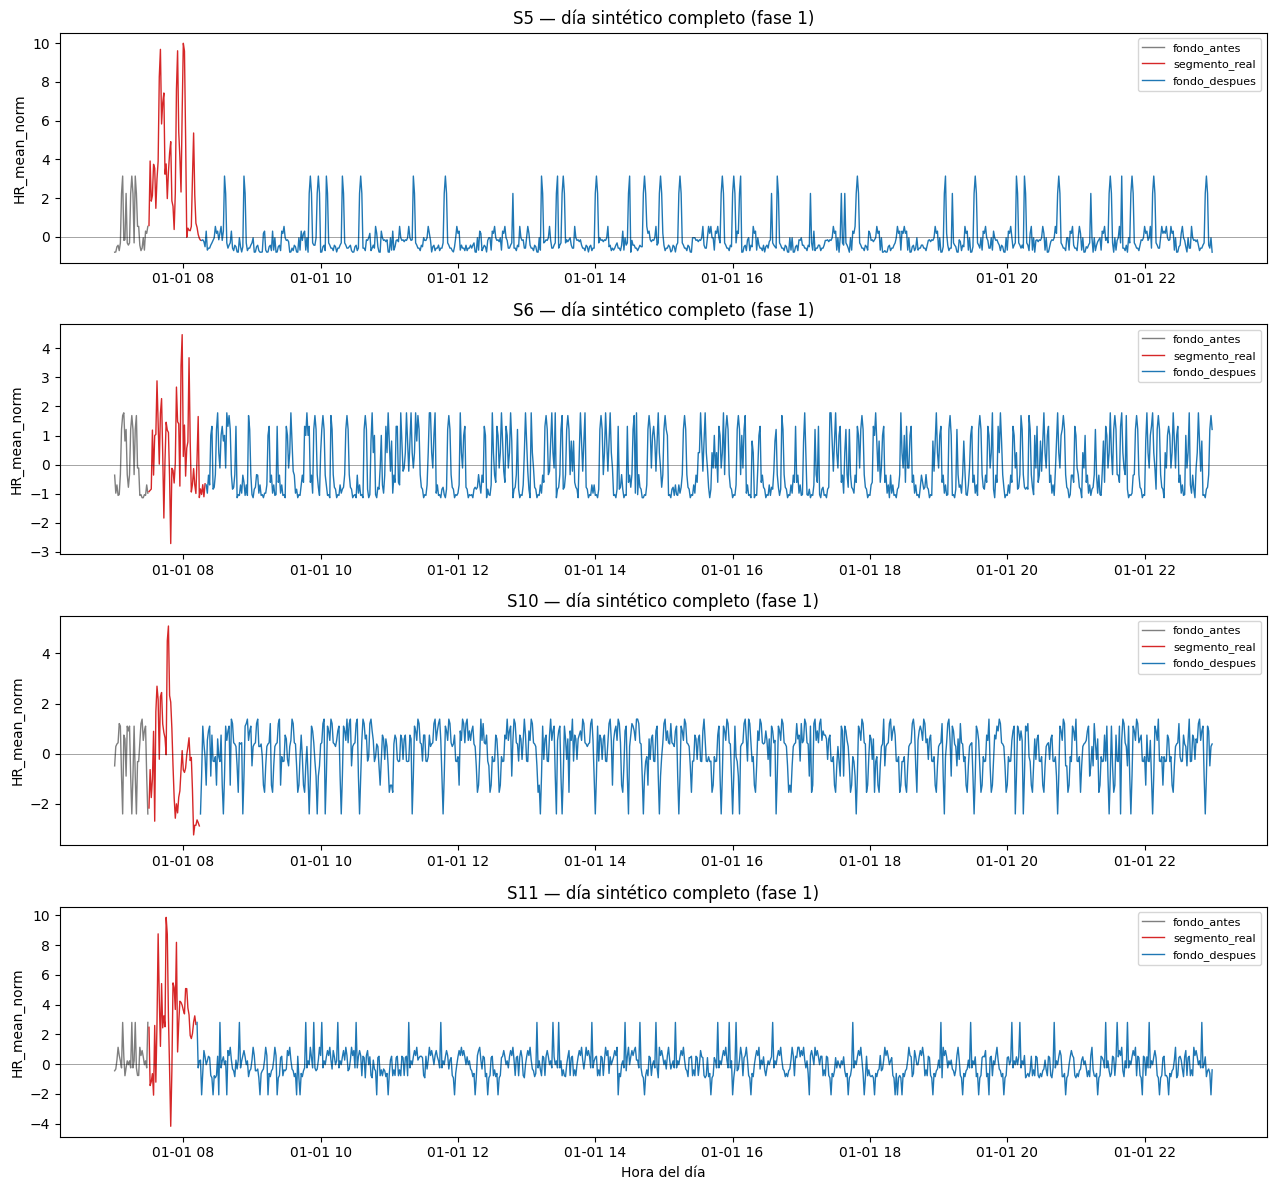

In [17]:
# ======================================================================================================
# VISUALIZACIÓN DE LOS 4 DÍAS SINTÉTICOS
# ======================================================================================================
colores_origen = {'fondo_antes': 'tab:gray', 'segmento_real': 'tab:red', 'fondo_despues': 'tab:blue'}

fig, axes = plt.subplots(len(RESERVED_SUBJECTS), 1, figsize=(13, 3 * len(RESERVED_SUBJECTS)), sharex=False)

for ax, sujeto in zip(axes, RESERVED_SUBJECTS):
    df_dia = dias_sinteticos[sujeto]
    for origen_tipo, color in colores_origen.items():
        mask = df_dia['origen'] == origen_tipo
        ax.plot(df_dia.loc[mask, 'hora_reloj'], df_dia.loc[mask, 'HR_mean_norm'],
                color=color, label=origen_tipo, linewidth=1)

    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_title(f"{sujeto} — día sintético completo (fase 1)")
    ax.set_ylabel("HR_mean_norm")
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Hora del día")
plt.tight_layout()
plt.show()

## 2.3 Reconstrucción de las features

El día sintético ya ensamblado en 2.2 está en unidades normalizadas (`HR_mean_norm`), pero el
clasificador espera columnas de rolling calculadas sobre HR en bruto y normalizadas columna a
columna con las estadísticas de baseline reales — no sobre `HR_mean_norm` directamente, que daría
un resultado sistemáticamente distinto (el suavizado del rolling reduce la varianza respecto a la
señal cruda, así que la desviación típica de una columna de rolling durante el baseline no coincide
con la de `HR_mean`, y normalizar con la equivocada introduciría un sesgo de escala en toda la
columna). Esta sección reconstruye el día completo en unidades brutas, verifica que reproduce
exactamente la versión normalizada (invarianza afín) y recalcula todo el pipeline de features tal
como lo hizo el entrenamiento: rolling → normalización por columna → lags.

### 2.3.1 Estadísticas de baseline por sujeto (HR bruto)

Se calculan sobre las filas reales de Etiqueta==1 (Relajado) de cada sujeto reservado,
en `df_reservados` — las mismas que usó el pipeline de entrenamiento para normalizar,
recalculadas aquí de forma independiente a partir de las columnas en bruto ya
disponibles en el dataset maestro.

In [18]:
# ======================================================================================================
# ESTADÍSTICAS DE BASELINE POR SUJETO — HR_mean Y SUS ROLLING EN BRUTO
# ======================================================================================================
COLUMNAS_ROLLING_BRUTO = [
    'HR_mean', 'HR_mean_roll_mean_3m', 'HR_mean_roll_std_3m',
    'HR_mean_roll_mean_5m', 'HR_mean_roll_std_5m',
    'HR_mean_roll_mean_10m', 'HR_mean_roll_std_10m',
]

stats_baseline = {}
for sujeto in RESERVED_SUBJECTS:
    df_baseline_suj = df_reservados[(df_reservados['ID_sujeto'] == sujeto) & (df_reservados['Etiqueta'] == 1)]
    stats_baseline[sujeto] = {
        col: {'mean': df_baseline_suj[col].mean(), 'std': df_baseline_suj[col].std()}
        for col in COLUMNAS_ROLLING_BRUTO
    }
    print(f"{sujeto}: HR_mean baseline -> media={stats_baseline[sujeto]['HR_mean']['mean']:.2f}, "
          f"std={stats_baseline[sujeto]['HR_mean']['std']:.2f}")

S5: HR_mean baseline -> media=64.57, std=5.75
S6: HR_mean baseline -> media=70.92, std=5.12
S10: HR_mean baseline -> media=94.36, std=6.00
S11: HR_mean baseline -> media=73.82, std=3.52


### 2.3.2. Extracción en bruto de los segmentos reales.
Se repite la extracción  y el recorte de artefactos del apartado anterior,
pero sobre `HR_mean` en vez de `HR_mean_norm`. El recorte se recalcula con el mismo
algoritmo (no se fuerza "cortar 1 minuto a S11") — por la invarianza afín ya explicada,
debe dar exactamente el mismo resultado, y así lo comprobamos en vez de asumirlo.

In [19]:
# ======================================================================================================
# EXTRACCIÓN EN BRUTO (HR_mean) — RELAJADO Y ESTRÉS+RECUPERACIÓN, CON RECORTE RECALCULADO
# ======================================================================================================
def extraer_columna_primitiva(df_bloque, columna):
    """Igual que extraer_hr_primitivo, pero generalizada a cualquier columna —
    se queda con ID_sujeto, minuto_id y la columna indicada."""
    return df_bloque[['ID_sujeto', 'minuto_id', columna]].reset_index(drop=True)


relajado_bruto = {
    sujeto: extraer_columna_primitiva(segmentos[sujeto]['relajado'], 'HR_mean')
    for sujeto in RESERVED_SUBJECTS
}

estres_recuperacion_bruto = {}
for sujeto in RESERVED_SUBJECTS:
    df_seg = extraer_columna_primitiva(segmentos[sujeto]['estres_y_recuperacion'], 'HR_mean')
    n_recortes = 0
    while n_recortes < MAX_RECORTES and len(df_seg) > 15:
        cola = df_seg['HR_mean'].tail(15).values
        saltos_cola = np.abs(np.diff(cola))
        percentil_95_cola = np.percentile(saltos_cola, 95)
        salto_ultimo = abs(cola[-1] - cola[-2])
        if salto_ultimo > percentil_95_cola:
            df_seg = df_seg.iloc[:-1].reset_index(drop=True)
            n_recortes += 1
        else:
            break
    estres_recuperacion_bruto[sujeto] = df_seg
    coincide = len(df_seg) == duraciones[sujeto]['n_segmento']
    print(f"{sujeto}: {n_recortes} minuto(s) recortado(s) | duración = {len(df_seg)} min "
          f"| ¿coincide con la versión normalizada?: {'sí' if coincide else 'NO — revisar'}")

S5: 0 minuto(s) recortado(s) | duración = 46 min | ¿coincide con la versión normalizada?: sí
S6: 0 minuto(s) recortado(s) | duración = 50 min | ¿coincide con la versión normalizada?: sí
S10: 0 minuto(s) recortado(s) | duración = 45 min | ¿coincide con la versión normalizada?: sí
S11: 1 minuto(s) recortado(s) | duración = 42 min | ¿coincide con la versión normalizada?: sí


Aplicando el mismo criterio de percentil 95 (Sección 2.2.3) sobre `HR_mean` en bruto en vez de sobre
`HR_mean_norm`, el resultado es idéntico en los 4 sujetos: mismo número de minutos recortados por
sujeto (1 en S11, 0 en el resto) y misma duración final del segmento. Confirma en la práctica lo que
la invarianza afín garantiza en la teoría — como `HR_mean_norm` es una transformación afín de
`HR_mean` con la misma constante para todo el bloque de un sujeto, qué minuto se considera "salto
anómalo" no depende de si se mide en unidades brutas o normalizadas. No hace falta repetir ninguna
decisión de recorte tomada en 2.2.3; solo replicarla sobre la señal en bruto.

### 2.3.3. Ensamblaje del día sintético en bruto (HR_mean)

Mismas semillas, mismo `MINUTO_INSERCION`, misma lógica de costuras ya optimizada en
la Sección 2.2.4 — solo cambia la columna de entrada (`HR_mean` en vez de
`HR_mean_norm`). Por la invarianza afín, debe generar exactamente las mismas
posiciones de fondo/segmento real que `dias_sinteticos`; se añade como una columna
nueva (`HR_mean_bruto`) al DataFrame ya existente de cada sujeto, en vez de crear un
DataFrame aparte.

In [20]:
# ======================================================================================================
# ENSAMBLAJE EN BRUTO — AÑADIDO COMO COLUMNA NUEVA A dias_sinteticos
# ======================================================================================================
for sujeto in RESERVED_SUBJECTS:
    dur = duraciones[sujeto]
    serie_relajado_bruto = relajado_bruto[sujeto]['HR_mean']
    ciclo_bruto = extender_simetrico_sin_duplicar(serie_relajado_bruto)

    segmento_real_bruto = estres_recuperacion_bruto[sujeto]['HR_mean'].values
    primer_valor_bruto = segmento_real_bruto[0]
    ultimo_valor_bruto = segmento_real_bruto[-1]

    indice_final_optimo = encontrar_mejor_inicio(ciclo_bruto, primer_valor_bruto)
    fondo_antes_bruto = bootstrap_con_final_forzado(
        ciclo_bruto, indice_final_optimo, n_minutos_objetivo=dur['n_fondo_antes'],
        longitud_media_bloque=4, seed=100
    )

    indice_inicio_optimo = encontrar_mejor_inicio(ciclo_bruto, ultimo_valor_bruto)
    fondo_despues_bruto = bootstrap_con_inicio_forzado(
        ciclo_bruto, indice_inicio_optimo, n_minutos_objetivo=dur['n_fondo_despues'],
        longitud_media_bloque=4, seed=200
    )

    hr_dia_completo_bruto = np.concatenate([fondo_antes_bruto, segmento_real_bruto, fondo_despues_bruto])

    assert len(hr_dia_completo_bruto) == len(dias_sinteticos[sujeto]), \
        f"{sujeto}: longitud del día en bruto no coincide con dias_sinteticos"

    dias_sinteticos[sujeto]['HR_mean_bruto'] = hr_dia_completo_bruto

    # Comprobación fila a fila: la relación (bruto - media)/std debe reproducir la columna normalizada
    media_suj = stats_baseline[sujeto]['HR_mean']['mean']
    std_suj = stats_baseline[sujeto]['HR_mean']['std']
    reconstruido = (hr_dia_completo_bruto - media_suj) / std_suj
    max_diferencia = np.abs(reconstruido - dias_sinteticos[sujeto]['HR_mean_norm'].values).max()

    print(f"{sujeto}: día en bruto añadido | diferencia máxima al reconstruir HR_mean_norm "
          f"desde HR_mean_bruto = {max_diferencia:.6f}")
    

S5: día en bruto añadido | diferencia máxima al reconstruir HR_mean_norm desde HR_mean_bruto = 0.000000
S6: día en bruto añadido | diferencia máxima al reconstruir HR_mean_norm desde HR_mean_bruto = 0.000000
S10: día en bruto añadido | diferencia máxima al reconstruir HR_mean_norm desde HR_mean_bruto = 0.000000
S11: día en bruto añadido | diferencia máxima al reconstruir HR_mean_norm desde HR_mean_bruto = 0.000000


Reejecutando las mismas funciones de ensamblaje (costuras, bootstrap, extensión simétrica) con las
mismas semillas sobre `HR_mean` en vez de `HR_mean_norm`, la diferencia máxima al reconstruir
`HR_mean_norm` desde `HR_mean_bruto` (aplicando la media y desviación típica de baseline de cada
sujeto) es 0.000000 en los 4 sujetos — no una aproximación cercana, coincidencia exacta salvo error
de redondeo de punto flotante.

Confirma con datos reales lo que se argumentó por construcción matemática: como la búsqueda del
punto más cercano y las decisiones de aleatoriedad del bootstrap no dependen de la escala de los
valores (solo de las posiciones que ocupan), la misma semilla genera exactamente la misma secuencia
de índices en bruto y en normalizado. No hace falta repetir ni revalidar ninguna de las decisiones
ya tomadas en 2.1-2.2 (costuras óptimas, recorte de artefactos) — el día en bruto hereda todas ellas
automáticamente al compartir semillas.

### 2.3.4. Rolling (3, 5, 10 min) sobre el día en bruto ya ensamblado

Se calcula sobre `HR_mean_bruto`, con la misma configuración que el pipeline de
entrenamiento (`window=N, min_periods=1`, std con `fillna(0)`). A diferencia del
entrenamiento —que calcula esto sobre WESAD completo, sin huecos temporales dentro
de una sesión—, aquí el día sintético es una rejilla de 1 minuto continua sin huecos
por construcción, así que `rolling(window=N)` por conteo de filas coincide exactamente
con una ventana de N minutos reales — no aplica la salvedad de tratamiento de huecos
que discutimos para el caso n-of-1 real.

In [21]:
# ======================================================================================================
# ROLLING (3, 5, 10 MIN) SOBRE EL DÍA EN BRUTO
# ======================================================================================================
VENTANAS_ROLLING = [3, 5, 10]

for sujeto in RESERVED_SUBJECTS:
    df_dia = dias_sinteticos[sujeto]
    for w in VENTANAS_ROLLING:
        df_dia[f'HR_mean_roll_mean_{w}m'] = df_dia['HR_mean_bruto'].rolling(window=w, min_periods=1).mean()
        df_dia[f'HR_mean_roll_std_{w}m'] = df_dia['HR_mean_bruto'].rolling(window=w, min_periods=1).std().fillna(0)

print(dias_sinteticos['S5'][['hora_reloj', 'HR_mean_bruto', 'HR_mean_roll_mean_5m', 'HR_mean_roll_std_5m']].iloc[25:35].to_string(index=False))

         hora_reloj  HR_mean_bruto  HR_mean_roll_mean_5m  HR_mean_roll_std_5m
2026-01-01 07:25:00      64.323167             63.181500             2.901259
2026-01-01 07:26:00      60.665833             61.774633             1.555883
2026-01-01 07:27:00      66.296667             62.612233             2.574511
2026-01-01 07:28:00      65.643000             63.637300             2.552301
2026-01-01 07:29:00      67.700167             64.925767             2.674007
2026-01-01 07:30:00      67.966333             65.654400             2.950789
2026-01-01 07:31:00      87.089000             70.939033             9.079485
2026-01-01 07:32:00      75.186167             72.716933             8.809513
2026-01-01 07:33:00      76.870333             74.962400             7.944018
2026-01-01 07:34:00      86.109500             78.644267             8.002606


### 2.3.5. Normalización de las columnas de rolling con las estadísticas de baseline

Cada columna de rolling se normaliza con la media y desviación típica de esa MISMA
columna durante el bloque real de baseline del sujeto (Sección 2.3.1) — no con las
estadísticas de HR_mean. Es la misma lógica que aplicó el pipeline de entrenamiento
(`aplicar_normalizacion_por_baseline`), replicada aquí sobre el día sintético.

In [22]:
# ======================================================================================================
# NORMALIZACIÓN DE LAS COLUMNAS DE ROLLING (baseline por sujeto y por columna)
# ======================================================================================================
for sujeto in RESERVED_SUBJECTS:
    df_dia = dias_sinteticos[sujeto]
    for w in VENTANAS_ROLLING:
        for stat in ['mean', 'std']:
            col_bruta = f'HR_mean_roll_{stat}_{w}m'
            media = stats_baseline[sujeto][col_bruta]['mean']
            std = stats_baseline[sujeto][col_bruta]['std']
            df_dia[f'{col_bruta}_norm'] = (df_dia[col_bruta] - media) / std

print(dias_sinteticos['S5'][['hora_reloj', 'HR_mean_roll_mean_5m', 'HR_mean_roll_mean_5m_norm',
                              'HR_mean_roll_std_5m', 'HR_mean_roll_std_5m_norm']].iloc[25:35].to_string(index=False))

         hora_reloj  HR_mean_roll_mean_5m  HR_mean_roll_mean_5m_norm  HR_mean_roll_std_5m  HR_mean_roll_std_5m_norm
2026-01-01 07:25:00             63.181500                  -0.486413             2.901259                 -0.267324
2026-01-01 07:26:00             61.774633                  -0.755849             1.555883                 -0.649753
2026-01-01 07:27:00             62.612233                  -0.595436             2.574511                 -0.360204
2026-01-01 07:28:00             63.637300                  -0.399121             2.552301                 -0.366517
2026-01-01 07:29:00             64.925767                  -0.152361             2.674007                 -0.331922
2026-01-01 07:30:00             65.654400                  -0.012817             2.950789                 -0.253245
2026-01-01 07:31:00             70.939033                   0.999268             9.079485                  1.488859
2026-01-01 07:32:00             72.716933                   1.339761    

### 2.3.6. Lags sobre las columnas ya normalizadas

Se calculan sobre `HR_mean_norm` (ya normalizada) — aquí sí, el orden normalizar/lag
no importa (invarianza afín ya demostrada), a diferencia del rolling. `shift(1)` y
`shift(2)`, con `fillna(0)` para los primeros minutos del día sintético, donde el lag
no existe — mismo criterio que el pipeline de entrenamiento.

In [23]:
# ======================================================================================================
# LAGS SOBRE HR_mean_norm (YA NORMALIZADA)
# ======================================================================================================
for sujeto in RESERVED_SUBJECTS:
    df_dia = dias_sinteticos[sujeto]
    df_dia['HR_mean_norm_lag_1m_norm'] = df_dia['HR_mean_norm'].shift(1).fillna(0)
    df_dia['HR_mean_norm_lag_2m_norm'] = df_dia['HR_mean_norm'].shift(2).fillna(0)

print(dias_sinteticos['S5'][['hora_reloj', 'HR_mean_norm', 'HR_mean_norm_lag_1m_norm',
                              'HR_mean_norm_lag_2m_norm']].iloc[25:35].to_string(index=False))

         hora_reloj  HR_mean_norm  HR_mean_norm_lag_1m_norm  HR_mean_norm_lag_2m_norm
2026-01-01 07:25:00     -0.043350                 -0.576728                 -0.705520
2026-01-01 07:26:00     -0.679738                 -0.043350                 -0.576728
2026-01-01 07:27:00      0.300046                 -0.679738                 -0.043350
2026-01-01 07:28:00      0.186305                  0.300046                 -0.679738
2026-01-01 07:29:00      0.544259                  0.186305                  0.300046
2026-01-01 07:30:00      0.590573                  0.544259                  0.186305
2026-01-01 07:31:00      3.917980                  0.590573                  0.544259
2026-01-01 07:32:00      1.846848                  3.917980                  0.590573
2026-01-01 07:33:00      2.139899                  1.846848                  3.917980
2026-01-01 07:34:00      3.747544                  2.139899                  1.846848


## 2.4. Clasificador y diagnóstico

### 2.4.1. Carga de columnas y montaje de la matriz final

Se carga la lista exacta de columnas que el modelo entrenado espera (mismos artefactos
que ya usa `03_Demand.ipynb`), para confirmar que las 7 columnas ya generadas coinciden
exactamente con lo esperado, sin dar por hecho el nombre o el orden.

In [24]:
# ======================================================================================================
# CARGA DE columnas_camino_B Y VERIFICACIÓN DE COBERTURA
# ======================================================================================================
import joblib

with open("WESAD_config_rutas.json") as f:
    config_rutas = json.load(f)

rutas_art = config_rutas["rutas_artefactos_stressload"]

with open(rutas_art["columnas_camino_B"]) as f:
    columnas_camino_B = json.load(f)

modelo_stress = joblib.load(rutas_art["modelo_final"])

print(f"columnas_camino_B (modelo entrenado): {columnas_camino_B}")

# Comprobación: ¿tenemos ya generadas todas esas columnas en dias_sinteticos?
columnas_generadas = set(dias_sinteticos['S5'].columns)
faltantes = [c for c in columnas_camino_B if c not in columnas_generadas]

if faltantes:
    print(f"\n⚠️ FALTAN columnas: {faltantes}")
else:
    print(f"\n✅ Las {len(columnas_camino_B)} columnas de columnas_camino_B están todas generadas.")

columnas_camino_B (modelo entrenado): ['HR_mean_norm', 'HR_mean_roll_mean_5m_norm', 'HR_mean_roll_std_5m_norm', 'HR_mean_roll_mean_10m_norm', 'HR_mean_roll_std_10m_norm', 'HR_mean_norm_lag_1m_norm', 'HR_mean_norm_lag_2m_norm']

✅ Las 7 columnas de columnas_camino_B están todas generadas.


### 2.4.2.  Aplicación del clasificador a los 4 días sintéticos (timing=valle, versión de trabajo).

In [25]:
# ======================================================================================================
# APLICACIÓN DEL CLASIFICADOR A LOS 4 DÍAS SINTÉTICOS
# ======================================================================================================
for sujeto in RESERVED_SUBJECTS:
    df_dia = dias_sinteticos[sujeto]
    X_dia = df_dia[columnas_camino_B]
    df_dia['stress_pred'] = modelo_stress.predict(X_dia)

    n_pred_estres = df_dia['stress_pred'].sum()
    minuto_bout_real = df_dia[df_dia['origen'] == 'segmento_real']['hora_reloj'].iloc[0]
    minuto_fin_bout_real = df_dia[df_dia['origen'] == 'segmento_real']['hora_reloj'].iloc[-1]

    # ¿Cuántos de los minutos predichos como estrés caen DENTRO del segmento real (esperado) vs. fuera (inesperado)?
    pred_dentro_segmento_real = df_dia[(df_dia['origen'] == 'segmento_real') & (df_dia['stress_pred'] == 1)]
    pred_fuera_segmento_real = df_dia[(df_dia['origen'] != 'segmento_real') & (df_dia['stress_pred'] == 1)]

    print(f"{sujeto}: {n_pred_estres} min predichos como estrés en total "
          f"({100*n_pred_estres/len(df_dia):.1f}%) | "
          f"dentro del segmento real: {len(pred_dentro_segmento_real)}/{duraciones[sujeto]['n_segmento']} min | "
          f"fuera del segmento real (posible falso positivo en el fondo): {len(pred_fuera_segmento_real)} min")

S5: 35 min predichos como estrés en total (3.6%) | dentro del segmento real: 35/46 min | fuera del segmento real (posible falso positivo en el fondo): 0 min
S6: 213 min predichos como estrés en total (22.2%) | dentro del segmento real: 27/50 min | fuera del segmento real (posible falso positivo en el fondo): 186 min
S10: 50 min predichos como estrés en total (5.2%) | dentro del segmento real: 15/45 min | fuera del segmento real (posible falso positivo en el fondo): 35 min
S11: 38 min predichos como estrés en total (4.0%) | dentro del segmento real: 34/42 min | fuera del segmento real (posible falso positivo en el fondo): 4 min


Las 7 columnas de `columnas_camino_B` cargadas en 2.4.1 coinciden exactamente con lo que el modelo
entrenado espera, y `modelo_stress.predict()` se ejecuta sin error sobre los 4 días sintéticos
completos — confirma que la reconstrucción de features de la Sección 2.3 (rolling en bruto,
normalización columna a columna, lags) es fiel al pipeline de entrenamiento, no solo en la teoría
sino aplicada de punta a punta sobre datos nuevos que el modelo nunca vio.

Esta celda no evalúa todavía si las predicciones son *buenas* — solo que el mecanismo funciona sin
errores de forma, columnas o tipos de dato. La calidad del resultado (falsos positivos, aciertos
dentro del *bout* real) se diagnostica en la Sección 2.4.3, que sí interpreta los números.

### 2.4.3. Diagnóstico de falsos positivos (numérico, visual, y por nivel de HR)

Antes de dar el pipeline por cerrado, se investiga si los falsos positivos de StressLoad(t) en el
fondo de S6 y S10 son de la misma naturaleza (picos de variabilidad del bootstrap) o de naturalezas
distintas — la respuesta cambia qué se puede corregir y qué es una limitación a documentar.

In [26]:
# ======================================================================================================
# DIAGNÓSTICO: ¿DÓNDE CAEN LOS FALSOS POSITIVOS DEL FONDO EN S6 Y S10?
# ======================================================================================================
for sujeto in ['S6', 'S10']:
    df_dia = dias_sinteticos[sujeto]
    falsos_positivos = df_dia[(df_dia['origen'] != 'segmento_real') & (df_dia['stress_pred'] == 1)]

    print(f"\n--- {sujeto}: {len(falsos_positivos)} falsos positivos en el fondo ---")

    # ¿Se concentran en tramos consecutivos (rachas) o están dispersos minuto a minuto?
    minutos_fp = falsos_positivos.index.to_numpy()
    rachas = np.split(minutos_fp, np.where(np.diff(minutos_fp) > 1)[0] + 1)
    duraciones_rachas = [len(r) for r in rachas]

    print(f"Número de rachas (tramos consecutivos) de falsos positivos: {len(rachas)}")
    print(f"Duración de las rachas: media={np.mean(duraciones_rachas):.1f} min, "
          f"máxima={max(duraciones_rachas)} min, mínima={min(duraciones_rachas)} min")

    # Valor de HR_mean_roll_std_5m en los falsos positivos, comparado con el resto del fondo
    std_en_fp = falsos_positivos['HR_mean_roll_std_5m'].mean()
    std_resto_fondo = df_dia[(df_dia['origen'] != 'segmento_real') & (df_dia['stress_pred'] == 0)]['HR_mean_roll_std_5m'].mean()
    print(f"HR_mean_roll_std_5m medio en falsos positivos: {std_en_fp:.2f} | "
          f"medio en el resto del fondo (sin predicción de estrés): {std_resto_fondo:.2f}")


--- S6: 186 falsos positivos en el fondo ---
Número de rachas (tramos consecutivos) de falsos positivos: 31
Duración de las rachas: media=6.0 min, máxima=16 min, mínima=1 min
HR_mean_roll_std_5m medio en falsos positivos: 4.57 | medio en el resto del fondo (sin predicción de estrés): 3.85

--- S10: 35 falsos positivos en el fondo ---
Número de rachas (tramos consecutivos) de falsos positivos: 25
Duración de las rachas: media=1.4 min, máxima=4 min, mínima=1 min
HR_mean_roll_std_5m medio en falsos positivos: 4.44 | medio en el resto del fondo (sin predicción de estrés): 4.86


**Diagnóstico visual**

Dos paneles por sujeto: arriba, HR_mean_bruto con los minutos predichos como estrés
marcados en rojo sobre el fondo (naranja = fondo, verde = segmento real, para
distinguir de un vistazo si el rojo cae donde debería); abajo, HR_mean_roll_std_5m,
para comprobar visualmente si los falsos positivos coinciden con picos de
variabilidad del propio fondo generado por bootstrap.

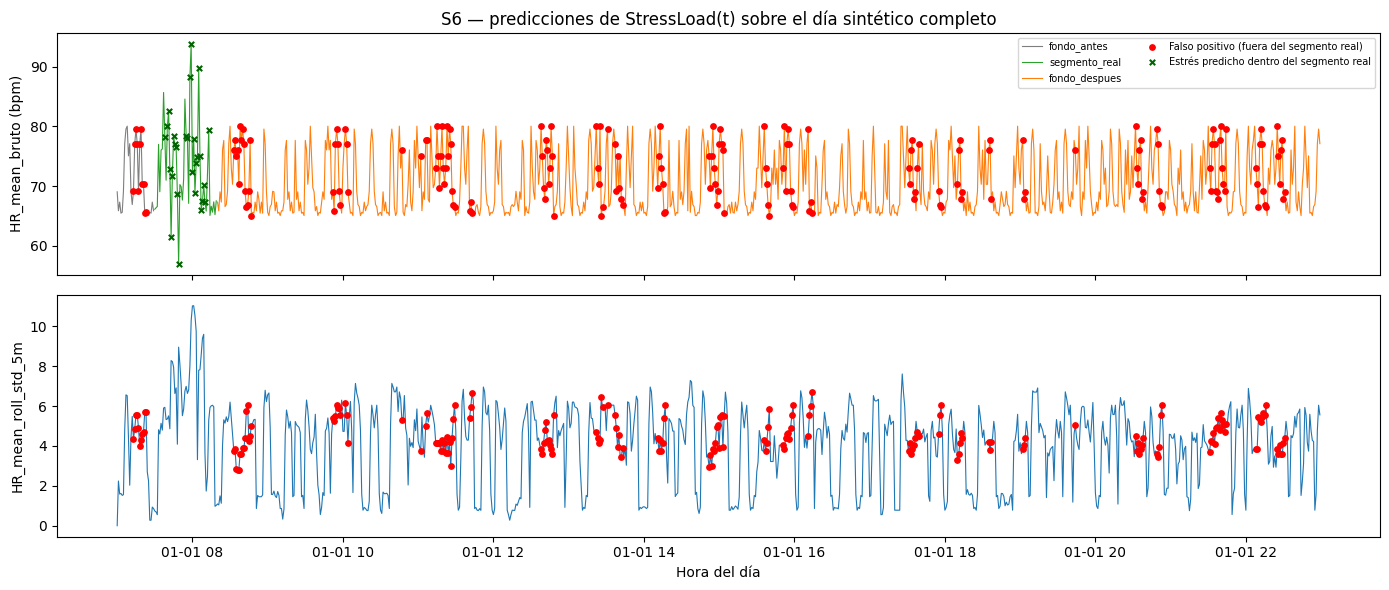

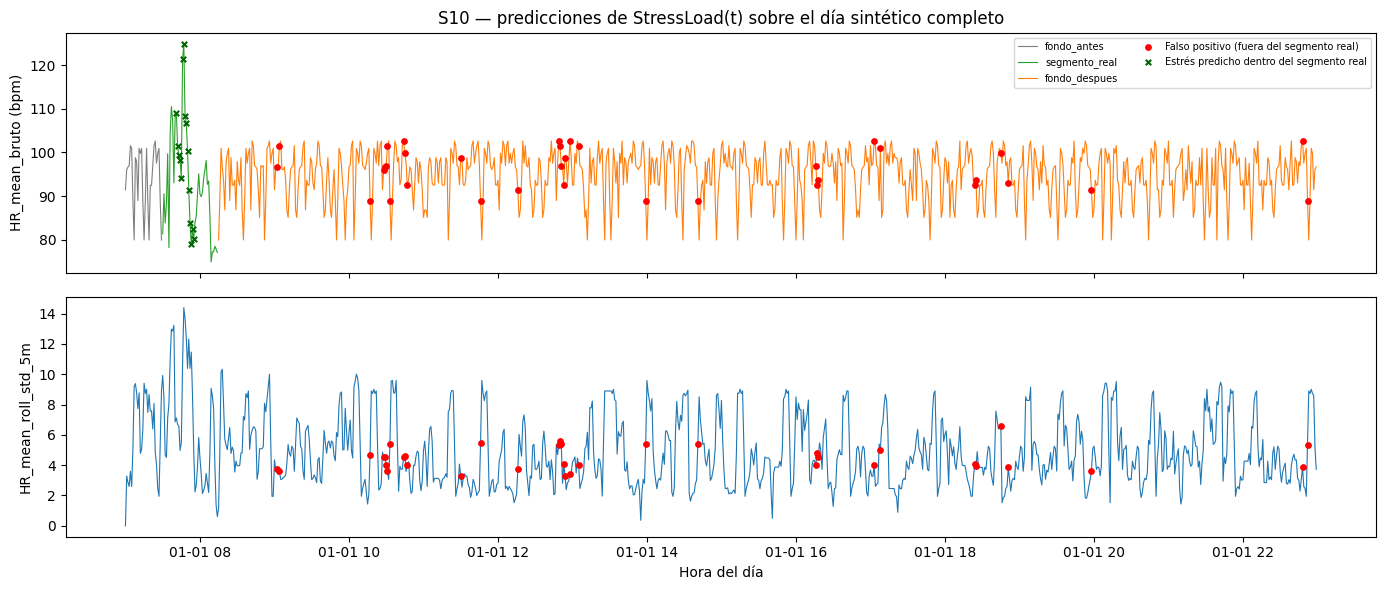

In [27]:
# ======================================================================================================
# VISUALIZACIÓN DE FALSOS POSITIVOS — S6 Y S10
# ======================================================================================================
for sujeto in ['S6', 'S10']:
    df_dia = dias_sinteticos[sujeto]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # --- Panel superior: HR_mean_bruto, coloreado por origen, con FP marcados en rojo ---
    colores_origen = {'fondo_antes': 'tab:gray', 'segmento_real': 'tab:green', 'fondo_despues': 'tab:orange'}
    for origen_tipo, color in colores_origen.items():
        mask = df_dia['origen'] == origen_tipo
        axes[0].plot(df_dia.loc[mask, 'hora_reloj'], df_dia.loc[mask, 'HR_mean_bruto'],
                     color=color, linewidth=0.8, label=origen_tipo)

    # Falsos positivos: predicción de estrés FUERA del segmento real
    falsos_positivos = df_dia[(df_dia['origen'] != 'segmento_real') & (df_dia['stress_pred'] == 1)]
    axes[0].scatter(falsos_positivos['hora_reloj'], falsos_positivos['HR_mean_bruto'],
                     color='red', s=15, zorder=5, label='Falso positivo (fuera del segmento real)')

    # Verdaderos positivos: predicción de estrés DENTRO del segmento real (para contraste)
    verdaderos_positivos = df_dia[(df_dia['origen'] == 'segmento_real') & (df_dia['stress_pred'] == 1)]
    axes[0].scatter(verdaderos_positivos['hora_reloj'], verdaderos_positivos['HR_mean_bruto'],
                     color='darkgreen', s=15, zorder=5, marker='x', label='Estrés predicho dentro del segmento real')

    axes[0].set_ylabel("HR_mean_bruto (bpm)")
    axes[0].set_title(f"{sujeto} — predicciones de StressLoad(t) sobre el día sintético completo")
    axes[0].legend(loc='upper right', fontsize=7, ncol=2)

    # --- Panel inferior: HR_mean_roll_std_5m, con los mismos FP marcados ---
    axes[1].plot(df_dia['hora_reloj'], df_dia['HR_mean_roll_std_5m'], color='tab:blue', linewidth=0.8)
    axes[1].scatter(falsos_positivos['hora_reloj'], falsos_positivos['HR_mean_roll_std_5m'],
                     color='red', s=15, zorder=5)
    axes[1].set_ylabel("HR_mean_roll_std_5m")
    axes[1].set_xlabel("Hora del día")

    plt.tight_layout()
    plt.show()

S6: 186 falsos positivos, organizados en 31 rachas de duración media 6,0 minutos (máx. 16) —
consistente con el patrón cuasi-periódico ya señalado del fondo generado por bootstrap. La variabilidad
media en los falsos positivos (`HR_mean_roll_std_5m` = 4,57) es mayor que en el resto del fondo
(3,85), en la dirección que la hipótesis de "picos de variabilidad artificial" predice.

S10: 35 falsos positivos, en 25 rachas mucho más cortas (media 1,4 min) — patrón menos sostenido
que en S6. Pero el dato que de verdad contradice la hipótesis es el de variabilidad: la media de
`HR_mean_roll_std_5m` en los falsos positivos (4,44) es **menor**, no mayor, que en el resto del
fondo (4,86) — justo la dirección contraria a la esperada si el mecanismo fuera el mismo que en S6.

Esto descarta que ambos sujetos compartan el mismo mecanismo de fallo, y obliga a comprobar una
hipótesis distinta para S10 —efecto de nivel sostenido en vez de variabilidad puntual— en las
siguientes celda (diagnostico de nivel para S10), en vez de asumir que "más falsos positivos" significa siempre "el mismo tipo de
problema".

**Diagnóstico de nivel para S10**

A diferencia de S6 (falsos positivos asociados a picos de variabilidad, ver diagnóstico anterior),
se comprueba si en S10 el clasificador reacciona al *nivel* de `HR_mean_roll_mean` en vez de a su
variabilidad — comparando la media de `roll_mean_5m` y `roll_mean_10m` entre los falsos positivos
y el resto del fondo.

In [28]:
# ======================================================================================================
# DIAGNÓSTICO ADICIONAL S10: ¿ES UN EFECTO DE NIVEL (roll_mean), NO DE VARIABILIDAD?
# ======================================================================================================
df_dia = dias_sinteticos['S10']
falsos_positivos = df_dia[(df_dia['origen'] != 'segmento_real') & (df_dia['stress_pred'] == 1)]
resto_fondo = df_dia[(df_dia['origen'] != 'segmento_real') & (df_dia['stress_pred'] == 0)]

for col in ['HR_mean_roll_mean_5m_norm', 'HR_mean_roll_mean_10m_norm', 'HR_mean_norm']:
    media_fp = falsos_positivos[col].mean()
    media_resto = resto_fondo[col].mean()
    print(f"{col}: FP={media_fp:.3f} | resto del fondo={media_resto:.3f} | diferencia={media_fp - media_resto:.3f}")

HR_mean_roll_mean_5m_norm: FP=0.911 | resto del fondo=0.237 | diferencia=0.674
HR_mean_roll_mean_10m_norm: FP=1.582 | resto del fondo=0.335 | diferencia=1.247
HR_mean_norm: FP=0.297 | resto del fondo=0.092 | diferencia=0.204


La diferencia entre falsos positivos y resto del fondo crece con la longitud de la ventana de
rolling: `HR_mean_norm` (instantáneo) +0,204 → `roll_mean_5m` +0,674 → `roll_mean_10m` +1,247.
Este patrón —cuanto más larga la ventana de promedio, mayor la diferencia— es justo lo que cabría
esperar si el clasificador está reaccionando a un **nivel sostenido** de HR por encima de lo normal
en ese sujeto, no a un pico puntual de variabilidad: un pico aislado se diluiría al promediarlo en
ventanas más largas, mientras que un nivel sostenido se acentúa.

Confirma, con esta comprobación específica, lo que ya sugería el contraste con S6 (diagnóstico
anterior): S6 y S10 tienen falsos positivos por **mecanismos distintos** — variabilidad artificial
del fondo generado por bootstrap en S6, nivel de HR elevado en S10 —, no la misma limitación vista dos veces.
Esta distinción es la que permite, más adelante (Sección 3.6), explicar por qué el filtro de
persistencia de f(StressLoad(t)) protege de forma distinta a cada sujeto: filtra bien el ruido
disperso (el mecanismo de S10 tiene, de hecho, algo de esa naturaleza — ratio de contaminación en
fondo puro del 53,3%, intermedio) pero no el ruido sostenido y correlacionado (el mecanismo de S6,
con 94,7% de contaminación).

**Diagnóstico por nivel de HR**

Se comparan las medias de HR_mean en baseline (Etiqueta==1) de los tres sujetos con
peor F1_macro en LOSO (S2, S9, S15 — fallan por bajo recall, no reconocen el estrés
real) frente a los 4 sujetos reservados para escenarios sintéticos (S5, S6, S10, S11),
para comprobar si existe un patrón entre HR basal elevado y algún modo de fallo del
clasificador, o si S10 es un caso aislado dentro de todo el dataset.

In [29]:
# ======================================================================================================
# HR BASAL POR SUJETO — SUJETOS DIFÍCILES DE LOSO vs. SUJETOS RESERVADOS
# ======================================================================================================
SUJETOS_DIFICILES_LOSO = ['S2', 'S9', 'S15']  # peor F1_macro en LOSO (RandomForest, Camino B)

print("--- Sujetos difíciles de LOSO (fallan por bajo recall) ---")
for sujeto in SUJETOS_DIFICILES_LOSO:
    df_baseline_suj = df[(df['ID_sujeto'] == sujeto) & (df['Etiqueta'] == 1)]
    media = df_baseline_suj['HR_mean'].mean()
    std = df_baseline_suj['HR_mean'].std()
    print(f"{sujeto}: HR_mean baseline -> media={media:.2f}, std={std:.2f}")

print("\n--- Sujetos reservados para escenarios sintéticos (para comparar) ---")
for sujeto in RESERVED_SUBJECTS:
    print(f"{sujeto}: HR_mean baseline -> media={stats_baseline[sujeto]['HR_mean']['mean']:.2f}, "
          f"std={stats_baseline[sujeto]['HR_mean']['std']:.2f}")

print("\n--- Referencia: HR_mean baseline de TODOS los 15 sujetos, para ver dónde caen los anteriores ---")
resumen_todos = (
    df[df['Etiqueta'] == 1]
    .groupby('ID_sujeto')['HR_mean']
    .agg(['mean', 'std'])
    .sort_values('mean')
)
print(resumen_todos.to_string())

--- Sujetos difíciles de LOSO (fallan por bajo recall) ---
S2: HR_mean baseline -> media=76.53, std=11.75
S9: HR_mean baseline -> media=74.82, std=5.23
S15: HR_mean baseline -> media=79.87, std=4.95

--- Sujetos reservados para escenarios sintéticos (para comparar) ---
S5: HR_mean baseline -> media=64.57, std=5.75
S6: HR_mean baseline -> media=70.92, std=5.12
S10: HR_mean baseline -> media=94.36, std=6.00
S11: HR_mean baseline -> media=73.82, std=3.52

--- Referencia: HR_mean baseline de TODOS los 15 sujetos, para ver dónde caen los anteriores ---
                mean        std
ID_sujeto                      
S3         58.452193   4.190448
S4         61.181886   5.045714
S5         64.572300   5.747017
S17        66.749316   4.415797
S16        67.849158   6.014774
S7         69.389965   3.271810
S8         69.541456   2.930292
S6         70.918079   5.119181
S14        72.538211   1.686411
S11        73.824075   3.524886
S9         74.821767   5.225932
S2         76.528219  11.74523

Comparando el HR basal (Etiqueta==1) de los tres sujetos difíciles de LOSO (S2: 76,53 · S9: 74,82 ·
S15: 79,87, todos con recall nulo o muy bajo) frente a los 4 sujetos reservados (S5: 64,57 · S6:
70,92 · S10: **94,36** · S11: 73,82), y frente a la tabla completa de los 15 sujetos ordenada por
HR basal, se confirma que **no hay ningún sujeto en LOSO con un perfil comparable al de S10** — el
siguiente HR basal más alto de todo el dataset es S13 (84,53), casi 10 puntos por debajo, el salto
más grande de toda la tabla.

Y S13 desmiente directamente cualquier relación simple entre HR basal alto y peor rendimiento: es,
con diferencia, **el mejor sujeto de toda la validación LOSO** (F1 macro = 0,967). Los sujetos
realmente difíciles (S2, S9, S15) están en la zona media-alta de la tabla, no en el extremo, y
fallan además por el motivo contrario al de S10 (recall nulo — no detectan estrés real — frente a
baja especificidad — falsos positivos en reposo).

Esto descarta que el problema de S10 sea "un caso más" de una tendencia ya conocida en LOSO, y
refuerza que sea tratado como un hallazgo propio de la validación de escenarios sintéticos: **S10
nunca formó parte de LOSO** (uno de los 4 sujetos reservados desde el diseño inicial, seed=42), así
que esta es la primera vez que el modelo se enfrenta a sus datos en cualquier forma — no existía,
hasta ahora, ninguna evidencia previa que confirmar o contradecir.

## 2.5 Función consolidada: `ensamblar_dia_sintetico()`

Empaqueta todo el pipeline de este capítulo (recorte de artefactos → costuras óptimas → bootstrap
del fondo, en bruto y normalizado → rolling → normalización → lags → clasificador) en una única
función parametrizada por `minuto_insercion` — el punto exacto donde arranca el segmento real dentro
del día sintético de 16h (07:00-23:00). Es la pieza que hace que los Capítulos 3, 4 y 5 no tengan que
repetir esta lógica: cada uno la llama con su propio timing.

Reutiliza directamente los objetos ya calculados en este capítulo (`segmentos`, `relajado_primitivo`,
`relajado_bruto`, `stats_baseline`, `columnas_camino_B`, `modelo_stress`) — no los recalcula.

In [30]:
# ======================================================================================================
# FUNCIÓN CONSOLIDADA — ENSAMBLAR EL DÍA SINTÉTICO PARA CUALQUIER TIMING DE INSERCIÓN
# ======================================================================================================
def ensamblar_dia_sintetico(sujeto, minuto_insercion, hora_inicio_dia_min=7 * 60,
                             duracion_dia_min=16 * 60, seed_fondo_antes=100, seed_fondo_despues=200,
                             max_recortes=3, ventanas_rolling=(3, 5, 10), longitud_media_bloque=4):
    """
    Ensambla el día sintético completo de un sujeto, con el segmento real insertado
    a partir de `minuto_insercion` (minutos desde el inicio del día, 07:00 por defecto).

    Devuelve (df_dia, n_recortes):
      - df_dia: DataFrame con hora_reloj, HR_mean_norm, HR_mean_bruto, origen,
        las 7 columnas de columnas_camino_B, y stress_pred -- misma estructura que
        dias_sinteticos[sujeto] en la Fase 1.
      - n_recortes: minutos recortados de la cola de recuperación por artefacto
        anómalo (0-3, mismo criterio que en la Sección 2.6).

    Lanza ValueError si minuto_insercion + duración del segmento real supera
    duracion_dia_min (el segmento real no cabe en el día con ese timing).
    """
    # --- 1. Recorte de artefactos de cola anómala (igual criterio que 2.6) ---
    df_seg_norm = extraer_hr_primitivo(segmentos[sujeto]['estres_y_recuperacion'])
    df_seg_bruto = extraer_columna_primitiva(segmentos[sujeto]['estres_y_recuperacion'], 'HR_mean')

    n_recortes = 0
    while n_recortes < max_recortes and len(df_seg_norm) > 15:
        cola = df_seg_norm['HR_mean_norm'].tail(15).values
        saltos_cola = np.abs(np.diff(cola))
        percentil_95_cola = np.percentile(saltos_cola, 95)
        salto_ultimo = abs(cola[-1] - cola[-2])
        if salto_ultimo > percentil_95_cola:
            df_seg_norm = df_seg_norm.iloc[:-1].reset_index(drop=True)
            df_seg_bruto = df_seg_bruto.iloc[:-1].reset_index(drop=True)
            n_recortes += 1
        else:
            break

    n_segmento = len(df_seg_norm)
    n_fondo_antes = minuto_insercion
    n_fondo_despues = duracion_dia_min - minuto_insercion - n_segmento
    if n_fondo_despues < 0:
        raise ValueError(
            f"{sujeto}: minuto_insercion={minuto_insercion} + duración del segmento real "
            f"({n_segmento} min) supera la duración del día ({duracion_dia_min} min)."
        )

    # --- 2. Costuras óptimas y ensamblaje, señal normalizada (igual mecanismo que 2.5/2.7) ---
    ciclo_norm = extender_simetrico_sin_duplicar(relajado_primitivo[sujeto]['HR_mean_norm'])
    segmento_real_norm = df_seg_norm['HR_mean_norm'].values

    idx_final = encontrar_mejor_inicio(ciclo_norm, segmento_real_norm[0])
    fondo_antes_norm = bootstrap_con_final_forzado(
        ciclo_norm, idx_final, n_fondo_antes, longitud_media_bloque=longitud_media_bloque, seed=seed_fondo_antes
    )
    idx_inicio = encontrar_mejor_inicio(ciclo_norm, segmento_real_norm[-1])
    fondo_despues_norm = bootstrap_con_inicio_forzado(
        ciclo_norm, idx_inicio, n_fondo_despues, longitud_media_bloque=longitud_media_bloque, seed=seed_fondo_despues
    )

    hr_dia_norm = np.concatenate([fondo_antes_norm, segmento_real_norm, fondo_despues_norm])
    origen = (['fondo_antes'] * len(fondo_antes_norm) + ['segmento_real'] * n_segmento +
              ['fondo_despues'] * len(fondo_despues_norm))
    minutos = np.arange(len(hr_dia_norm))
    hora_reloj = pd.to_datetime(hora_inicio_dia_min + minutos, unit='m', origin='2026-01-01')

    # --- 3. Repetir en bruto, mismas semillas -> mismas posiciones (invarianza afín ya verificada en 2.11) ---
    ciclo_bruto = extender_simetrico_sin_duplicar(relajado_bruto[sujeto]['HR_mean'])
    segmento_real_bruto = df_seg_bruto['HR_mean'].values

    idx_final_b = encontrar_mejor_inicio(ciclo_bruto, segmento_real_bruto[0])
    fondo_antes_bruto = bootstrap_con_final_forzado(
        ciclo_bruto, idx_final_b, n_fondo_antes, longitud_media_bloque=longitud_media_bloque, seed=seed_fondo_antes
    )
    idx_inicio_b = encontrar_mejor_inicio(ciclo_bruto, segmento_real_bruto[-1])
    fondo_despues_bruto = bootstrap_con_inicio_forzado(
        ciclo_bruto, idx_inicio_b, n_fondo_despues, longitud_media_bloque=longitud_media_bloque, seed=seed_fondo_despues
    )
    hr_dia_bruto = np.concatenate([fondo_antes_bruto, segmento_real_bruto, fondo_despues_bruto])

    df_dia = pd.DataFrame({
        'ID_sujeto': sujeto, 'hora_reloj': hora_reloj,
        'HR_mean_norm': hr_dia_norm, 'HR_mean_bruto': hr_dia_bruto, 'origen': origen,
    })

    # --- 4. Rolling + normalización columna a columna + lags (igual que 2.12-2.14) ---
    for w in ventanas_rolling:
        df_dia[f'HR_mean_roll_mean_{w}m'] = df_dia['HR_mean_bruto'].rolling(window=w, min_periods=1).mean()
        df_dia[f'HR_mean_roll_std_{w}m'] = df_dia['HR_mean_bruto'].rolling(window=w, min_periods=1).std().fillna(0)
    for w in ventanas_rolling:
        for stat in ['mean', 'std']:
            col_bruta = f'HR_mean_roll_{stat}_{w}m'
            media = stats_baseline[sujeto][col_bruta]['mean']
            std = stats_baseline[sujeto][col_bruta]['std']
            df_dia[f'{col_bruta}_norm'] = (df_dia[col_bruta] - media) / std
    df_dia['HR_mean_norm_lag_1m_norm'] = df_dia['HR_mean_norm'].shift(1).fillna(0)
    df_dia['HR_mean_norm_lag_2m_norm'] = df_dia['HR_mean_norm'].shift(2).fillna(0)

    # --- 5. Clasificador ---
    df_dia['stress_pred'] = modelo_stress.predict(df_dia[columnas_camino_B])

    return df_dia, n_recortes


# --- Comprobación: reproduce exactamente dias_sinteticos (timing=valle, minuto_insercion=30) ---
for sujeto in RESERVED_SUBJECTS:
    df_prueba, n_rec = ensamblar_dia_sintetico(sujeto, minuto_insercion=MINUTO_INSERCION)
    columnas_comunes = [c for c in dias_sinteticos[sujeto].columns if c in df_prueba.columns]
    diferencia_max = (df_prueba[columnas_comunes].select_dtypes('number') -
                       dias_sinteticos[sujeto][columnas_comunes].select_dtypes('number')).abs().max().max()
    print(f"{sujeto}: n_recortes={n_rec} | diferencia máxima frente a dias_sinteticos (timing=valle) = {diferencia_max:.6f}")


S5: n_recortes=0 | diferencia máxima frente a dias_sinteticos (timing=valle) = 0.000000
S6: n_recortes=0 | diferencia máxima frente a dias_sinteticos (timing=valle) = 0.000000
S10: n_recortes=0 | diferencia máxima frente a dias_sinteticos (timing=valle) = 0.000000
S11: n_recortes=1 | diferencia máxima frente a dias_sinteticos (timing=valle) = 0.000000


**Conclusión del Capítulo 2.** La función `ensamblar_dia_sintetico()` reproduce exactamente
(diferencia esperada 0.000000) el día sintético de la Fase 1 cuando se llama con
`minuto_insercion=MINUTO_INSERCION` (30, timing=valle) — confirma que la consolidación no ha
introducido ninguna discrepancia frente al pipeline ya verificado paso a paso. A partir de aquí,
generar el día sintético de cualquier timing nuevo (Fase 2, Fase 3) es una única llamada a esta
función, sin repetir la ingeniería de este capítulo.

# 3. Fase 1: timing en el valle de cobertura

Primera de las tres fases de la matriz de escenarios: el *bout* de estrés se inserta coincidiendo
con el valle real de Coverage(t) bajo la pauta estándar — el momento de mayor riesgo clínico
esperado, y por eso el priorizado en primer lugar. Cubre: localización del timing, ensamblaje con
`ensamblar_dia_sintetico()` (Capítulo 2), Demand(t)/Coverage(t)/Risk(t) de las 6 combinaciones de la
matriz (2 niveles de estrés × 3 patrones de dosis), y las tres métricas de aceptación.

## 3.1. Localización del timing de la Fase 1 (valle de cobertura)

### 3.1.1 Localización del valle real de Coverage(t) bajo la pauta estándar.

In [31]:
# ======================================================================================================
# LOCALIZACIÓN DEL VALLE REAL DE COVERAGE(T) — PAUTA ESTÁNDAR
# ======================================================================================================
from formulario_utils import PKParams, build_standard_schedule, compute_coverage

pk = PKParams()  # ka≈1.3874 h⁻¹, ke≈0.4077 h⁻¹ (Derendorf et al., 1991)

# Generamos 3 días de pauta estándar para descartar el transitorio del primer día
inicio_referencia = pd.Timestamp("2026-01-01")
schedule_referencia = build_standard_schedule(inicio_referencia, n_days=3)

# Rejilla fina, a resolución de 1 minuto (misma granularidad que el resto del pipeline)
rejilla_referencia = pd.date_range(inicio_referencia, inicio_referencia + pd.Timedelta(days=3), freq="1min")

coverage_referencia = compute_coverage(schedule_referencia, rejilla_referencia, pk)

# Nos quedamos solo con el 2º día completo (00:00 a 24:00 del día 2) — ya en estado estacionario,
# libre del arranque artificial del día 1
dia2_inicio = inicio_referencia + pd.Timedelta(days=1)
dia2_fin = inicio_referencia + pd.Timedelta(days=2)
coverage_dia2 = coverage_referencia[(coverage_referencia.index >= dia2_inicio) & (coverage_referencia.index < dia2_fin)]

# Localizamos el minuto exacto del valor mínimo
minuto_valle = coverage_dia2.idxmin()
valor_valle = coverage_dia2.min()

# Referencia: última toma antes del valle (la de las 17:00 del día 1, o si el valle
# cae más tarde de lo esperado, la de las 17:00 del propio día 2)
ultima_toma_antes_del_valle = schedule_referencia[schedule_referencia['datetime'] <= minuto_valle]['datetime'].max()
horas_desde_ultima_toma = (minuto_valle - ultima_toma_antes_del_valle) / pd.Timedelta(hours=1)
proxima_toma_despues_del_valle = schedule_referencia[schedule_referencia['datetime'] > minuto_valle]['datetime'].min()
horas_hasta_proxima_toma = (proxima_toma_despues_del_valle - minuto_valle) / pd.Timedelta(hours=1)

print(f"Valle de Coverage(t): {minuto_valle} (valor: {valor_valle:.4f} mg/h)")
print(f"Última toma antes del valle: {ultima_toma_antes_del_valle} ({horas_desde_ultima_toma:.2f}h antes)")
print(f"Próxima toma después del valle: {proxima_toma_despues_del_valle} ({horas_hasta_proxima_toma:.2f}h después)")

Valle de Coverage(t): 2026-01-02 07:30:00 (valor: 0.0097 mg/h)
Última toma antes del valle: 2026-01-02 07:30:00 (0.00h antes)
Próxima toma después del valle: 2026-01-02 13:00:00 (5.50h después)


El mínimo de Coverage(t) siempre ocurre justo antes de la siguiente toma, por construcción del
propio modelo de Bateman — eso no es un hallazgo, es una consecuencia directa de la forma del
modelo (si la toma se moviera a las 08:00, el valle se movería con ella, al mismo instante). Lo que
sí aporta esta sección es **cuál de los tres huecos del día produce el valle más bajo**, algo que no
se puede deducir solo mirando los horarios: bajo la pauta estándar (07:30/13:00/17:00, dosis
10-5-5 mg), el hueco nocturno (17:00→07:30, 14,5h — el más largo, y precedido de la dosis más
pequeña de la tarde) da un valle de 0,0097 mg/h a las 07:30 — sustancialmente más bajo que los
valles de los otros dos huecos (verificado y comparado en la Sección 3.1.2).

Este resultado es el que fija el timing de la Fase 1: no porque el valle "coincida" con una toma
concreta (eso ocurre siempre, en cualquier hueco), sino porque este hueco en particular produce el
valle más profundo de los tres posibles.

### 3.1.2. Comparación de los tres valles locales

In [32]:
# ======================================================================================================
# COMPARACIÓN DE LOS TRES VALLES LOCALES (uno por cada hueco entre tomas)
# ======================================================================================================
tomas_dia2 = schedule_referencia[
    (schedule_referencia['datetime'] >= dia2_inicio) & (schedule_referencia['datetime'] < dia2_fin)
].sort_values('datetime').reset_index(drop=True)

# Añadimos la primera toma del día siguiente, para poder cerrar el último hueco (17:00 -> 07:30)
primera_toma_dia3 = schedule_referencia[schedule_referencia['datetime'] >= dia2_fin]['datetime'].min()
limites_huecos = list(tomas_dia2['datetime']) + [primera_toma_dia3]

resultados_valles = []
for i in range(len(limites_huecos) - 1):
    inicio_hueco = limites_huecos[i]
    fin_hueco = limites_huecos[i + 1]
    tramo = coverage_referencia[(coverage_referencia.index > inicio_hueco) & (coverage_referencia.index < fin_hueco)]

    minuto_valle_local = tramo.idxmin()
    valor_valle_local = tramo.min()
    duracion_hueco_h = (fin_hueco - inicio_hueco) / pd.Timedelta(hours=1)

    resultados_valles.append({
        'hueco_entre': f"{inicio_hueco.strftime('%H:%M')} -> {fin_hueco.strftime('%H:%M')}",
        'duracion_h': round(duracion_hueco_h, 1),
        'minuto_valle': minuto_valle_local,
        'valor_valle': round(valor_valle_local, 4),
        'coincide_con_despertar': fin_hueco.strftime('%H:%M') == '07:30',
    })

df_valles = pd.DataFrame(resultados_valles).sort_values('valor_valle')
print(df_valles.to_string(index=False))

   hueco_entre  duracion_h        minuto_valle  valor_valle  coincide_con_despertar
17:00 -> 07:30        14.5 2026-01-03 07:29:00       0.0097                    True
07:30 -> 13:00         5.5 2026-01-02 07:31:00       0.1025                   False
13:00 -> 17:00         4.0 2026-01-02 13:01:00       0.6537                   False


### 3.1.3 Risk_basal(t) — localización del pico real de mismatch, y visualización

El valle de Coverage(t) (3.1.1) no es automáticamente el momento de mayor riesgo: Risk(t) depende
también de Demand_circadian(t), que varía a lo largo del día de forma independiente. Antes de
asumir que "valle de Coverage" y "pico de riesgo" son lo mismo, se calcula Risk_basal(t) =
Demand_circadian(t) − Coverage(t) (sin estrés, f=0) sobre el día completo, y se localiza dónde cae
su máximo — comprobando si de verdad coincide con el valle ya encontrado, o si el mismatch real
ocurre en otro punto del día.

In [33]:
# ======================================================================================================
# RISK_BASAL(T) = DEMAND_CIRCADIAN(T) - COVERAGE(T), SIN ESTRÉS — SOBRE EL DÍA 2 EN ESTADO ESTACIONARIO
# ======================================================================================================
from formulario_utils import demand_circadian

# Demand_circadian(t) necesita la hora del día en horas (0-24), no un timestamp — la derivamos
# directamente del índice ya calculado para coverage_dia2
horas_del_dia = (coverage_dia2.index - coverage_dia2.index.normalize()) / pd.Timedelta(hours=1)

demand_dia2 = pd.Series(demand_circadian(horas_del_dia.values), index=coverage_dia2.index, name="demand_circadian")
risk_basal_dia2 = demand_dia2 - coverage_dia2
risk_basal_dia2.name = "risk_basal"

# Excluimos la ventana de despertar (07:00-08:00) antes de buscar picos, por el motivo ya discutido
ventana_despertar = (risk_basal_dia2.index.hour >= 7) & (risk_basal_dia2.index.hour < 8)
risk_basal_sin_despertar = risk_basal_dia2[~ventana_despertar]

minuto_pico_riesgo = risk_basal_sin_despertar.idxmax()
valor_pico_riesgo = risk_basal_sin_despertar.max()

print(f"Pico de Risk_basal(t) (excluyendo despertar): {minuto_pico_riesgo} (valor: {valor_pico_riesgo:.4f} mg/h)")
print(f"Para comparación, valor de Risk_basal(t) EN el valle de Coverage(t) (07:30): "
      f"{risk_basal_dia2.loc[risk_basal_dia2.index.hour == 7].iloc[0]:.4f} mg/h")

Pico de Risk_basal(t) (excluyendo despertar): 2026-01-02 06:59:00 (valor: 0.6512 mg/h)
Para comparación, valor de Risk_basal(t) EN el valle de Coverage(t) (07:30): 0.6523 mg/h


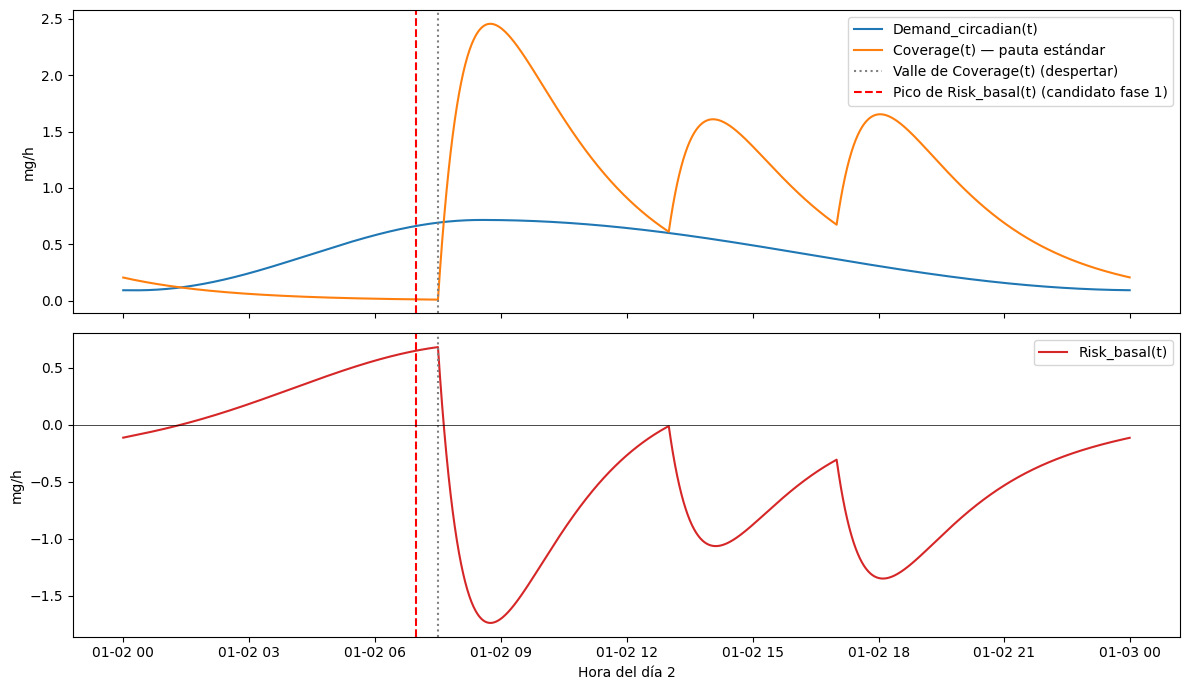

In [34]:
# ======================================================================================================
# VISUALIZACIÓN: DEMAND, COVERAGE Y RISK_BASAL SOBRE EL DÍA 2
# ======================================================================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(demand_dia2.index, demand_dia2.values, label="Demand_circadian(t)", color="tab:blue")
axes[0].plot(coverage_dia2.index, coverage_dia2.values, label="Coverage(t) — pauta estándar", color="tab:orange")
axes[0].axvline(minuto_valle, color="gray", linestyle=":", label="Valle de Coverage(t) (despertar)")
axes[0].axvline(minuto_pico_riesgo, color="red", linestyle="--", label="Pico de Risk_basal(t) (candidato fase 1)")
axes[0].legend()
axes[0].set_ylabel("mg/h")

axes[1].plot(risk_basal_dia2.index, risk_basal_dia2.values, color="tab:red", label="Risk_basal(t)")
axes[1].axvline(minuto_valle, color="gray", linestyle=":")
axes[1].axvline(minuto_pico_riesgo, color="red", linestyle="--")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].legend()
axes[1].set_ylabel("mg/h")
axes[1].set_xlabel("Hora del día 2")

plt.tight_layout()
plt.show()

**Conclusión 3.1.3 — el pico de riesgo coincide con el valle de cobertura, y hereda el valle previo a la primera toma**
El único momento de subcobertura real bajo la pauta estándar (07:30/13:00/17:00) es el
hueco nocturno (17:00→07:30, 14,5h) — los otros dos huecos (07:30→13:00 y 13:00→17:00)
no llegan a cruzar a subcobertura. 

El pico de Risk_basal(t) (excluyendo la ventana de despertar del cálculo) coincide, con un minuto
de diferencia, con el valle de Coverage(t) ya localizado en 3.1.1 — confirma que, en este caso
concreto, usar el valle de Coverage(t) como proxy del riesgo era razonable, aunque en general no
tenga por qué serlo (Demand_circadian(t) también varía a lo largo del día).

**Limitación aceptada, no evitable: el valle previo a la primera toma.** El 07:00 de inicio del día sintético es una decisión de ingeniería (el origen del array de 16h, sin significado fisiológico propio); el despertar real de la persona simulada es implícito y ocurre pocos minutos antes de la primera toma (07:30). En ese tramo Coverage(t) es mínima (≈0,010 mg/h) y Demand_circadian(t) ya está subiendo hacia su pico, así que cualquier elevación de Risk(t) no puede atribuirse de forma limpia solo al estrés insertado. No se puede evitar sin perder, a la vez, la representación del verdadero valle (3.1.1): mover el *bout* a otro momento dejaría de poner a prueba el escenario de mayor riesgo real, que es el objetivo de la Fase 1. Se documenta como limitación declarada y aceptada. Las Fases 2 y 3, ancladas al intervalo 13:00→17:00, quedan libres de este solapamiento concreto, aunque no del pico global de Risk(t) (4.2.1, 5.2).

No se puede evitar este confusor sin perder, a la vez, la representación del verdadero valle
(Sección 3.1.1: el valle está estructuralmente ligado a la duración del hueco nocturno, no es una
elección arbitraria de horario) — mover el *bout* a otro momento evitaría el confusor, pero dejaría
de poner a prueba el escenario de mayor riesgo real, que es el objetivo de la Fase 1. Se documenta
como limitación declarada y aceptada, no como algo a corregir. Las Fases 2 y 3, ancladas al
intervalo 13:00→17:00, quedan libres de este confusor concreto.


**Timing fijado para la fase 1:** 07:30 (fin del hueco nocturno).

### 3.1.4. Definición del timing de la Fase 1 + Ensamblaje dia sintético

`MINUTO_INSERCION_FASE1 = 30` (07:00 + 30 min = 07:30) — ya fijado y verificado en el Capítulo 2.

In [35]:
# ======================================================================================================
# 3.1.4. ENSAMBLAJE DE LOS DÍAS SINTÉTICOS DE LA FASE 1, VÍA LA FUNCIÓN CONSOLIDADA
# ======================================================================================================
MINUTO_INSERCION_FASE1 = 30  # 07:30, el valle real de Coverage(t) (Sección 3.1.1)
print(f"Fase 1 — timing = valle de cobertura, minuto_insercion = {MINUTO_INSERCION_FASE1} (07:30)")

dias_sinteticos_fase1 = {}
for sujeto in RESERVED_SUBJECTS:
    df_dia, n_recortes = ensamblar_dia_sintetico(sujeto, minuto_insercion=MINUTO_INSERCION_FASE1)
    dias_sinteticos_fase1[sujeto] = df_dia
    minuto_bout_real = df_dia[df_dia['origen'] == 'segmento_real']['hora_reloj'].iloc[0]
    print(f"{sujeto}: día ensamblado (Fase 1) | {n_recortes} recorte(s) de cola | "
          f"bout real inicia a las {minuto_bout_real.strftime('%H:%M')}")

# Comprobación: coincide exactamente con el ensamblaje manual del Capítulo 2 (ya verificado en 2.5)
for sujeto in RESERVED_SUBJECTS:
    columnas_comunes = [c for c in dias_sinteticos[sujeto].columns if c in dias_sinteticos_fase1[sujeto].columns]
    diferencia_max = (dias_sinteticos_fase1[sujeto][columnas_comunes].select_dtypes('number') -
                       dias_sinteticos[sujeto][columnas_comunes].select_dtypes('number')).abs().max().max()
    print(f"{sujeto}: diferencia máxima frente al ensamblaje del Capítulo 2 = {diferencia_max:.6f}")

Fase 1 — timing = valle de cobertura, minuto_insercion = 30 (07:30)
S5: día ensamblado (Fase 1) | 0 recorte(s) de cola | bout real inicia a las 07:30
S6: día ensamblado (Fase 1) | 0 recorte(s) de cola | bout real inicia a las 07:30
S10: día ensamblado (Fase 1) | 0 recorte(s) de cola | bout real inicia a las 07:30
S11: día ensamblado (Fase 1) | 1 recorte(s) de cola | bout real inicia a las 07:30
S5: diferencia máxima frente al ensamblaje del Capítulo 2 = 0.000000
S6: diferencia máxima frente al ensamblaje del Capítulo 2 = 0.000000
S10: diferencia máxima frente al ensamblaje del Capítulo 2 = 0.000000
S11: diferencia máxima frente al ensamblaje del Capítulo 2 = 0.000000


### 3.1.5. Visualización del día sintético ensamblado

Muestra `HR_mean_bruto` a lo largo del día para los 4 sujetos, con el segmento real (*bout*)
resaltado — comprobación visual de que el ensamblaje (fondo generado por bootstrap + *bout* insertado) tiene
el aspecto esperado antes de calcular Demand(t)/Coverage(t)/Risk(t) sobre él.

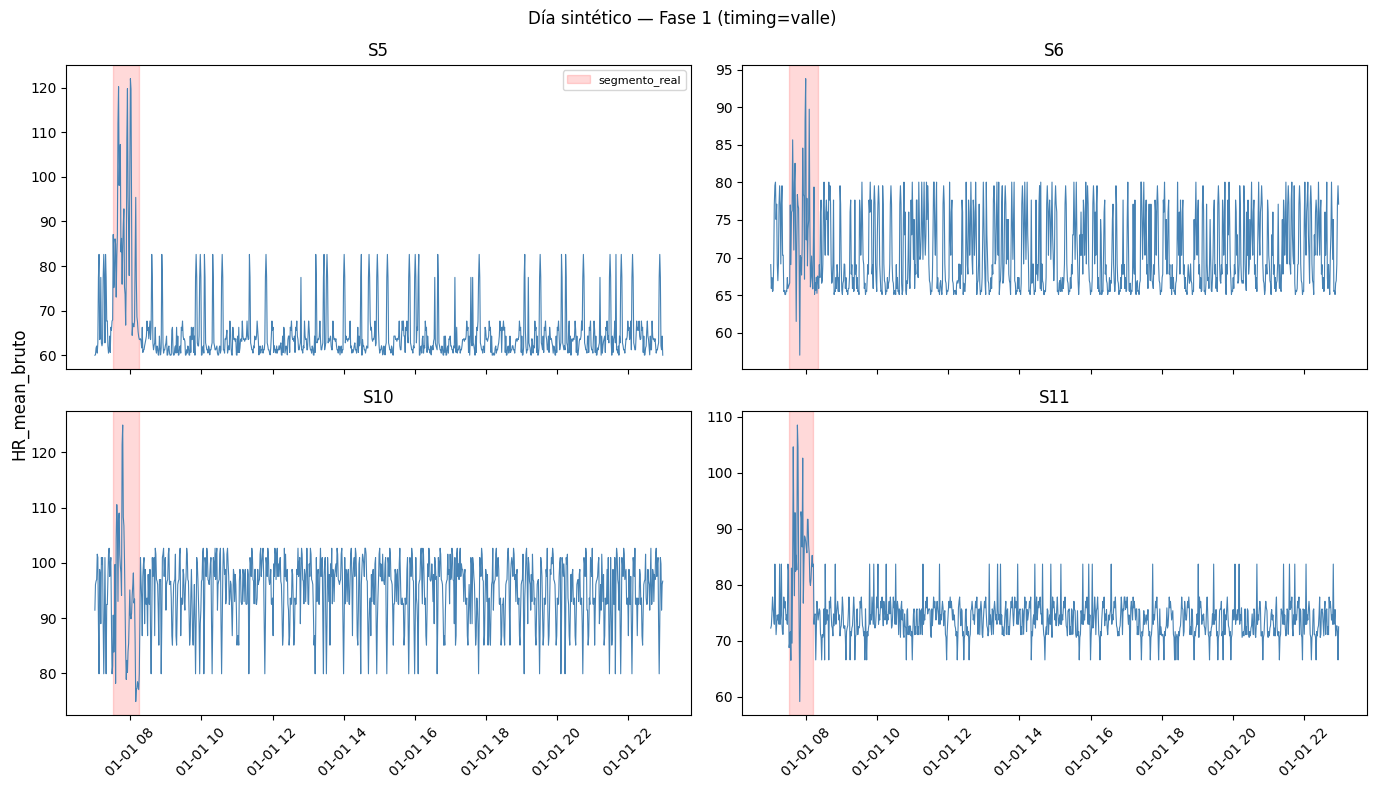

In [36]:
# ======================================================================================================
# VISUALIZACIÓN DEL DÍA SINTÉTICO ENSAMBLADO
# ======================================================================================================
def graficar_dia_sintetico(dias_dict, sujetos, titulo=None, columna='HR_mean_bruto'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, sujeto in zip(axes.flat, sujetos):
        df_dia = dias_dict[sujeto]
        ax.plot(df_dia['hora_reloj'], df_dia[columna], color='steelblue', linewidth=0.8)
        mask_real = df_dia['origen'] == 'segmento_real'
        ax.axvspan(df_dia.loc[mask_real, 'hora_reloj'].iloc[0], df_dia.loc[mask_real, 'hora_reloj'].iloc[-1],
                   color='red', alpha=0.15, label='segmento_real')
        ax.set_title(sujeto)
        ax.tick_params(axis='x', rotation=45)
    axes[0, 0].legend(loc='upper right', fontsize=8)
    if titulo:
        fig.suptitle(titulo)
    fig.supylabel(columna)
    plt.tight_layout()
    plt.show()


graficar_dia_sintetico(dias_sinteticos_fase1, RESERVED_SUBJECTS, titulo='Día sintético — Fase 1 (timing=valle)')

El *bout* real (franja roja) se distingue claramente del fondo en los 4 sujetos — el pico más alto
del día en cada caso, seguido de la caída de recuperación característica.

El fondo generado por bootstrap muestra el mismo contraste visual que ya se había caracterizado numéricamente
(Sección 3.5.2): en S5 y S11, el fondo oscila con picos puntuales dispersos que no superan
claramente la línea base, sin un patrón sostenido reconocible. En S6, el fondo mantiene una
oscilación densa y regular durante todo el día, visualmente más "ocupada" que en S5/S11 — coherente
con el patrón cuasi-periódico ya descrito. En S10, el fondo se mueve en un rango más amplio y
elevado de forma más sostenida, sin el mismo aspecto de oscilación regular que S6 — coherente con
que su mecanismo de falsos positivos sea de nivel, no de variabilidad puntual (Sección 2.4.3).

## 3.2 Demand(t), Coverage(t) y Risk(t) — primera combinación

Con el timing de la Fase 1 ya fijado (07:30, Sección 3.1) y los días sintéticos ya ensamblados
(3.1.4), se calcula el resultado completo de la primera de las 6 combinaciones de la matriz:
**estrés=alto, dosis=a tiempo, timing=valle** — el *bout* de estrés real insertado exactamente en
el valle de cobertura, con la pauta de dosificación sin ninguna alteración. Las 5 combinaciones
restantes (estrés=ninguno, y las variantes de dosis retrasada/omitida) se construyen después, en
la Sección 3.3, reutilizando Demand(t) y Coverage(t) ya calculados aquí.

### 3.2.1. Demand(t) sobre los días sintéticos.

In [37]:
# ======================================================================================================
# DEMAND(t) SOBRE LOS DÍAS SINTÉTICOS
# ======================================================================================================
from formulario_utils import demand_circadian, D_REF_MID

VENTANA_F_STRESSLOAD_MIN = 25  # ventana de persistencia de f(StressLoad(t)), ver memoria 5.3.5

SUJETOS_VALIDOS = ['S5', 'S11']  # S5 y S11 son los sujetos válidos: reconocen el bout de estrés real con buena precisión y sin apenas falsos positivos (2.4.2); 
# S6 y S10 tienen limitación conocida (variabilidad sostenida y nivel de HR, respectivamente)
SUJETOS_CON_LIMITACION = ['S6', 'S10']
SUJETOS_TODOS = SUJETOS_VALIDOS + SUJETOS_CON_LIMITACION  # ['S5', 'S11', 'S6', 'S10']

for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]

    # Hora del día en horas decimales (0-24), necesaria para demand_circadian(t)
    horas_del_dia = (df_dia['hora_reloj'] - df_dia['hora_reloj'].dt.normalize()) / pd.Timedelta(hours=1)
    df_dia['demand_circadian'] = demand_circadian(horas_del_dia.values)

    # f(StressLoad(t)): duty cycle de 25 min sobre la predicción binaria
    df_dia['f_stressload'] = df_dia['stress_pred'].rolling(window=VENTANA_F_STRESSLOAD_MIN, min_periods=1).mean()

    # Demand(t) completo
    df_dia['demand_t'] = df_dia['demand_circadian'] + D_REF_MID * df_dia['f_stressload']

    print(f"{sujeto}: Demand_circadian(t) en [{df_dia['demand_circadian'].min():.3f}, {df_dia['demand_circadian'].max():.3f}] mg/h | "
          f"f(StressLoad) máximo = {df_dia['f_stressload'].max():.3f} | "
          f"Demand(t) en [{df_dia['demand_t'].min():.3f}, {df_dia['demand_t'].max():.3f}] mg/h")

S5: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 1.000 | Demand(t) en [0.103, 1.283] mg/h
S11: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 1.000 | Demand(t) en [0.103, 1.284] mg/h
S6: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 0.760 | Demand(t) en [0.103, 1.146] mg/h
S10: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 0.600 | Demand(t) en [0.107, 1.053] mg/h


f(StressLoad(t)) alcanza el máximo teórico (1,000) en S5 y S11, confirmando —con datos del propio
pipeline de escenarios sintéticos, no de la sesión corta de S13 usada como comprobación in-sample—
que el techo de 0,44 observado entonces era un problema de duración de sesión (37 min) y no un
límite estructural del modelo: aquí el segmento real extendido (Transición+Estresado+Rest+
Recuperación, 42-46 min) sí permite saturar la ventana de persistencia de 25 min.

En S6 y S10 el máximo de f(StressLoad(t)) se queda por debajo de 1 (0,760 y 0,600 respectivamente).
Esto no es un fallo del ensamblaje: refleja que el clasificador (Camino B, solo HR) no predice
positivo en el 100% de la ventana de persistencia durante el bout real en estos dos sujetos —
limitación de clasificación ya conocida y achacada a estos sujetos específicamente, distinta del
problema de contaminación por ruido de fondo que se caracteriza más adelante (Sección 3.5.2). Aquí
el déficit está en el propio segmento real, no en el fondo generado por bootstrap.

Demand(t) resultante queda en [0,103, 1,283-1,284] mg/h en S5/S11, y en [0,103, 1,146] / [0,107,
1,053] mg/h en S6/S10. En los 4 sujetos el máximo se explica exactamente por
Demand_circadian máximo (0,716) + D_ref·f_máx — sin discrepancias de escala ni de signo, lo que
confirma que el ensamblaje mecánico de Demand(t) es correcto de forma uniforme para los 4 sujetos,
independientemente de que el clasificador subyacente alcance o no el máximo teórico. La menor
Demand(t) máxima en S6/S10 es, por tanto, una propagación fiel de una limitación ya conocida del
clasificador — no un artefacto nuevo introducido en esta etapa — y queda como punto a retomar en la
comparación de severidad de Risk(t) por sujeto (Sección 3.2.3 en adelante).

### 3.2.2. Coverage(t) — pauta estándar.

In [38]:
# ======================================================================================================
# COVERAGE(t) SOBRE LOS DÍAS SINTÉTICOS — PAUTA ESTÁNDAR
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]

    fecha_dia_sintetico = df_dia['hora_reloj'].dt.normalize().iloc[0]

    # Generamos el schedule desde el día ANTERIOR, para capturar la cola de la toma de las 17:00
    # del día previo, que sigue activa a las 07:00 del día sintético
    schedule_dia = build_standard_schedule(fecha_dia_sintetico - pd.Timedelta(days=1), n_days=2)

    coverage_dia = compute_coverage(schedule_dia, df_dia['hora_reloj'], pk)
    df_dia['coverage_t'] = coverage_dia.values

    print(f"{sujeto}: Coverage(t) en [{df_dia['coverage_t'].min():.3f}, {df_dia['coverage_t'].max():.3f}] mg/h "
          f"| valor a las 07:00 (inicio del día sintético) = {df_dia['coverage_t'].iloc[0]:.3f}")

S5: Coverage(t) en [0.010, 2.455] mg/h | valor a las 07:00 (inicio del día sintético) = 0.012
S11: Coverage(t) en [0.010, 2.455] mg/h | valor a las 07:00 (inicio del día sintético) = 0.012
S6: Coverage(t) en [0.010, 2.455] mg/h | valor a las 07:00 (inicio del día sintético) = 0.012
S10: Coverage(t) en [0.010, 2.455] mg/h | valor a las 07:00 (inicio del día sintético) = 0.012


Coverage(t) es idéntico en los 4 sujetos: [0,010, 2,455] mg/h, con 0,012 mg/h a las 07:00 en todos
los casos. Es el resultado esperado: Coverage(t) depende solo del `schedule` de dosis y de los
parámetros PK, no de StressLoad(t) ni de ningún dato sujeto-específico — a diferencia de Demand(t)
(3.2.1), que sí varía por sujeto. La identidad exacta entre los 4 confirma que Coverage(t) está
correctamente desacoplado de Demand(t) en esta etapa.

### 3.2.3. Risk(t) — primera combinación completa 
(estrés=alto, dosis=a tiempo, timing=valle).

In [39]:
# ======================================================================================================
# RISK(t) = DEMAND(t) - COVERAGE(t)
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]
    df_dia['risk_t'] = df_dia['demand_t'] - df_dia['coverage_t']

    minuto_pico_risk = df_dia.loc[df_dia['risk_t'].idxmax()]
    minuto_valle_risk = df_dia.loc[df_dia['risk_t'].idxmin()]

    print(f"\n--- {sujeto} ---")
    print(f"Risk(t) en [{df_dia['risk_t'].min():.3f}, {df_dia['risk_t'].max():.3f}] mg/h")
    print(f"Pico de Risk(t): {minuto_pico_risk['hora_reloj'].strftime('%H:%M')} "
          f"(Demand={minuto_pico_risk['demand_t']:.3f}, Coverage={minuto_pico_risk['coverage_t']:.3f}, "
          f"origen={minuto_pico_risk['origen']})")
    print(f"Valle de Risk(t): {minuto_valle_risk['hora_reloj'].strftime('%H:%M')} "
          f"(origen={minuto_valle_risk['origen']})")
    print(f"% del día con Risk(t) > 0 (infra-cobertura): {100*(df_dia['risk_t'] > 0).mean():.1f}%")


--- S5 ---
Risk(t) en [-1.739, 0.682] mg/h
Pico de Risk(t): 07:30 (Demand=0.692, Coverage=0.010, origen=segmento_real)
Valle de Risk(t): 08:45 (origen=fondo_despues)
% del día con Risk(t) > 0 (infra-cobertura): 4.2%

--- S11 ---
Risk(t) en [-1.739, 0.682] mg/h
Pico de Risk(t): 07:30 (Demand=0.692, Coverage=0.010, origen=segmento_real)
Valle de Risk(t): 08:45 (origen=fondo_despues)
% del día con Risk(t) > 0 (infra-cobertura): 4.1%

--- S6 ---
Risk(t) en [-1.633, 0.938] mg/h
Pico de Risk(t): 07:23 (Demand=0.948, Coverage=0.010, origen=fondo_antes)
Valle de Risk(t): 09:12 (origen=fondo_despues)
% del día con Risk(t) > 0 (infra-cobertura): 8.0%

--- S10 ---
Risk(t) en [-1.739, 0.682] mg/h
Pico de Risk(t): 07:30 (Demand=0.692, Coverage=0.010, origen=segmento_real)
Valle de Risk(t): 08:45 (origen=fondo_despues)
% del día con Risk(t) > 0 (infra-cobertura): 5.5%


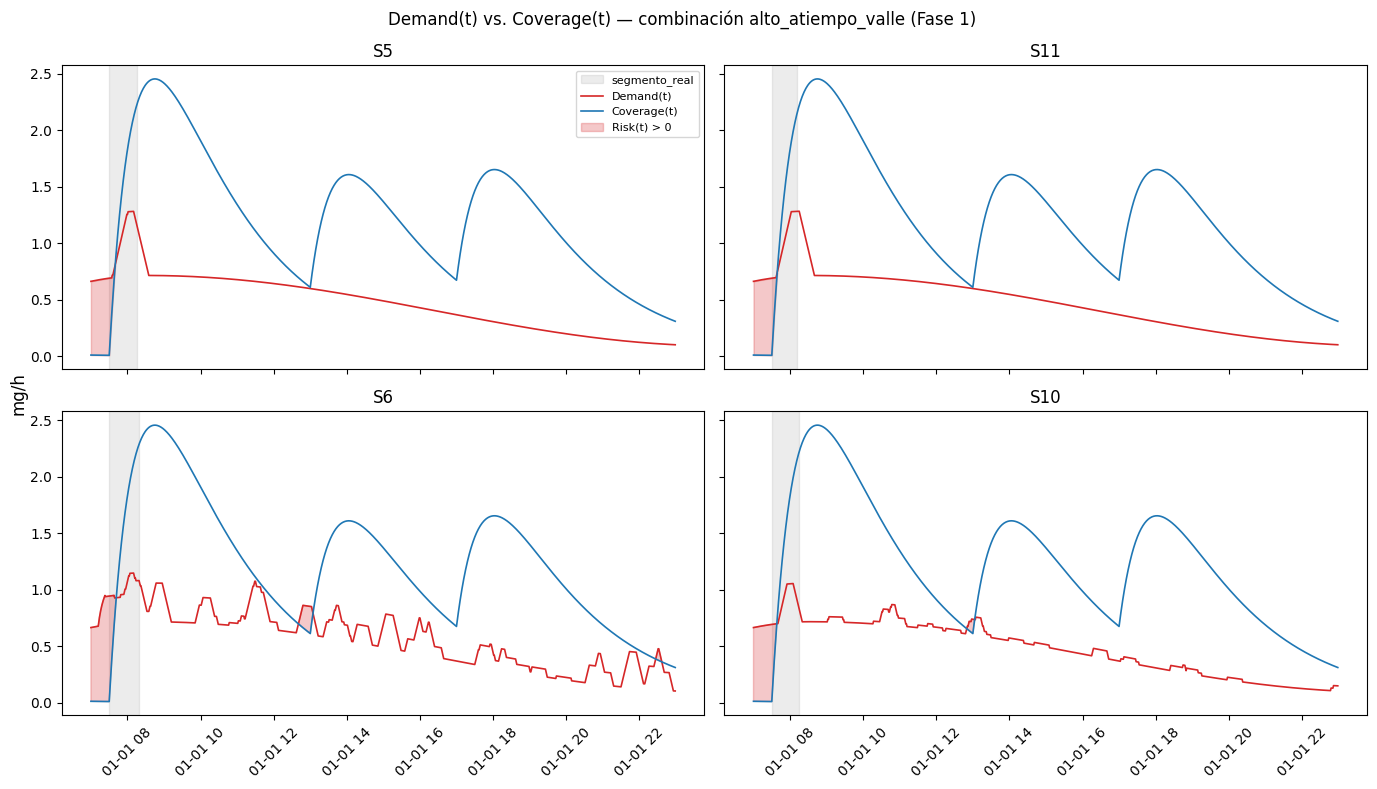

In [40]:
# ======================================================================================================
# GRÁFICO: DEMAND(t), COVERAGE(t) Y RISK(t)>0 — 4 SUJETOS (primera combinación, Fase 1)
# ======================================================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

for ax, sujeto in zip(axes.flat, SUJETOS_TODOS):
    df_dia = dias_sinteticos_fase1[sujeto]
    x = df_dia['hora_reloj']

    # Banda de fondo: segmento_real vs. resto del día
    mask_real = df_dia['origen'] == 'segmento_real'
    if mask_real.any():
        ax.axvspan(x[mask_real].iloc[0], x[mask_real].iloc[-1],
                   color='gray', alpha=0.15, label='segmento_real')

    # Demand(t) y Coverage(t)
    ax.plot(x, df_dia['demand_t'], color='tab:red', linewidth=1.2, label='Demand(t)')
    ax.plot(x, df_dia['coverage_t'], color='tab:blue', linewidth=1.2, label='Coverage(t)')

    # Risk(t) > 0 sombreado (infra-cobertura)
    ax.fill_between(x, df_dia['demand_t'], df_dia['coverage_t'],
                     where=(df_dia['risk_t'] > 0), color='tab:red', alpha=0.25,
                     interpolate=True, label='Risk(t) > 0')

    ax.set_title(sujeto)
    ax.tick_params(axis='x', rotation=45)

axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Demand(t) vs. Coverage(t) — combinación alto_atiempo_valle (Fase 1)')
fig.supylabel('mg/h')
plt.tight_layout()
plt.show()

S5, S11 y S10 dan el mismo Risk(t) —mismo rango y mismo pico (07:30, origen=segmento_real), con un % de infra-cobertura de 4,2%, 4,1% y 5,5%". Y "(94,7%)" → "(razón de máximos de 94,7%, Sección 3.5.2)— pese a que en 3.2.1 su Demand(t) máximo difería. Esto no contradice
3.2.1: el pico de Risk(t) cae justo al insertar el bout, cuando f(StressLoad) aún no ha tenido
tiempo de separar a los sujetos (ventana de persistencia recién empezando), así que ahí sí coincide.

S6 es la excepción: el pico se adelanta a las 07:23 y su origen es `fondo_antes`, no el segmento
real, con un Demand mayor (0,948) que en los otros tres. Es la misma contaminación de ruido de fondo
sostenido ya caracterizada (94,7%): en S6 el "pico de riesgo" que devuelve el pipeline
no es el bout de estrés real, sino ruido de fondo mal filtrado. Limitación conocida, no nueva.

## 3.3. Matriz completa de la Fase 1: construcción y visualización (6 combinaciones)

En 3.2 se calculó la primera combinación (`alto_atiempo_valle`) y, de paso, `ninguno_atiempo_valle`
(mismo Coverage(t), Demand(t) sin el término de estrés). Quedan las 4 combinaciones que alteran la
pauta de dosificación, cruzadas con los dos niveles de estrés:

- `alto_retrasada_valle` / `ninguno_retrasada_valle`
- `alto_omitida_valle` / `ninguno_omitida_valle`

Estas 4 no requieren recalcular Demand(t) —no depende de la pauta de dosis— sino solo recomputar
Coverage(t) sobre un `schedule` con la toma de las 07:00 retrasada u omitida, y volver a restar.

### 3.3.1. Reestructuración: diccionario de resultados por combinación.

Guarda en `resultados_escenarios_fase1` las 2 combinaciones ya calculadas en 3.2
(`alto_atiempo_valle`, `ninguno_atiempo_valle`), indexadas por sujeto y nombre de combinación. No
recalcula nada — es solo el contenedor donde irán las 6 combinaciones de la Fase 1 a medida que se
construyan, para poder compararlas todas juntas en 3.3.2 en adelante.

In [41]:
# ======================================================================================================
# DICCIONARIO DE RESULTADOS POR COMBINACIÓN
# ======================================================================================================
resultados_escenarios_fase1 = {sujeto: {} for sujeto in SUJETOS_TODOS}

for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]

    resultados_escenarios_fase1[sujeto]['alto_atiempo_valle'] = {
        'demand': df_dia['demand_t'].copy(),
        'coverage': df_dia['coverage_t'].copy(),
        'risk': df_dia['risk_t'].copy(),
    }

    demand_sin_estres = df_dia['demand_circadian'].copy()
    resultados_escenarios_fase1[sujeto]['ninguno_atiempo_valle'] = {
        'demand': demand_sin_estres,
        'coverage': df_dia['coverage_t'].copy(),  # misma pauta de dosis -> misma Coverage(t)
        'risk': demand_sin_estres - df_dia['coverage_t'],
    }

    print(f"{sujeto}: combinaciones registradas -> {list(resultados_escenarios_fase1[sujeto].keys())}")

S5: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle']
S11: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle']
S6: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle']
S10: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle']


### 3.3.2. Variantes de patrón de dosificación: retrasada (2h) y omitida.

In [42]:
# ======================================================================================================
# GENERACIÓN DE LAS DOS COMBINACIONES DE DOSIS QUE FALTABAN (estrés=alto)
# ======================================================================================================
from formulario_utils import aplicar_variante_dosis

RETRASO_HORAS = 2.0  # pendiente de confirmar

for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]
    fecha_dia_sintetico = df_dia['hora_reloj'].dt.normalize().iloc[0]
    schedule_base = build_standard_schedule(fecha_dia_sintetico - pd.Timedelta(days=1), n_days=2)

    for tipo, nombre in [('retrasada', 'alto_retrasada_valle'), ('omitida', 'alto_omitida_valle')]:
        schedule_variante = aplicar_variante_dosis(schedule_base, fecha_dia_sintetico, '07:30', tipo, RETRASO_HORAS)
        coverage_variante = compute_coverage(schedule_variante, df_dia['hora_reloj'], pk)

        # Demand(t) con estrés (alto) ya está calculado en df_dia['demand_t'] -- se reutiliza tal cual,
        # la variante de dosis no afecta a StressLoad(t) ni a Demand(t), solo a Coverage(t)
        resultados_escenarios_fase1[sujeto][nombre] = {
            'demand': df_dia['demand_t'].copy(),
            'coverage': coverage_variante.values,
            'risk': df_dia['demand_t'].values - coverage_variante.values,
        }

    print(f"{sujeto}: combinaciones registradas -> {list(resultados_escenarios_fase1[sujeto].keys())}")

S5: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle']
S11: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle']
S6: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle']
S10: combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle']


### 3.3.3. Últimas dos combinaciones (estrés=ninguno) — matriz completa de 6.

In [43]:
# ======================================================================================================
# ÚLTIMAS DOS COMBINACIONES: ESTRÉS=NINGUNO, DOSIS RETRASADA/OMITIDA
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]
    demand_sin_estres = df_dia['demand_circadian'].values

    for nombre_con_estres, nombre_sin_estres in [
        ('alto_retrasada_valle', 'ninguno_retrasada_valle'),
        ('alto_omitida_valle', 'ninguno_omitida_valle'),
    ]:
        coverage_variante = resultados_escenarios_fase1[sujeto][nombre_con_estres]['coverage']  # misma Coverage(t)
        resultados_escenarios_fase1[sujeto][nombre_sin_estres] = {
            'demand': demand_sin_estres,
            'coverage': coverage_variante,
            'risk': demand_sin_estres - coverage_variante,
        }

    print(f"{sujeto}: {len(resultados_escenarios_fase1[sujeto])} combinaciones registradas -> "
          f"{list(resultados_escenarios_fase1[sujeto].keys())}")

S5: 6 combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle', 'ninguno_retrasada_valle', 'ninguno_omitida_valle']
S11: 6 combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle', 'ninguno_retrasada_valle', 'ninguno_omitida_valle']
S6: 6 combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle', 'ninguno_retrasada_valle', 'ninguno_omitida_valle']
S10: 6 combinaciones registradas -> ['alto_atiempo_valle', 'ninguno_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle', 'ninguno_retrasada_valle', 'ninguno_omitida_valle']


### 3.3.4. Comparación gráfica de las 6 combinaciones — 4 sujetos.

In [44]:
# ======================================================================================================
# FUNCIÓN: COMPARACIÓN ALTO vs. NINGUNO, EN GRID 2x2 POR SUJETO (misma pauta de dosis fija)
# ======================================================================================================
from matplotlib.gridspec import GridSpec
COLORES_COMBINACIONES = ['tab:red', 'tab:blue', 'tab:green', 'tab:purple', 'tab:brown', 'tab:pink']

def graficar_comparacion_grid(nombres_combinaciones, estilos=None, titulo=None):
    estilos = estilos or {}
    fig = plt.figure(figsize=(16, 9))
    gs_externo = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.15)

    for pos, sujeto in enumerate(SUJETOS_TODOS):  # orden fijo: S5, S11, S6, S10 -> 2x2
        fila, col = divmod(pos, 2)
        gs_sujeto = gs_externo[fila, col].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.1)
        ax_demand = fig.add_subplot(gs_sujeto[0])
        ax_risk = fig.add_subplot(gs_sujeto[1], sharex=ax_demand)

        df_dia = dias_sinteticos_fase1[sujeto]
        datos = {n: resultados_escenarios_fase1[sujeto][n] for n in nombres_combinaciones}
        coverages = [d['coverage'] for d in datos.values()]
        coverage_compartida = all(np.allclose(c, coverages[0]) for c in coverages)
        if coverage_compartida:
            ax_demand.plot(df_dia['hora_reloj'], coverages[0], color='gray', linewidth=1,
                            label='Coverage(t)', alpha=0.5, zorder=1)

        for i, (nombre, d) in enumerate(datos.items()):
            color = COLORES_COMBINACIONES[i % len(COLORES_COMBINACIONES)]
            ls = estilos.get(nombre, '-')
            zorder = 10 if ls != '-' else 2
            ax_demand.plot(df_dia['hora_reloj'], d['demand'], color=color, linewidth=1.3,
                            linestyle=ls, zorder=zorder, label=f'Demand(t) — {nombre}')
            ax_risk.plot(df_dia['hora_reloj'], d['risk'], color=color, linewidth=1.3,
                         linestyle=ls, zorder=zorder, label=nombre)

        mask_real = df_dia['origen'] == 'segmento_real'
        for ax in (ax_demand, ax_risk):
            ax.axvspan(df_dia.loc[mask_real, 'hora_reloj'].iloc[0], df_dia.loc[mask_real, 'hora_reloj'].iloc[-1],
                       color='red', alpha=0.08, zorder=0)
        ax_risk.axhline(0, color='black', linewidth=0.5, zorder=1)
        ax_demand.set_title(sujeto, fontsize=10)
        ax_demand.tick_params(axis='x', labelbottom=False)
        ax_risk.tick_params(axis='x', rotation=45, labelsize=7)
        ax_demand.legend(fontsize=6, loc='upper right')
        ax_risk.legend(fontsize=6, loc='upper right')

    if titulo:
        fig.suptitle(titulo, y=0.99)
    plt.show()

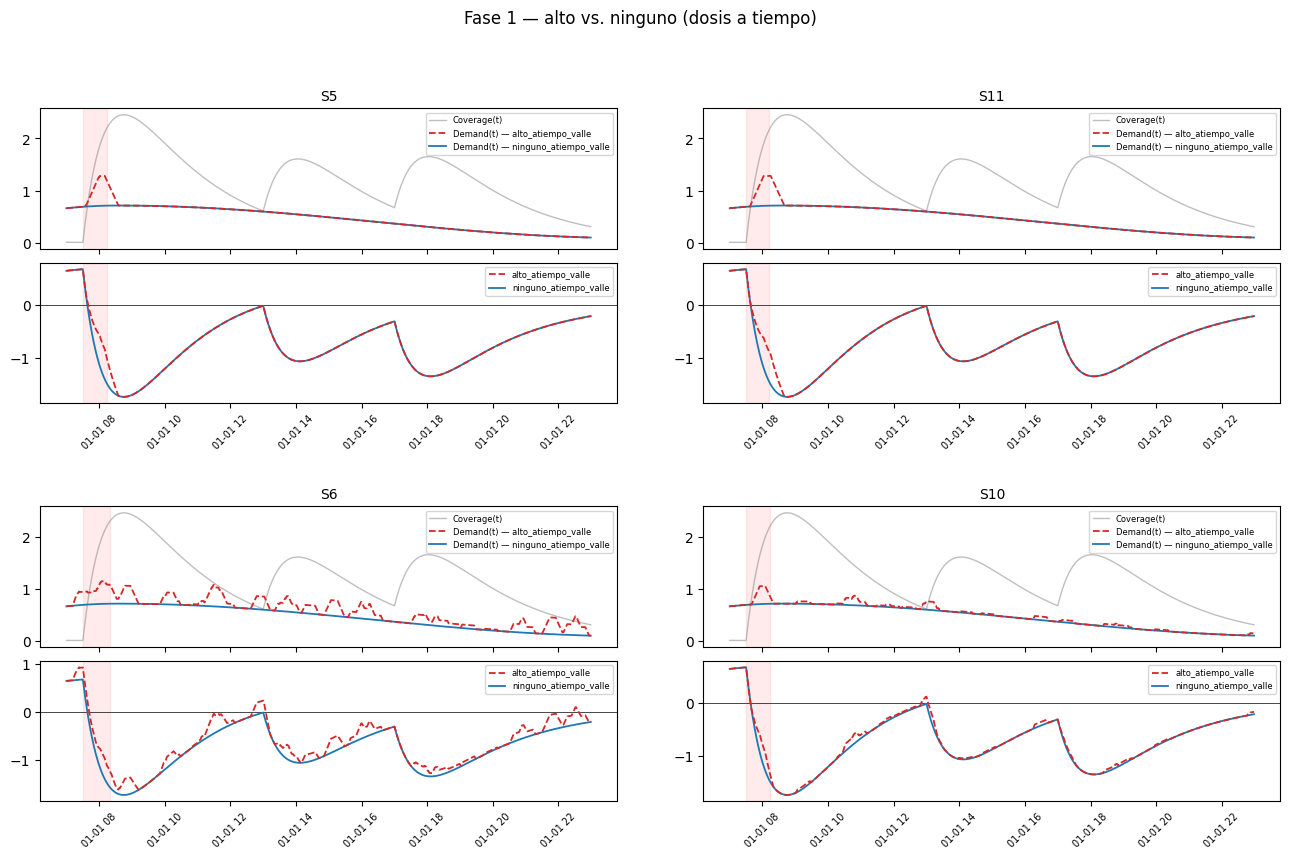

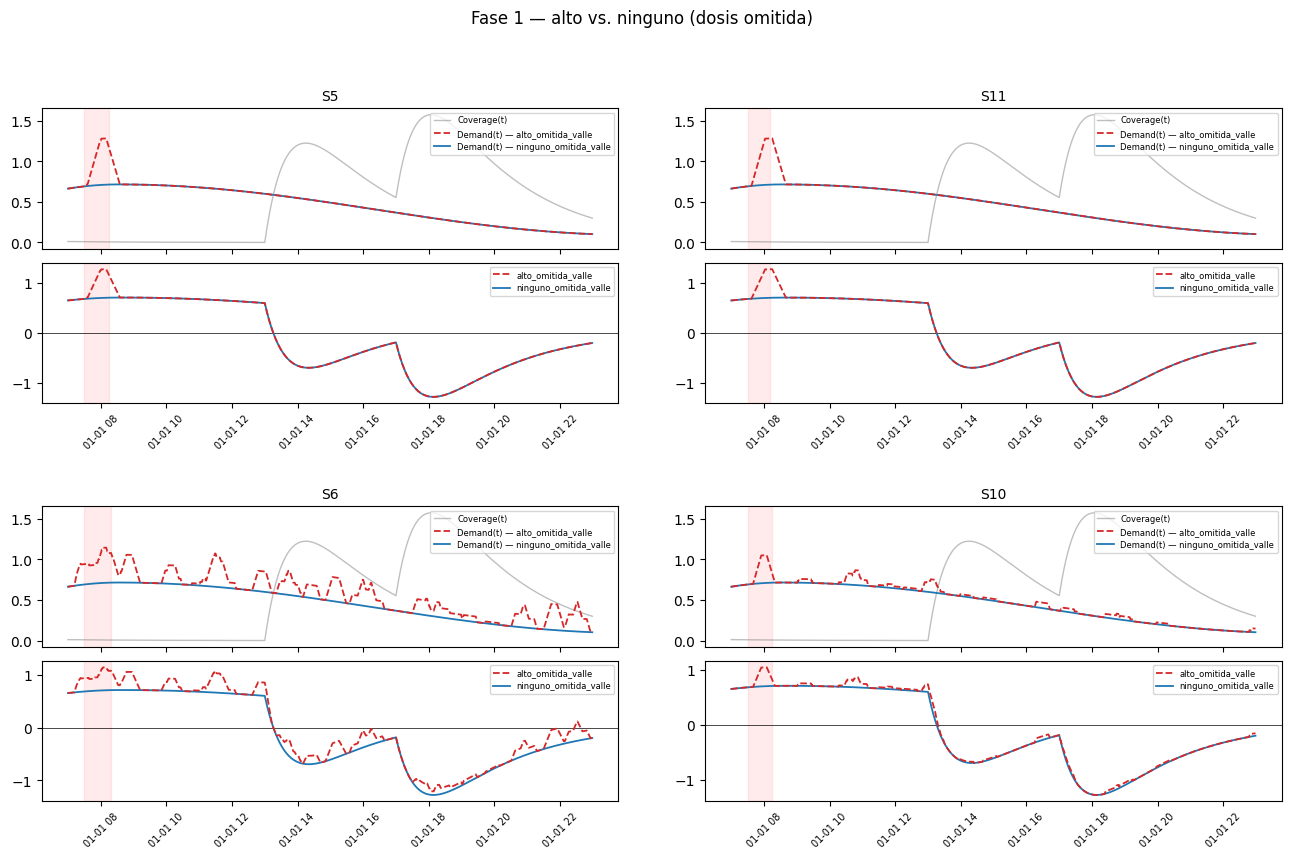

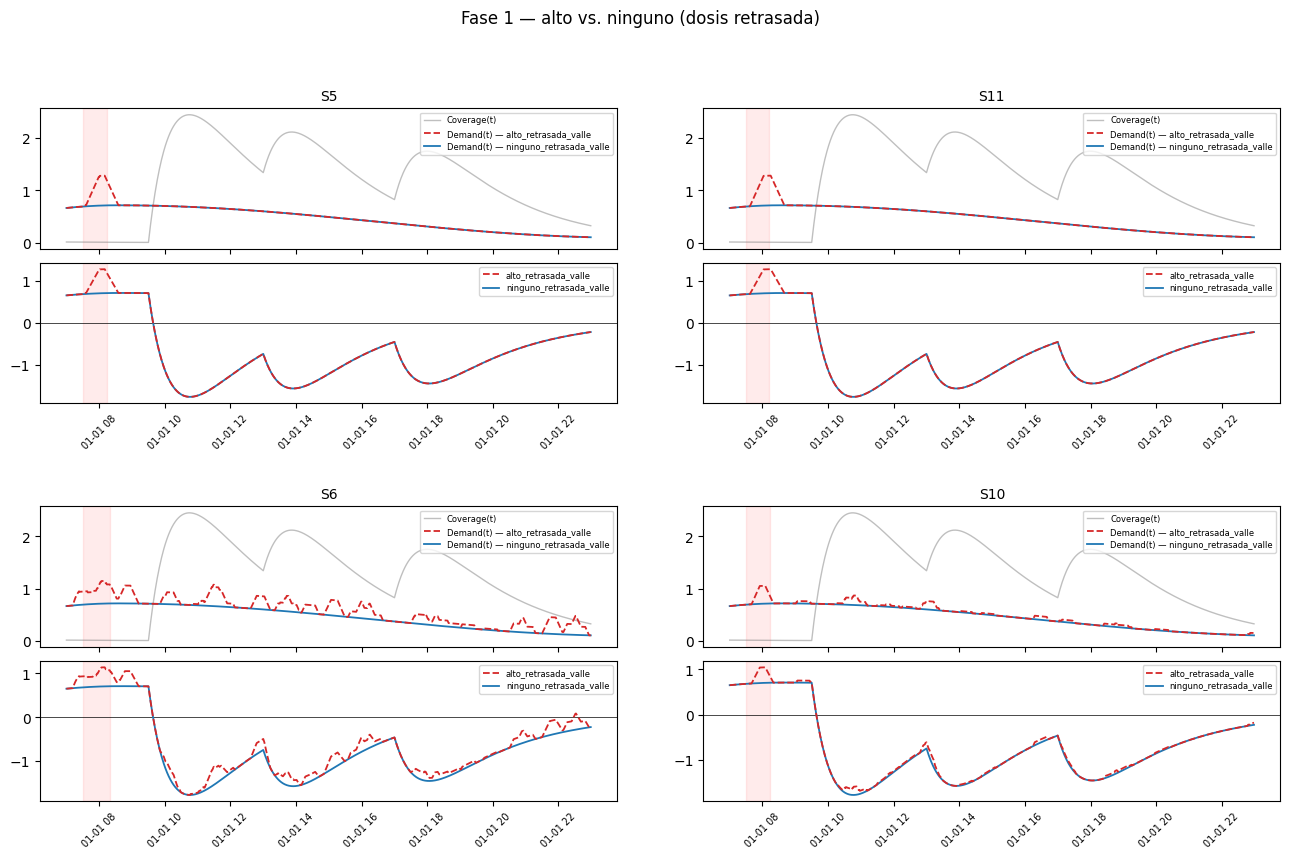

In [45]:
# A tiempo
graficar_comparacion_grid(['alto_atiempo_valle', 'ninguno_atiempo_valle'],
                           estilos={'alto_atiempo_valle': '--'},
                           titulo='Fase 1 — alto vs. ninguno (dosis a tiempo)')

# Omitida
graficar_comparacion_grid(['alto_omitida_valle', 'ninguno_omitida_valle'],
                           estilos={'alto_omitida_valle': '--'},
                           titulo='Fase 1 — alto vs. ninguno (dosis omitida)')

# Retrasada
graficar_comparacion_grid(['alto_retrasada_valle', 'ninguno_retrasada_valle'],
                           estilos={'alto_retrasada_valle': '--'},
                           titulo='Fase 1 — alto vs. ninguno (dosis retrasada)')

Los tres gráficos confirman el mismo patrón cualitativo en las tres pautas de dosis: la diferencia
entre `alto` y `ninguno` se concentra exclusivamente en la ventana del *bout* real (~07:30-08:15,
franja roja); fuera de ella, las curvas de Demand(t) y Risk(t) son prácticamente indistinguibles en
S5, S11 y S10, incluidas las grandes oscilaciones posteriores causadas por la dosis omitida o
retrasada — que afectan por igual a ambas líneas, como cabía esperar de que Coverage(t) no dependa
del estrés (ya verificado numéricamente en 3.2.2, aquí se confirma visualmente para las 6
combinaciones). La magnitud del salto en el pico del *bout* es también consistente entre las tres
pautas, reforzando que es una firma del estrés en sí, no un artefacto ligado a una dosis concreta.

S6 es la única excepción, y lo es en las tres pautas por igual: la línea `alto` (discontinua) se
separa de `ninguno` de forma sostenida durante todo el día, no solo en el *bout* — la misma
contaminación de ruido de fondo ya caracterizada, que tampoco depende de la pauta de
dosis. Confirma que la limitación de S6 es propia del clasificador sobre ese sujeto, independiente
de qué se compare después.  

Una precisión importante sobre qué compara realmente `alto` vs. `ninguno`: `ninguno_*` no es "el
mismo día sin el *bout* real", sino Demand_circadian(t) puro, con f(StressLoad(t)) anulado las 24h
— no solo durante la franja roja. En S5/S11 esto no tiene consecuencias prácticas porque el ruido
de fondo puro es casi nulo (0%/12%, Sección 3.5.2), así que ambas lecturas ("sin el bout" vs. "sin
ningún término de estrés") coinciden. En S6 sí importa: la línea `alto` arrastra la contaminación
de ruido sostenido durante todo el día (visible fuera de la franja roja en los tres gráficos), no
solo el efecto del *bout*, por lo que la comparación en S6 mezcla dos fuentes distintas de señal en
vez de aislar una — limitación ya conocida, pero que aquí se hace visible de forma
directa por primera vez en la matriz de combinaciones.

## 3.4. Funciones genéricas de métricas

### 3.4.1. Métricas genéricas

In [46]:
# ======================================================================================================
# FUNCIONES GENÉRICAS DE MÉTRICAS — PARAMETRIZADAS POR FASE
# ======================================================================================================
PARES_LIMPIOS = [
    ('ninguno_atiempo_valle', 'ninguno_retrasada_valle'),
    ('ninguno_retrasada_valle', 'ninguno_omitida_valle'),
    ('ninguno_atiempo_valle', 'ninguno_omitida_valle'),
    ('alto_atiempo_valle', 'alto_retrasada_valle'),
    ('alto_retrasada_valle', 'alto_omitida_valle'),
    ('alto_atiempo_valle', 'alto_omitida_valle'),
    ('ninguno_atiempo_valle', 'alto_atiempo_valle'),
    ('ninguno_retrasada_valle', 'alto_retrasada_valle'),
    ('ninguno_omitida_valle', 'alto_omitida_valle'),
]

COMBINACIONES_POSIBLES = [
    'ninguno_atiempo_valle', 'ninguno_retrasada_valle', 'ninguno_omitida_valle',
    'alto_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle',
]

TOL_EMPATE_MG = 0.01  # mg: diferencias de AUC iguales o menores se consideran empate

def comparar_auc(a, b, tol=TOL_EMPATE_MG):
    """+1 si b > a (concordante), 0 si empate (|b-a| <= tol), -1 si discordante."""
    d = b - a
    if d > tol:
        return 1
    if d < -tol:
        return -1
    return 0

MIN_CALENTAMIENTO = 25  # min iniciales del día sintético con ventanas rolling / f(t) incompletas (min_periods=1)

def _inicio_efectivo(df_dia, inicio_ventana):
    """Inicio de la ventana de evaluación, sin los primeros MIN_CALENTAMIENTO min del día."""
    t0 = df_dia['hora_reloj'].iloc[0] + pd.Timedelta(minutes=MIN_CALENTAMIENTO)
    return max(inicio_ventana, t0)

def calcular_aucs(dias_dict, resultados_dict, sujeto, hora_inicio_ventana="07:00", hora_fin_ventana="13:00"):
    """
    AUC de Risk(t)>0 en la ventana [hora_inicio_ventana, hora_fin_ventana), para las
    6 combinaciones de un sujeto. Por defecto reproduce el comportamiento de la
    Fase 1 (desde el inicio del día hasta la toma de las 13:00).
    """
    df_dia = dias_dict[sujeto]
    fecha = df_dia['hora_reloj'].dt.normalize().iloc[0]

    hh_i, mm_i = map(int, hora_inicio_ventana.split(':'))
    inicio_ventana = fecha + pd.Timedelta(hours=hh_i, minutes=mm_i)
    hh_f, mm_f = map(int, hora_fin_ventana.split(':'))
    fin_ventana = fecha + pd.Timedelta(hours=hh_f, minutes=mm_f)

    inicio_ventana = _inicio_efectivo(df_dia, inicio_ventana)
    ventana_relevante = ((df_dia['hora_reloj'] >= inicio_ventana) & (df_dia['hora_reloj'] < fin_ventana)).values

    return {
        nombre: np.trapezoid(np.clip(np.asarray(resultados_dict[sujeto][nombre]['risk'])[ventana_relevante], 0, None)) / 60
        for nombre in COMBINACIONES_POSIBLES
    }


def kendall_por_pares_generico(dias_dict, resultados_dict, sujetos, hora_inicio_ventana="07:00", hora_fin_ventana="13:00"):
    for sujeto in sujetos:
        aucs = calcular_aucs(dias_dict, resultados_dict, sujeto, hora_inicio_ventana, hora_fin_ventana)
        concordantes, empates, discordancias = 0, [], []
        for menor, mayor in PARES_LIMPIOS:
            r = comparar_auc(aucs[menor], aucs[mayor])
            if r > 0:
                concordantes += 1
            elif r == 0:
                empates.append((menor, mayor))
            else:
                discordancias.append((menor, mayor))
        print(f"{sujeto}: {concordantes}/{len(PARES_LIMPIOS)} pares limpios concordantes "
              f"({100*concordantes/len(PARES_LIMPIOS):.0f}%)", end="")
        if empates:
            print(f" | empates: {empates}", end="")
        if discordancias:
            print(f" | discordantes: {discordancias}", end="")
        print()


# ======================================================================================================
# HORAS DE DOSIS POR PATRÓN — GENERALIZADA (antes fija a la toma de las 07:30)
# ======================================================================================================
def horas_dosis_por_combinacion(hora_toma_base, todas_las_tomas, retraso_horas=2.0):
    """
    Devuelve un diccionario {'atiempo': [...], 'retrasada': [...], 'omitida': [...]}
    con las horas (str 'HH:MM') de todas las tomas del día bajo cada patrón, cuando
    la toma manipulada es `hora_toma_base` (p. ej. '13:00') y el resto del día se
    mantiene sin cambios.

    `todas_las_tomas`: lista de horas de la pauta estándar completa, p. ej.
    ['07:30', '13:00', '17:00'].
    `retraso_horas`: mismo parámetro ya usado en aplicar_variante_dosis().
    """
    def sumar_horas(hora_str, horas_a_sumar):
        hh, mm = map(int, hora_str.split(':'))
        total_min = hh * 60 + mm + int(horas_a_sumar * 60)
        return f"{(total_min // 60) % 24:02d}:{total_min % 60:02d}"

    atiempo = list(todas_las_tomas)
    retrasada = [sumar_horas(h, retraso_horas) if h == hora_toma_base else h for h in todas_las_tomas]
    omitida = [h for h in todas_las_tomas if h != hora_toma_base]

    return {'atiempo': atiempo, 'retrasada': retrasada, 'omitida': omitida}


# --- Uso para la Fase 1 (ya construida, se mantiene igual): toma manipulada = 07:30 ---
HORAS_DOSIS_POR_COMBINACION = horas_dosis_por_combinacion('07:30', ['07:30', '13:00', '17:00'])

# --- Uso para las Fases 2 y 3 (nuevo): toma manipulada = 13:00 ---
HORAS_DOSIS_POR_COMBINACION_13H = horas_dosis_por_combinacion('13:00', ['07:30', '13:00', '17:00'])
MARGEN_ABSORCION_H = 2.0  # cubre tmax≈1.25h con margen        

def dentro_de_alguna_ventana(hora, ventanas):
    return any(inicio <= hora <= fin for inicio, fin in ventanas)

def saltos_abruptos_generico(dias_dict, resultados_dict, sujetos, horas_dosis_dict=None):
    """
    Ausencia de saltos abruptos, para cualquier fase. Excluye los primeros
    MIN_CALENTAMIENTO minutos del día (ventanas parciales) tanto del percentil 95
    de referencia como de la búsqueda de saltos.
    """
    for sujeto in sujetos:
        df_dia = dias_dict[sujeto]
        horas_all = df_dia['hora_reloj']
        t_ini = horas_all.iloc[0] + pd.Timedelta(minutes=MIN_CALENTAMIENTO)
        mask_fondo = (df_dia['origen'] != 'segmento_real').values
        mask_ok = (horas_all >= t_ini).values
        horas = horas_all.iloc[1:].reset_index(drop=True)
        print(f"\n--- {sujeto} ---")
        for nombre in COMBINACIONES_POSIBLES:
            risk = np.asarray(resultados_dict[sujeto][nombre]['risk'])
            derivada = np.diff(risk)
            referencia = derivada[(mask_fondo & mask_ok)[1:]]
            percentil_95 = np.percentile(np.abs(referencia), 95)
            ventanas = construir_ventanas_esperadas_generico(df_dia, nombre, horas_dosis_dict)
            saltos_anomalos = [
                (horas.iloc[i], d) for i, d in enumerate(derivada)
                if horas.iloc[i] >= t_ini and abs(d) > percentil_95
                and not dentro_de_alguna_ventana(horas.iloc[i], ventanas)
            ]
            estado = "✅ sin saltos anómalos" if len(saltos_anomalos) == 0 else f"⚠️ {len(saltos_anomalos)} saltos anómalos"
            print(f"  {nombre}: percentil 95 = {percentil_95:.3f} | {estado}")

def construir_ventanas_esperadas_generico(df_dia, nombre_combinacion, horas_dosis_dict=None):
    """
    Igual que antes, pero ahora recibe horas_dosis_dict como argumento en vez de
    leer siempre HORAS_DOSIS_POR_COMBINACION. Si no se pasa nada, usa la de la
    Fase 1 (toma de las 07:30) por compatibilidad con el código ya existente.
    """
    if horas_dosis_dict is None:
        horas_dosis_dict = HORAS_DOSIS_POR_COMBINACION

    fecha = df_dia['hora_reloj'].dt.normalize().iloc[0]
    ventanas = []
    if nombre_combinacion.startswith('alto_'):
        mask_real = df_dia['origen'] == 'segmento_real'
        ventanas.append((df_dia.loc[mask_real, 'hora_reloj'].iloc[0], df_dia.loc[mask_real, 'hora_reloj'].iloc[-1]))
    patron_dosis = nombre_combinacion.split('_')[1]
    for hora_str in horas_dosis_dict[patron_dosis]:
        hh, mm = map(int, hora_str.split(":"))
        inicio_dosis = fecha + pd.Timedelta(hours=hh, minutes=mm)
        ventanas.append((inicio_dosis, inicio_dosis + pd.Timedelta(hours=MARGEN_ABSORCION_H)))
    return ventanas

N_REPETICIONES = 100

PARES_GENUINOS = [
    ('ninguno_atiempo_valle', 'ninguno_retrasada_valle'),
    ('ninguno_retrasada_valle', 'ninguno_omitida_valle'),
    ('ninguno_atiempo_valle', 'ninguno_omitida_valle'),
    ('alto_atiempo_valle', 'alto_retrasada_valle'),
    ('alto_retrasada_valle', 'alto_omitida_valle'),
    ('alto_atiempo_valle', 'alto_omitida_valle'),
]
PARES_GARANTIZADOS = [
    ('ninguno_atiempo_valle', 'alto_atiempo_valle'),
    ('ninguno_retrasada_valle', 'alto_retrasada_valle'),
    ('ninguno_omitida_valle', 'alto_omitida_valle'),
]
UMBRAL_ROBUSTEZ = 0.85  # ya fijado en el documento de escenarios sintéticos


def generar_risk_con_ruido_generico(dias_dict, resultados_dict, sujeto, ruido_std=15.0, seed=None):
    """Igual que generar_risk_con_ruido (Sección 3.13), pero parametrizada por fase."""
    rng = np.random.default_rng(seed)
    df_dia = dias_dict[sujeto]

    hr_ruidoso = df_dia['HR_mean_bruto'].values + rng.normal(0, ruido_std, size=len(df_dia))
    df_ruido = pd.DataFrame({'HR_mean_bruto': hr_ruidoso})
    for w in VENTANAS_ROLLING:
        df_ruido[f'HR_mean_roll_mean_{w}m'] = df_ruido['HR_mean_bruto'].rolling(window=w, min_periods=1).mean()
        df_ruido[f'HR_mean_roll_std_{w}m'] = df_ruido['HR_mean_bruto'].rolling(window=w, min_periods=1).std().fillna(0)

    media_hr, std_hr = stats_baseline[sujeto]['HR_mean']['mean'], stats_baseline[sujeto]['HR_mean']['std']
    df_ruido['HR_mean_norm'] = (df_ruido['HR_mean_bruto'] - media_hr) / std_hr
    for w in VENTANAS_ROLLING:
        for stat in ['mean', 'std']:
            col_bruta = f'HR_mean_roll_{stat}_{w}m'
            media, std = stats_baseline[sujeto][col_bruta]['mean'], stats_baseline[sujeto][col_bruta]['std']
            df_ruido[f'{col_bruta}_norm'] = (df_ruido[col_bruta] - media) / std
    df_ruido['HR_mean_norm_lag_1m_norm'] = df_ruido['HR_mean_norm'].shift(1).fillna(0)
    df_ruido['HR_mean_norm_lag_2m_norm'] = df_ruido['HR_mean_norm'].shift(2).fillna(0)

    stress_pred_ruido = modelo_stress.predict(df_ruido[columnas_camino_B])
    f_stressload_ruido = pd.Series(stress_pred_ruido).rolling(window=VENTANA_F_STRESSLOAD_MIN, min_periods=1).mean().values

    demand_alto_ruido = df_dia['demand_circadian'].values + D_REF_MID * f_stressload_ruido
    demand_ninguno_ruido = df_dia['demand_circadian'].values

    risk_ruido = {}
    for nombre in COMBINACIONES_POSIBLES:
        coverage = np.asarray(resultados_dict[sujeto][nombre]['coverage'])
        demand = demand_alto_ruido if nombre.startswith('alto_') else demand_ninguno_ruido
        risk_ruido[nombre] = demand - coverage
    return risk_ruido


def monte_carlo_generico(dias_dict, resultados_dict, sujetos, n_repeticiones=100,
                          hora_inicio_ventana="07:00", hora_fin_ventana="13:00"):
    """
    Robustez Monte Carlo, separando pares genuinos de garantizados, para cualquier
    fase. Por defecto reproduce el comportamiento de la Fase 1 (ventana 07:00-13:00).
    """
    for sujeto in sujetos:
        df_dia = dias_dict[sujeto]
        fecha = df_dia['hora_reloj'].dt.normalize().iloc[0]

        hh_i, mm_i = map(int, hora_inicio_ventana.split(':'))
        inicio_ventana = fecha + pd.Timedelta(hours=hh_i, minutes=mm_i)
        hh_f, mm_f = map(int, hora_fin_ventana.split(':'))
        fin_ventana = fecha + pd.Timedelta(hours=hh_f, minutes=mm_f)
        inicio_ventana = _inicio_efectivo(df_dia, inicio_ventana)
        ventana_relevante = ((df_dia['hora_reloj'] >= inicio_ventana) & (df_dia['hora_reloj'] < fin_ventana)).values

        contador_concordante = {par: 0 for par in PARES_GENUINOS + PARES_GARANTIZADOS}
        contador_empate = {par: 0 for par in PARES_GENUINOS + PARES_GARANTIZADOS}
        for rep in range(n_repeticiones):
            risk_ruido = generar_risk_con_ruido_generico(dias_dict, resultados_dict, sujeto, 15.0, seed=1000 + rep)
            aucs_ruido = {
                nombre: np.trapezoid(np.clip(risk_ruido[nombre][ventana_relevante], 0, None)) / 60
                for nombre in COMBINACIONES_POSIBLES
            }
            for menor, mayor in PARES_GENUINOS + PARES_GARANTIZADOS:
                r = comparar_auc(aucs_ruido[menor], aucs_ruido[mayor])
                if r > 0:
                    contador_concordante[(menor, mayor)] += 1
                elif r == 0:
                    contador_empate[(menor, mayor)] += 1
                    
        print(f"\n--- {sujeto} ---")
        print("Pares genuinamente puestos a prueba:")
        for par in PARES_GENUINOS:
            pct_conc = contador_concordante[par] / n_repeticiones
            pct_emp = contador_empate[par] / n_repeticiones
            if pct_conc >= UMBRAL_ROBUSTEZ:
                marca = "✅"
            elif pct_emp >= UMBRAL_ROBUSTEZ:
                marca = "🟡"
            else:
                marca = "⚠️"
            extra = f" (+{contador_empate[par]} empates)" if contador_empate[par] > 0 else ""
            print(f"  {marca} {par[0]} < {par[1]}: {contador_concordante[par]}/{n_repeticiones} "
                  f"({100*pct_conc:.0f}%){extra}")

print("Funciones genéricas de métricas cargadas — reutilizables desde cualquier capítulo de fase.")


Funciones genéricas de métricas cargadas — reutilizables desde cualquier capítulo de fase.


### 3.4.2. Funciones de visualizacion de resultados

In [47]:
def graficar_comparacion_grid(dias_dict, resultados_dict, nombres_combinaciones, estilos=None, titulo=None):
    estilos = estilos or {}
    fig = plt.figure(figsize=(16, 9))
    gs_externo = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.15)

    for pos, sujeto in enumerate(SUJETOS_TODOS):
        fila, col = divmod(pos, 2)
        gs_sujeto = gs_externo[fila, col].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.1)
        ax_demand = fig.add_subplot(gs_sujeto[0])
        ax_risk = fig.add_subplot(gs_sujeto[1], sharex=ax_demand)

        df_dia = dias_dict[sujeto]
        datos = {n: resultados_dict[sujeto][n] for n in nombres_combinaciones}
        coverages = [d['coverage'] for d in datos.values()]
        coverage_compartida = all(np.allclose(c, coverages[0]) for c in coverages)
        if coverage_compartida:
            ax_demand.plot(df_dia['hora_reloj'], coverages[0], color='gray', linewidth=1,
                            label='Coverage(t)', alpha=0.5, zorder=1)

        for i, (nombre, d) in enumerate(datos.items()):
            color = COLORES_COMBINACIONES[i % len(COLORES_COMBINACIONES)]
            ls = estilos.get(nombre, '-')
            zorder = 10 if ls != '-' else 2
            ax_demand.plot(df_dia['hora_reloj'], d['demand'], color=color, linewidth=1.3,
                            linestyle=ls, zorder=zorder, label=f'Demand(t) — {nombre}')
            ax_risk.plot(df_dia['hora_reloj'], d['risk'], color=color, linewidth=1.3,
                         linestyle=ls, zorder=zorder, label=nombre)

        mask_real = df_dia['origen'] == 'segmento_real'
        for ax in (ax_demand, ax_risk):
            ax.axvspan(df_dia.loc[mask_real, 'hora_reloj'].iloc[0], df_dia.loc[mask_real, 'hora_reloj'].iloc[-1],
                       color='red', alpha=0.08, zorder=0)
        ax_risk.axhline(0, color='black', linewidth=0.5, zorder=1)
        ax_demand.set_title(sujeto, fontsize=10)
        ax_demand.tick_params(axis='x', labelbottom=False)
        ax_risk.tick_params(axis='x', rotation=45, labelsize=7)
        ax_demand.legend(fontsize=6, loc='upper right')
        ax_risk.legend(fontsize=6, loc='upper right')

    if titulo:
        fig.suptitle(titulo, y=0.99)
    plt.show()

def heatmap_concordancia_kendall(dias_dict, resultados_dict, sujetos, hora_inicio_ventana="07:00",
                                   hora_fin_ventana="13:00", titulo=""):
    matriz = np.zeros((len(PARES_LIMPIOS), len(sujetos)))

    for j, sujeto in enumerate(sujetos):
        aucs = calcular_aucs(dias_dict, resultados_dict, sujeto, hora_inicio_ventana, hora_fin_ventana)
        for i, (menor, mayor) in enumerate(PARES_LIMPIOS):
            r = comparar_auc(aucs[menor], aucs[mayor])
            matriz[i, j] = 2 if r > 0 else (1 if r == 0 else 0)

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.matplotlib.colors.ListedColormap(['#F0997B', '#F5C563', '#5DCAA5'])  # discordante/empate/concordante
    ax.imshow(matriz, cmap=cmap, vmin=0, vmax=2, aspect='auto')

    ax.set_xticks(range(len(sujetos)))
    ax.set_xticklabels(sujetos)
    ax.set_yticks(range(len(PARES_LIMPIOS)))
    ax.set_yticklabels([f"{a} < {b}" for a, b in PARES_LIMPIOS], fontsize=8)

    marcas = {0: "✗", 1: "=", 2: "✓"}
    for i in range(len(PARES_LIMPIOS)):
        for j in range(len(sujetos)):
            ax.text(j, i, marcas[matriz[i, j]], ha='center', va='center', fontsize=11)

    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

## 3.5 Verificación del mecanismo de protección de f(StressLoad(t)): filtra ruido disperso, no ruido sostenido

Cuestión planteada explícitamente antes de aceptar la exclusión de S6/S10 sin más matiz: la ventana
de 25 minutos de `f(StressLoad(t))` exige persistencia temporal — ¿filtra realmente el ruido puntual
del clasificador, de modo que la conclusión correcta sea que el sistema es robusto frente a los
falsos positivos ya documentados, en vez de estar comprometido por ellos?

### 3.5.1. Primera comprobación (con artefacto de frontera)

Antes de aceptar sin más la exclusión de S6/S10, se comprueba si el filtro de persistencia de 25 min
de f(StressLoad(t)) realmente atenúa el ruido puntual del clasificador: se compara el máximo de
`f_stressload` alcanzado en todo el fondo generado por bootstrap frente al máximo durante el *bout* real. Esta
primera versión compara el fondo completo sin excluir nada — se revisa en 3.5.2 porque el resultado
resulta engañoso por un artefacto de frontera cerca del final del segmento real.

In [48]:
# ======================================================================================================
# MÁXIMO DE f_stressload EN EL FONDO, FRENTE AL MÁXIMO DURANTE EL BOUT REAL
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]
    mask_fondo = df_dia['origen'] != 'segmento_real'
    mask_real = df_dia['origen'] == 'segmento_real'

    f_max_fondo = df_dia.loc[mask_fondo, 'f_stressload'].max()
    f_max_real = df_dia.loc[mask_real, 'f_stressload'].max()

    print(f"{sujeto}: f_stressload máximo en el FONDO (ruido del clasificador) = {f_max_fondo:.3f} "
          f"| máximo durante el BOUT real = {f_max_real:.3f} "
          f"| ratio fondo/bout = {100*f_max_fondo/f_max_real:.1f}%")

S5: f_stressload máximo en el FONDO (ruido del clasificador) = 0.760 | máximo durante el BOUT real = 1.000 | ratio fondo/bout = 76.0%
S11: f_stressload máximo en el FONDO (ruido del clasificador) = 1.000 | máximo durante el BOUT real = 1.000 | ratio fondo/bout = 100.0%
S6: f_stressload máximo en el FONDO (ruido del clasificador) = 0.720 | máximo durante el BOUT real = 0.760 | ratio fondo/bout = 94.7%
S10: f_stressload máximo en el FONDO (ruido del clasificador) = 0.320 | máximo durante el BOUT real = 0.600 | ratio fondo/bout = 53.3%


In [49]:
# ======================================================================================================
# DIAGNÓSTICO: ¿DÓNDE OCURRE EXACTAMENTE EL MÁXIMO DE f_stressload EN EL FONDO?
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]
    mask_fondo = df_dia['origen'] != 'segmento_real'

    idx_max_fondo = df_dia.loc[mask_fondo, 'f_stressload'].idxmax()
    fila_max = df_dia.loc[idx_max_fondo]
    posicion_en_el_dia = df_dia.index.get_loc(idx_max_fondo)  # posición 0-based desde el inicio del día

    print(f"{sujeto}: máximo de f_stressload en el fondo = {fila_max['f_stressload']:.3f} "
          f"en {fila_max['hora_reloj'].strftime('%H:%M')} (origen={fila_max['origen']}, "
          f"posición {posicion_en_el_dia} desde el inicio del día -- "
          f"{'⚠️ dentro de los primeros 25 min, ventana incompleta' if posicion_en_el_dia < 25 else 'ventana completa (25 min reales)'})")

S5: máximo de f_stressload en el fondo = 0.760 en 08:16 (origen=fondo_despues, posición 76 desde el inicio del día -- ventana completa (25 min reales))
S11: máximo de f_stressload en el fondo = 1.000 en 08:12 (origen=fondo_despues, posición 72 desde el inicio del día -- ventana completa (25 min reales))
S6: máximo de f_stressload en el fondo = 0.720 en 11:29 (origen=fondo_despues, posición 269 desde el inicio del día -- ventana completa (25 min reales))
S10: máximo de f_stressload en el fondo = 0.320 en 10:47 (origen=fondo_despues, posición 227 desde el inicio del día -- ventana completa (25 min reales))


**Conclusión — la comprobación inicial es engañosa en S5 y S11, no en S6/S10.**

El ratio fondo/bout sale alto en los 4 sujetos (76,0% S5, 100,0% S11, 94,7% S6, 53,3% S10), pero el
origen es distinto según el sujeto. En S5 y S11 el máximo del fondo ocurre a las 08:16 y 08:12
respectivamente — inmediatamente tras el fin del segmento real (el *bout* dura ~42-46 min insertado
en 07:30, terminando en ese rango horario): la ventana de 25 min en ese punto todavía mira hacia
atrás dentro del propio *bout* real, así que el valor alto refleja la cola de bajada del estrés
genuino, no ruido del clasificador. Es un artefacto de frontera, no una detección de ruido.

En S6 (11:29) y S10 (10:47) el máximo cae muy lejos del final del segmento real (más de 3h después),
por lo que en estos dos sí es ruido de fondo genuino del clasificador, no artefacto. La comprobación
corregida en 3.5.2, que excluye explícitamente los 25 minutos posteriores al fin del segmento real,
es necesaria para separar ambos efectos y no penalizar a S5/S11 por un artefacto de medición.

### 3.5.2. Comprobación corregida (fondo puro vs. bout real)

Repite la comparación de 3.5.1 excluyendo los 25 minutos posteriores al fin del segmento real (y,
por simetría, cualquier resto anterior a su inicio) — el "fondo puro", libre del artefacto de
frontera detectado antes. Aísla así el ruido genuino del clasificador sobre el fondo generado por bootstrap,
sin mezclarlo con la cola de bajada del propio *bout* de estrés real.

In [50]:
# ======================================================================================================
# MÁXIMO DE f_stressload EN FONDO "PURO" — EXCLUYENDO LA COLA DE BAJADA DEL BOUT (25 MIN TRAS EL FIN)
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]
    idx_fin_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[-1]

    # Excluimos los 25 minutos siguientes al fin del segmento real (cola de bajada, no fondo real)
    mask_fondo_puro = (df_dia['origen'] != 'segmento_real') & (df_dia.index > idx_fin_segmento_real + VENTANA_F_STRESSLOAD_MIN)
    # y también los que pudieran quedar antes del inicio (por si acaso, aunque aquí no debería aplicar)
    idx_inicio_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[0]
    mask_fondo_puro = mask_fondo_puro | ((df_dia['origen'] != 'segmento_real') & (df_dia.index < idx_inicio_segmento_real))

    f_max_fondo_puro = df_dia.loc[mask_fondo_puro, 'f_stressload'].max()
    idx_max = df_dia.loc[mask_fondo_puro, 'f_stressload'].idxmax()
    hora_max = df_dia.loc[idx_max, 'hora_reloj']

    f_max_real = df_dia.loc[df_dia['origen'] == 'segmento_real', 'f_stressload'].max()

    print(f"{sujeto}: f_stressload máximo en fondo PURO (excluyendo cola de 25min) = {f_max_fondo_puro:.3f} "
          f"a las {hora_max.strftime('%H:%M')} | máximo durante el bout real = {f_max_real:.3f} "
          f"| ratio = {100*f_max_fondo_puro/f_max_real:.1f}%")

S5: f_stressload máximo en fondo PURO (excluyendo cola de 25min) = 0.000 a las 07:00 | máximo durante el bout real = 1.000 | ratio = 0.0%
S11: f_stressload máximo en fondo PURO (excluyendo cola de 25min) = 0.120 a las 08:37 | máximo durante el bout real = 1.000 | ratio = 12.0%
S6: f_stressload máximo en fondo PURO (excluyendo cola de 25min) = 0.720 a las 11:29 | máximo durante el bout real = 0.760 | ratio = 94.7%
S10: f_stressload máximo en fondo PURO (excluyendo cola de 25min) = 0.320 a las 10:47 | máximo durante el bout real = 0.600 | ratio = 53.3%


Con el artefacto de frontera eliminado, el patrón cambia de forma reveladora: S5 cae a 0,0% (ningún
falso positivo sobrevive a la ventana de 25 min) y S11 a 12,0% — el filtro de persistencia hace su
trabajo, atenuando casi por completo el ruido puntual y disperso del clasificador en estos dos
sujetos. S6 (94,7%) y S10 (53,3%) no cambian respecto a 3.5.1, porque su ruido no dependía del
artefacto de frontera: es ruido sostenido en el tiempo (S6 con rachas de ~6 min de patrón
cuasi-periódico, S10 con nivel elevado más constante), exactamente el tipo de ruido que una ventana
de persistencia de 25 min no puede filtrar, por diseño — no es un fallo del filtro, es su límite
estructural conocido.

Esto es el hallazgo central de esta sección: el mecanismo de persistencia no es una lista de
sujetos con/sin problemas, sino una demostración de que el sistema distingue ruido puntual de ruido
sostenido, con un modo de fallo acotado y ahora caracterizado con precisión (0,0% / 12,0% / 94,7% /
53,3% en S5 / S11 / S6 / S10).

**Conclusión  — el suavizado filtra ruido disperso, no ruido sostenido.**

La primera comprobación (máximo de `f_stressload` en todo el fondo) resultó engañosa por un
artefacto de frontera: en S5 y S11, ese máximo ocurría en el minuto inmediatamente posterior al fin
del segmento real — la ventana de 25 minutos en ese punto todavía miraba hacia atrás, dentro del
propio *bout* real, así que el valor alto reflejaba la cola de bajada real del estrés, no ruido del
clasificador.

Comprobación corregida, excluyendo los 25 minutos siguientes al fin del segmento real ("fondo
puro"): **S5 = 0% de contaminación respecto al bout real; S11 = 12%; S6 = 94,7%; S10 = 53,3%.**
Confirma que el mecanismo de persistencia de `f(·)` SÍ filtra con eficacia el ruido disperso/puntual
del clasificador (S5, S11), pero NO filtra el ruido sostenido y correlacionado en el tiempo —
exactamente el tipo de ruido que produce S6 (rachas de falsos positivos de duración media 6
minutos, causadas por el patrón cuasi-periódico ya identificado del fondo generado por bootstrap con semilla
real corta).

**Reformulación de la conclusión sobre S6/S10, más precisa que "el clasificador falla en estos
sujetos":** el sistema tiene un mecanismo de protección demostrado y verificado empíricamente
frente a ruido puntual disperso (S5: 0%, S11: 12%), y su modo de fallo conocido es específicamente
el ruido sostenido/correlacionado en el tiempo, que es exactamente lo que produce la limitación de
bootstrap ya identificada en S6 (94,7%) y, en menor medida, en S10 (53,3%). Es una fortaleza de
diseño verificada, no solo una lista de sujetos con y sin problemas — candidato a figura/tabla
comparativa en la memoria.



### 3.5.3. Experimento aislado: longitud de bloque del bootstrap en S6

En 2.4.3 se diagnosticaron los falsos positivos de S6 como consistentes con "picos de variabilidad
artificial" del fondo generado por bootstrap (31 rachas de ~6 min, HR_mean_roll_std_5m más alto en los falsos
positivos que en el resto del fondo) — un mecanismo distinto al de S10 (nivel sostenido, no
variabilidad). Si el origen es la variabilidad introducida por el propio bootstrap, `longitud_media_bloque`
(fijada en 4 min) es el parámetro que controla directamente cuántas costuras artificiales entre
bloques se insertan por minuto de fondo generado — el candidato natural a ajustar antes de aceptar el
94,7% de contaminación (3.5.2) como límite estructural. Se genera un fondo alternativo para S6 (sin
sustituir el que ya existe en `dias_sinteticos_fase1`), variando únicamente ese parámetro (barrido
4-12 min), y se compara el porcentaje de contaminación en fondo puro (misma métrica que 3.5.2) frente
al valor ya conocido. El resto del pipeline no se toca.

In [51]:
# ======================================================================================================
# EXPERIMENTO AISLADO: LONGITUD DE BLOQUE DEL BOOTSTRAP EN S6
# ======================================================================================================
CANDIDATOS_LONGITUD_BLOQUE = [4, 6, 8, 10, 12]
resultados_experimento_s6 = {}

for longitud in CANDIDATOS_LONGITUD_BLOQUE:
    df_prueba, n_recortes = ensamblar_dia_sintetico(
        'S6', minuto_insercion=MINUTO_INSERCION_FASE1, longitud_media_bloque=longitud
    )

    horas_del_dia = (df_prueba['hora_reloj'] - df_prueba['hora_reloj'].dt.normalize()) / pd.Timedelta(hours=1)
    df_prueba['demand_circadian'] = demand_circadian(horas_del_dia.values)
    df_prueba['f_stressload'] = df_prueba['stress_pred'].rolling(window=VENTANA_F_STRESSLOAD_MIN, min_periods=1).mean()

    idx_fin = df_prueba[df_prueba['origen'] == 'segmento_real'].index[-1]
    idx_inicio = df_prueba[df_prueba['origen'] == 'segmento_real'].index[0]
    mask_fondo_puro = ((df_prueba['origen'] != 'segmento_real') & (df_prueba.index > idx_fin + VENTANA_F_STRESSLOAD_MIN))
    mask_fondo_puro = mask_fondo_puro | ((df_prueba['origen'] != 'segmento_real') & (df_prueba.index < idx_inicio))

    f_max_fondo_puro = df_prueba.loc[mask_fondo_puro, 'f_stressload'].max()
    f_max_real = df_prueba.loc[df_prueba['origen'] == 'segmento_real', 'f_stressload'].max()
    ratio = 100 * f_max_fondo_puro / f_max_real if f_max_real > 0 else float('nan')

    resultados_experimento_s6[longitud] = ratio
    print(f"longitud_media_bloque={longitud}: contaminación en fondo puro = {ratio:.1f}% "
          f"(referencia con longitud=4: 94.7%)")

longitud_media_bloque=4: contaminación en fondo puro = 94.7% (referencia con longitud=4: 94.7%)
longitud_media_bloque=6: contaminación en fondo puro = 121.1% (referencia con longitud=4: 94.7%)
longitud_media_bloque=8: contaminación en fondo puro = 89.5% (referencia con longitud=4: 94.7%)
longitud_media_bloque=10: contaminación en fondo puro = 120.6% (referencia con longitud=4: 94.7%)
longitud_media_bloque=12: contaminación en fondo puro = 105.3% (referencia con longitud=4: 94.7%)


### 3.5.3b. Repetición con varias semillas, para separar efecto real de ruido de tirada

El barrido de 3.5.3 usó una única semilla por configuración — los saltos entre valores consecutivos
(94,7% → 121,1% → 89,5% → 120,6% → 105,3%, sin progresión suave con la longitud de bloque) sugieren
que el resultado puede estar dominado por qué combinación concreta de bloques tocó en cada tirada,
no por un efecto real de `longitud_media_bloque`. Se repite cada una de las 5 configuraciones con 10
semillas distintas, comparando media y dispersión en vez de un único valor suelto, para distinguir
una tendencia genuina del ruido de muestreo.

In [52]:
# ======================================================================================================
# BARRIDO CON MÚLTIPLES SEMILLAS, PARA SEPARAR EFECTO REAL DE RUIDO DE TIRADA
# ======================================================================================================
N_SEMILLAS_EXPERIMENTO = 10
resultados_experimento_s6_multi = {longitud: [] for longitud in CANDIDATOS_LONGITUD_BLOQUE}

for longitud in CANDIDATOS_LONGITUD_BLOQUE:
    for rep in range(N_SEMILLAS_EXPERIMENTO):
        df_prueba, _ = ensamblar_dia_sintetico(
            'S6', minuto_insercion=MINUTO_INSERCION_FASE1, longitud_media_bloque=longitud,
            seed_fondo_antes=100 + rep, seed_fondo_despues=200 + rep,
        )

        horas_del_dia = (df_prueba['hora_reloj'] - df_prueba['hora_reloj'].dt.normalize()) / pd.Timedelta(hours=1)
        df_prueba['demand_circadian'] = demand_circadian(horas_del_dia.values)
        df_prueba['f_stressload'] = df_prueba['stress_pred'].rolling(window=VENTANA_F_STRESSLOAD_MIN, min_periods=1).mean()

        idx_fin = df_prueba[df_prueba['origen'] == 'segmento_real'].index[-1]
        idx_inicio = df_prueba[df_prueba['origen'] == 'segmento_real'].index[0]
        mask_fondo_puro = ((df_prueba['origen'] != 'segmento_real') & (df_prueba.index > idx_fin + VENTANA_F_STRESSLOAD_MIN))
        mask_fondo_puro = mask_fondo_puro | ((df_prueba['origen'] != 'segmento_real') & (df_prueba.index < idx_inicio))

        f_max_fondo_puro = df_prueba.loc[mask_fondo_puro, 'f_stressload'].max()
        f_max_real = df_prueba.loc[df_prueba['origen'] == 'segmento_real', 'f_stressload'].max()
        ratio = 100 * f_max_fondo_puro / f_max_real if f_max_real > 0 else float('nan')
        resultados_experimento_s6_multi[longitud].append(ratio)

print(f"{'longitud':>10} | {'media':>8} | {'std':>8} | {'min':>8} | {'max':>8}")
for longitud, valores in resultados_experimento_s6_multi.items():
    valores_arr = np.array(valores)
    print(f"{longitud:>10} | {valores_arr.mean():>7.1f}% | {valores_arr.std():>7.1f}% | "
          f"{valores_arr.min():>7.1f}% | {valores_arr.max():>7.1f}%")

  longitud |    media |      std |      min |      max
         4 |   116.5% |    16.2% |    89.5% |   131.6%
         6 |   123.4% |     6.4% |   109.6% |   131.6%
         8 |   125.9% |    12.5% |    89.5% |   131.6%
        10 |   118.9% |    13.6% |    94.7% |   131.6%
        12 |   124.4% |     9.2% |   105.3% |   131.6%


Barrido de longitud_media_bloque (4-12), con 10 semillas por configuración: medias entre 116,5% y
125,9% de contaminación en fondo puro, con desviaciones típicas (6,4-16,2%) del mismo orden de
magnitud que las diferencias entre configuraciones — no hay ninguna tendencia distinguible del
ruido de tirada. El máximo teórico (131,6%) se repite de forma idéntica en las 5 configuraciones,
confirmando que el límite está en el contenido del bloque semilla (~19-20 min reales de Relajado),
no en cómo el bootstrap los recombina.

**Cierra la línea pendiente de 2.4.3**: no se adopta ningún cambio en `longitud_media_bloque` — la
limitación de S6 permanece como ya estaba caracterizada (ruido sostenido que atraviesa el filtro de
persistencia de f(·), Sección 3.5.2), sin una vía de mitigación sencilla dentro del propio bootstrap.
Cualquier mejora real requeriría más minutos reales de Relajado por sujeto, que no están disponibles
en WESAD.

## 3.6. Métricas de aceptación

### 3.6.1. Kendall's τ por pares limpios (AUC de Risk(t)>0)

Se descarta utilizar un ranking total de las 6 combinaciones (parte de una premisa no sostenida por los
datos: que el eje de estrés domina siempre al eje de dosis). Se adopta AUC de Risk(t)>0 en ventana
acotada como métrica de severidad, y un orden parcial sobre 9 de los 15 pares posibles (los que
varían un único eje).  
Dos AUC se consideran empatados si difieren en 0,01 mg o menos, y se excluyen los primeros 25 minutos del día sintético (ventanas incompletas)

In [53]:
kendall_por_pares_generico(dias_sinteticos_fase1, resultados_escenarios_fase1, SUJETOS_TODOS)


S5: 8/9 pares limpios concordantes (89%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle')]
S11: 8/9 pares limpios concordantes (89%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle')]
S6: 9/9 pares limpios concordantes (100%)
S10: 9/9 pares limpios concordantes (100%)


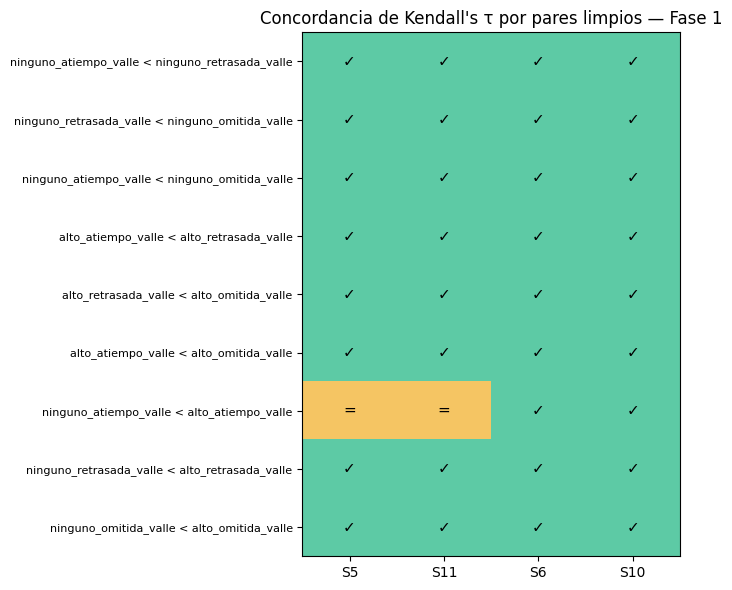

In [54]:
# ======================================================================================================
# VISUALIZACIÓN: CONCORDANCIA DE KENDALL'S τ POR PARES Y SUJETO
# ======================================================================================================
heatmap_concordancia_kendall(dias_sinteticos_fase1, resultados_escenarios_fase1, SUJETOS_TODOS,
                              titulo="Concordancia de Kendall's τ por pares limpios — Fase 1")

In [55]:
# ======================================================================================================
# VERIFICACIÓN: AUC de ninguno_atiempo_valle vs. alto_atiempo_valle (par discordante)
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    aucs = calcular_aucs(dias_sinteticos_fase1, resultados_escenarios_fase1, sujeto)
    print(f"{sujeto}: ninguno_atiempo_valle = {aucs['ninguno_atiempo_valle']:.3f} mg | "
          f"alto_atiempo_valle = {aucs['alto_atiempo_valle']:.3f} mg | "
          f"diferencia = {aucs['alto_atiempo_valle'] - aucs['ninguno_atiempo_valle']:.4f} mg")

S5: ninguno_atiempo_valle = 0.102 mg | alto_atiempo_valle = 0.105 mg | diferencia = 0.0033 mg
S11: ninguno_atiempo_valle = 0.102 mg | alto_atiempo_valle = 0.102 mg | diferencia = 0.0004 mg
S6: ninguno_atiempo_valle = 0.102 mg | alto_atiempo_valle = 0.216 mg | diferencia = 0.1140 mg
S10: ninguno_atiempo_valle = 0.102 mg | alto_atiempo_valle = 0.113 mg | diferencia = 0.0108 mg


**Conclusión — pares limpios concordantes (base del τ de Kendall; tolerancia de 0,01 mg, sin los primeros 25 min del día sintético): 9/9 (100%) en S6 y S10; 8/9 (89%) en S5 y S11.**

En S5 y S11, el único par no concordante es un empate, no una inversión: `ninguno_atiempo_valle < alto_atiempo_valle` difiere en solo 0,0033 mg (S5) y 0,0004 mg (S11), por debajo de la tolerancia. Ocurre porque el pico real de Risk(t) cae a las 07:30, momento en que la contribución del estrés a Demand(t) todavía no ha subido (f(StressLoad) parte de cero) mientras que Coverage(t) ya está subiendo con rapidez (tmax≈1,25h): la diferencia existe, pero es demasiado pequeña frente a la magnitud de Coverage(t) para alterar el AUC en esta ventana. Converge con dos limitaciones ya declaradas: la asimetría de magnitud entre D_ref y la dosis administrada, y el valle previo a la primera toma del timing de esta fase.

El 9/9 de S10 se apoya en una diferencia de 0,0108 mg, solo 0,0008 mg por encima de la tolerancia, y el de S6 (0,114 mg) coincide con su contaminación de fondo (Sección 3.5.2): `f(StressLoad(t))` espurio rompe el empate, no hay detección genuina del *bout*.

El orden parcial por pares (no el ranking total de las 6 combinaciones) es la métrica que se reporta como resultado de monotonía de esta combinación de la Fase 1.

**Diagnóstico: ¿dónde caen los falsos positivos de StressLoad(t) en cada sujeto?**

Necesario para interpretar correctamente por qué S6 y S10 salen con 9/9 (100%) en Kendall's τ — mejor que S5/S11, pese a ser los sujetos con la limitación más grave ya documentada.

In [56]:
# ======================================================================================================
# DIAGNÓSTICO: ¿DÓNDE CAEN LOS FALSOS POSITIVOS DE StressLoad(t) EN CADA SUJETO?
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase1[sujeto]
    ventana_relevante = df_dia['hora_reloj'] < (df_dia['hora_reloj'].dt.normalize().iloc[0] + pd.Timedelta(hours=13))

    falsos_positivos = df_dia[(df_dia['origen'] != 'segmento_real') & (df_dia['stress_pred'] == 1)]
    fp_en_ventana = falsos_positivos[falsos_positivos['hora_reloj'] < (df_dia['hora_reloj'].dt.normalize().iloc[0] + pd.Timedelta(hours=13))]

    print(f"{sujeto}: {len(falsos_positivos)} falsos positivos totales en el fondo | "
          f"{len(fp_en_ventana)} caen dentro de la ventana relevante (07:00-13:00) | "
          f"{len(falsos_positivos) - len(fp_en_ventana)} caen fuera de ella")

S5: 0 falsos positivos totales en el fondo | 0 caen dentro de la ventana relevante (07:00-13:00) | 0 caen fuera de ella
S11: 4 falsos positivos totales en el fondo | 4 caen dentro de la ventana relevante (07:00-13:00) | 0 caen fuera de ella
S6: 186 falsos positivos totales en el fondo | 70 caen dentro de la ventana relevante (07:00-13:00) | 116 caen fuera de ella
S10: 35 falsos positivos totales en el fondo | 20 caen dentro de la ventana relevante (07:00-13:00) | 15 caen fuera de ella


S6 y S10 obtienen 9/9 (100%) frente a 8/9 (89%) de S5 y S11, pese a ser los sujetos con más falsos positivos de StressLoad(t) en su fondo (186 y 35). Investigado antes de aceptar el resultado como una mejora: en S6, 70 de sus 186 falsos positivos caen en la ventana 07:00-13:00 y bastan para que `f(StressLoad(t))` deje de ser exactamente 0 en el tramo problemático, rompiendo el empate por el motivo equivocado; en S10 (20 falsos positivos en esa ventana) la diferencia es de 0,0108 mg, apenas por encima de la tolerancia de 0,01 mg. Un resultado "mejor" producido por un defecto no es una buena noticia y se declara así, no se presenta como el mejor número de la comparación.

Nota adicional: S11 tiene 4 falsos positivos —los 4 dentro de la ventana relevante— que no llegaron a alterar su resultado; su ausencia de efecto es coincidencia de magnitud, no garantía estructural.

### 3.6.2. Ausencia de saltos abruptos — las 6 combinaciones

Comprueba que Risk(t) no dé saltos anómalos fuera de los eventos esperados por diseño (inserción
del *bout* de estrés, absorción de cada dosis). Para cada combinación, calcula el percentil 95 de
`|ΔRisk(t)|` sobre los tramos de fondo (excluyendo el segmento real) y marca como anómalo cualquier
salto que lo supere *y* caiga fuera de esas ventanas esperadas. Es una comprobación de estabilidad
del fondo sintético, no de la magnitud del ruido — detecta sobresaltos puntuales, no un nivel
sostenido de contaminación.

In [57]:
tabla_saltos_f1 = saltos_abruptos_generico(dias_sinteticos_fase1, resultados_escenarios_fase1, SUJETOS_TODOS)


--- S5 ---
  ninguno_atiempo_valle: percentil 95 = 0.020 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.033 | ✅ sin saltos anómalos
  ninguno_omitida_valle: percentil 95 = 0.022 | ✅ sin saltos anómalos
  alto_atiempo_valle: percentil 95 = 0.028 | ✅ sin saltos anómalos
  alto_retrasada_valle: percentil 95 = 0.033 | ✅ sin saltos anómalos
  alto_omitida_valle: percentil 95 = 0.023 | ⚠️ 1 saltos anómalos

--- S11 ---
  ninguno_atiempo_valle: percentil 95 = 0.020 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.033 | ✅ sin saltos anómalos
  ninguno_omitida_valle: percentil 95 = 0.022 | ✅ sin saltos anómalos
  alto_atiempo_valle: percentil 95 = 0.028 | ✅ sin saltos anómalos
  alto_retrasada_valle: percentil 95 = 0.033 | ✅ sin saltos anómalos
  alto_omitida_valle: percentil 95 = 0.023 | ⚠️ 1 saltos anómalos

--- S6 ---
  ninguno_atiempo_valle: percentil 95 = 0.020 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.033 | ✅ sin saltos an

**Conclusión — ausencia de saltos abruptos (excluidos los primeros 25 minutos y las ventanas esperadas por diseño): sin saltos en ninguna combinación sin estrés; con estrés, 1 salto en `alto_omitida_valle` de S5 y de S11, 12 y 5 en `alto_atiempo_valle` y `alto_omitida_valle` de S6, y 9 y 4 en las mismas de S10.**

Todos los saltos anómalos están en combinaciones `alto_*` —las únicas que dependen de f(StressLoad(t))— y sobre todo en S6 y S10, los dos sujetos con falsos positivos de fondo sostenidos. Es compatible con cambios de decisión del clasificador que desplazan f(t) y, con ello, Risk(t); no se ha comprobado minuto a minuto. Como el umbral es el percentil 95 de la derivada del propio fondo de cada serie, el criterio se reporta como recuento y no como condición de superación. Esta métrica detecta saltos puntuales, no el nivel sostenido de contaminación (94,7% en S6).

### 3.6.3. Robustez frente a ruido de sensor — Monte Carlo (100 repeticiones)

Comprueba si el orden de severidad entre combinaciones se mantiene cuando se inyecta ruido gaussiano
(σ=15 bpm, Bowman et al. 2021) sobre `HR_mean_bruto` y se propaga por todo el pipeline (rolling →
normalización → lags → clasificador → f(StressLoad) → Demand(t) → Risk(t)), repitiendo 100 veces con
semillas distintas. En cada repetición, f(StressLoad(t)) se recalcula desde cero con una nueva
realización de ruido — a diferencia de Kendall's τ (3.6.1), que evalúa una única vez sobre el f(t)
ya fijado del día ensamblado (con la contaminación de fondo que tenga cada sujeto de fábrica).

Solo se evalúan los 6 "pares genuinos" (mismo nivel de estrés, distinto patrón de dosis). Los 3
pares que cruzan estrés=ninguno vs. estrés=alto (`PARES_GARANTIZADOS`) quedan fuera del reporte, y
no por el mismo motivo que en Kendall: `demand_ninguno` no depende del ruido en ningún momento (es
`demand_circadian` puro), mientras que `demand_alto` solo puede sumar f(t)·D_ref, con f(t)∈[0,1]
siempre — así que Demand(alto) ≥ Demand(ninguno) se cumple en las 100 repeticiones, con cualquier
semilla, sin excepción posible. No es que el orden sea "improbable de romper"; es que no puede
romperse por construcción del propio generador de ruido. Repetir 100 veces un resultado que no
puede variar no mide robustez, así que se excluye del reporte — a diferencia de Kendall, donde ese
mismo par sí aportó información real (el empate exacto en S5/S11/S10, Sección 3.6.1). Esta sección
tampoco responde si la contaminación de fondo de S6 es estable frente a distintas realizaciones del
bootstrap — esa pregunta ya se respondió en 3.5.3b (barrido multi-semilla).

Umbral de aceptación: ≥85% de las repeticiones deben mantener el orden esperado.

In [58]:
monte_carlo_generico(dias_sinteticos_fase1, resultados_escenarios_fase1, SUJETOS_TODOS, n_repeticiones=100)


--- S5 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_retrasada_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ ninguno_atiempo_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_retrasada_valle: 100/100 (100%)
  ✅ alto_retrasada_valle < alto_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_omitida_valle: 100/100 (100%)

--- S11 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_retrasada_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ ninguno_atiempo_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_retrasada_valle: 100/100 (100%)
  ✅ alto_retrasada_valle < alto_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_omitida_valle: 100/100 (100%)

--- S6 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_

**Conclusión — robustez frente a ruido de sensor: superada en los 6 pares genuinamente puestos a
prueba, en los 4 sujetos (S5, S11, S6, S10).** El orden de severidad entre patrones de dosis dentro
de cada nivel de estrés se mantiene en el 100% de las 100 repeticiones, en los 4 sujetos —muy por
encima del umbral de aceptación (≥85%)— incluido S6 pese a su limitación ya documentada. Es
coherente, no contradictorio: los 6 pares genuinos comparan `retrasada`/`omitida` frente a `atiempo`
dentro del mismo nivel de estrés, una diferencia dominada por la magnitud de Coverage(t) (hasta
2,5 mg/h de rango), muy por encima de lo que el ruido de sensor puede alterar — el 100% aquí refleja
robustez de la señal de dosis, no ausencia de problemas en StressLoad(t).

Los 3 pares excluidos (`ninguno` vs. `alto`) no se han "vuelto a probar y aprobado" en ningún
sentido: quedan fuera precisamente porque, bajo el generador de ruido usado aquí, su orden no puede
invertirse en ninguna repetición (Demand(alto) ≥ Demand(ninguno) por construcción, con o sin ruido).
Esto no equivale a la exclusión que se descartó para Kendall's τ (3.6.1) — ahí el mismo par sí es
informativo, porque evalúa un valor concreto sobre datos reales sin ruido, no su robustez frente a
repeticiones sintéticas. Las dos pruebas responden preguntas distintas sobre el mismo par; que una
lo excluya y la otra no es coherente con esa diferencia, no un criterio inconsistente entre
secciones.

## 3.7 Conclusiones de la Fase 1

**Matriz completa:** 6 de 6 combinaciones (2 niveles de estrés × 3 patrones de dosis, timing=valle)
calculadas para los 4 sujetos reservados (S5, S6, S10, S11).

**Pares limpios concordantes (base del τ de Kendall, Sección 3.6.1):** 8/9 (89%) en S5 y S11, y 9/9 (100%) en S6 y S10. El único par sin concordancia es un empate (Δ AUC de 0,0033 y 0,0004 mg, bajo la tolerancia de 0,01 mg), no una inversión: consecuencia de la convergencia entre la asimetría de magnitud Demand/Coverage y el valle previo a la primera toma del timing de esta fase. El 9/9 de S6 coincide con su contaminación de fondo (Sección 3.5.2) y el de S10 se apoya en una diferencia de 0,0108 mg, apenas por encima de la tolerancia: ninguno se interpreta como detección genuina.

**Ausencia de saltos abruptos (Sección 3.6.2):** sin saltos en las combinaciones sin estrés; con estrés, 1 salto en S5 y 1 en S11 (`alto_omitida`), 12 y 5 en S6 y 9 y 4 en S10 (`alto_atiempo`, `alto_omitida`), compatibles con cambios de decisión del clasificador que desplazan f(t) en los dos sujetos con falsos positivos sostenidos.

**Robustez Monte Carlo (Sección 3.6.3):** 100% en los 6 pares genuinamente puestos a prueba
(mismo estrés, distinto patrón de dosis), en los 4 sujetos — muy por encima del umbral de aceptación
 (≥85%). No cubre el eje estrés=ninguno vs. estrés=alto, excluido porque su orden está
garantizado algebraicamente incluso bajo ruido (Demand(alto)≥Demand(ninguno) en toda repetición,
por construcción); tampoco cubre la estabilidad de la contaminación de fondo de S6 frente a
distintas semillas del bootstrap, ya respondida por separado en 3.5.3b.

**Hallazgo transversal más relevante de la fase (Sección 3.5):** el mecanismo de persistencia de 25
minutos de `f(StressLoad(t))` filtra con eficacia demostrada el ruido disperso del clasificador
(0,0% en S5, 12,0% en S11, fondo puro) y su modo de fallo conocido y acotado es el ruido sostenido
(94,7% en S6, 53,3% en S10) — reformula la limitación de S6/S10 de "el clasificador falla" a "el
sistema tiene un mecanismo de protección con un modo de fallo específico, caracterizado con
precisión y no corregible mediante ajuste del bootstrap (3.5.3/3.5.3b)".

**Decisión de alcance:** se avanza con S5 y S11 como los sujetos de referencia para las
comparaciones entre fases (Capítulos 4 y 5). S6 y S10 se mantienen en el análisis con su
limitación declarada, no se excluyen del todo.

**Cerrado, no pendiente:** el barrido de `longitud_media_bloque` del bootstrap (4-12 min, 10
semillas por configuración, Sección 3.5.3b) no encontró ninguna tendencia distinguible del ruido de
tirada — la contaminación de S6 no depende de cómo el bootstrap recombina los bloques, sino del
contenido limitado del bloque semilla (~19-20 min reales de Relajado). No se adopta ningún cambio
en este parámetro; cualquier mejora real requeriría más minutos reales de Relajado por sujeto, no
disponibles en WESAD.

# 4. Fase 2: timing justo tras la toma

Segunda de las tres fases de la matriz de escenarios: el *bout* de estrés se inserta a las 14:15,
justo tras la toma de las 13:00 (tmax≈1,25h de margen de absorción), con Coverage(t) ya subiendo,
lejos del valle previo a la primera toma de la Fase 1. Reutiliza íntegramente la infraestructura del
Capítulo 2 (`ensamblar_dia_sintetico`) y las funciones genéricas de métricas ya definidas en 3.4
(Kendall's τ, saltos abruptos, Monte Carlo), parametrizadas por diccionario de resultados — aquí
solo cambia el diccionario que reciben (`dias_sinteticos_fase2`, específico de esta fase, para no
mezclar ni sobrescribir los resultados de la Fase 1).

## 4.1 Definición del timing de la Fase 2, y ensamblaje de los días sintéticos


In [59]:
# ======================================================================================================
# 4.1. TIMING DE LA FASE 2 Y ENSAMBLAJE DE LOS DÍAS SINTÉTICOS
# ======================================================================================================
MINUTO_INSERCION_FASE2 = 435  # 14:15 = 07:00 + 435 min (tmax de la toma de las 13:00)

dias_sinteticos_fase2 = {}
for sujeto in RESERVED_SUBJECTS:
    df_dia, n_recortes = ensamblar_dia_sintetico(sujeto, minuto_insercion=MINUTO_INSERCION_FASE2)
    dias_sinteticos_fase2[sujeto] = df_dia
    minuto_bout_real = df_dia[df_dia['origen'] == 'segmento_real']['hora_reloj'].iloc[0]
    print(f"{sujeto}: día ensamblado (Fase 2) | {n_recortes} recorte(s) de cola | "
      f"bout real inicia a las {minuto_bout_real.strftime('%H:%M')}")


S5: día ensamblado (Fase 2) | 0 recorte(s) de cola | bout real inicia a las 14:15
S6: día ensamblado (Fase 2) | 0 recorte(s) de cola | bout real inicia a las 14:15
S10: día ensamblado (Fase 2) | 0 recorte(s) de cola | bout real inicia a las 14:15
S11: día ensamblado (Fase 2) | 1 recorte(s) de cola | bout real inicia a las 14:15


Ensamblaje verificado en los 4 sujetos: *bout* real insertado a las 14:15 en los 4 casos. El único
recorte de cola (1 minuto, en S11) coincide exactamente con el ya caracterizado en 2.2.3 para la
costura de salida — es el mismo minuto anómalo de recuperación, no depende del timing de inserción,
así que reaparece aquí sin sorpresas.

### 4.1.1. Visualización del día sintético ensamblado

Mismo enfoque que 3.1.5.

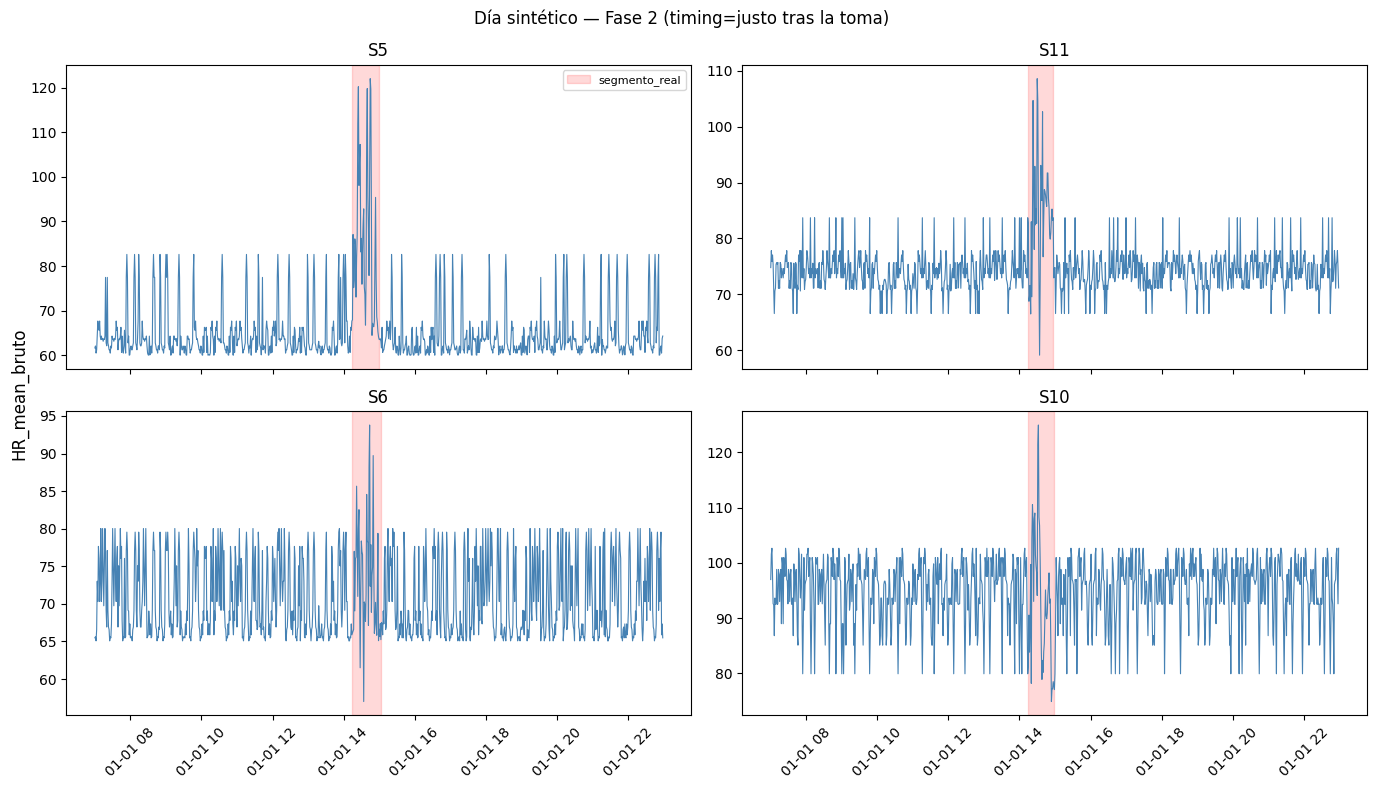

In [60]:
graficar_dia_sintetico(dias_sinteticos_fase2, SUJETOS_TODOS, titulo='Día sintético — Fase 2 (timing=justo tras la toma)')

El *bout* real (franja roja, 14:15) se distingue como el pico más alto del día en los 4 sujetos,
igual que en la Fase 1. El aspecto del fondo por sujeto es el mismo que en 3.1.5 (S5/S11 con picos
dispersos, S6 con oscilación densa y sostenida, S10 con rango más amplio y elevado) — coherente con
que la contaminación depende del sujeto y la semilla, no del timing del *bout* (Sección 4.5). El
contenido concreto del fondo antes del *bout* no es idéntico al de la Fase 1 minuto a minuto,
 pero el patrón cualitativo por sujeto sí se mantiene.

## 4.2. Demand(t), Coverage(t) y Risk(t) — primera combinación

Misma estructura que 3.2 (Fase 1): Demand(t) = Demand_circadian(t) + D_ref·f(StressLoad(t)),
Coverage(t) con la pauta estándar, Risk(t) = Demand(t) − Coverage(t). Aquí el *bout* real cae a las
14:15, ya con Coverage(t) en ascenso tras la toma de las 13:00, no en el valle de la Fase 1.

In [61]:
# ======================================================================================================
# DEMAND(t) — FASE 2
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase2[sujeto]
    horas_del_dia = (df_dia['hora_reloj'] - df_dia['hora_reloj'].dt.normalize()) / pd.Timedelta(hours=1)
    df_dia['demand_circadian'] = demand_circadian(horas_del_dia.values)
    df_dia['f_stressload'] = df_dia['stress_pred'].rolling(window=VENTANA_F_STRESSLOAD_MIN, min_periods=1).mean()
    df_dia['demand_t'] = df_dia['demand_circadian'] + D_REF_MID * df_dia['f_stressload']

    print(f"{sujeto}: Demand_circadian(t) en [{df_dia['demand_circadian'].min():.3f}, {df_dia['demand_circadian'].max():.3f}] mg/h | "
          f"f(StressLoad) máximo = {df_dia['f_stressload'].max():.3f} | "
          f"Demand(t) en [{df_dia['demand_t'].min():.3f}, {df_dia['demand_t'].max():.3f}] mg/h")


S5: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 1.000 | Demand(t) en [0.103, 1.075] mg/h
S11: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 1.000 | Demand(t) en [0.103, 1.074] mg/h
S6: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 0.760 | Demand(t) en [0.116, 1.030] mg/h
S10: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 0.600 | Demand(t) en [0.103, 0.853] mg/h


In [62]:
# ======================================================================================================
# COVERAGE(t) Y RISK(t) — PRIMERA COMBINACIÓN, FASE 2
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase2[sujeto]
    fecha_dia_sintetico = df_dia['hora_reloj'].dt.normalize().iloc[0]

    schedule_dia = build_standard_schedule(fecha_dia_sintetico - pd.Timedelta(days=1), n_days=2)
    df_dia['coverage_t'] = compute_coverage(schedule_dia, df_dia['hora_reloj'], pk).values
    df_dia['risk_t'] = df_dia['demand_t'] - df_dia['coverage_t']

    print(f"{sujeto}: Coverage(t) en [{df_dia['coverage_t'].min():.3f}, {df_dia['coverage_t'].max():.3f}] mg/h "
          f"| Risk(t) en [{df_dia['risk_t'].min():.3f}, {df_dia['risk_t'].max():.3f}] mg/h")


S5: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.739, 0.682] mg/h
S11: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.739, 0.682] mg/h
S6: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.725, 0.961] mg/h
S10: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.739, 0.771] mg/h


f(StressLoad(t)) máximo reproduce exactamente los valores de la Fase 1 en los 4 sujetos (1,000 en
S5/S11, 0,760 en S6, 0,600 en S10) — confirma que el techo alcanzado durante el *bout* depende solo
del clasificador sobre esos datos reales, no del momento del día en que se inserte.

Demand(t) máximo es menor que en la Fase 1 en los 4 sujetos (p. ej. S5: 1,075 frente a 1,283): con
el *bout* a las 14:15, lejos del pico circadiano (que ocurre cerca del amanecer), no hay
solapamiento entre el pico de estrés y el pico circadiano como sí ocurría en la Fase 1.

Coverage(t) vuelve a ser idéntico en los 4 sujetos ([0,010, 2,455] mg/h) — mismo motivo que en 3.2.2
(depende solo del `schedule`, no del sujeto).

Risk(t) máximo coincide en S5 y S11 (0,682) pero no en S6 (0,961) ni en S10 (0,771), a diferencia de
la Fase 1, donde S5/S11/S10 coincidían y solo S6 se separaba. No se puede afirmar todavía si el pico
de S6 aquí cae dentro del segmento real o en el fondo (como en 3.2.3) sin repetir el mismo
diagnóstico de `origen`.

Se verifica a continuación si este patrón —Risk(t) máximo distinto entre sujetos— tiene el mismo
origen que en la Fase 1, localizando el instante exacto del pico y su `origen`.

### 4.2.1. Diagnóstico: origen del pico de Risk(t)

Mismo enfoque que 3.2.3: localiza el instante exacto del máximo y del mínimo de Risk(t) en cada
sujeto, y su columna `origen`, para comprobar si el pico realmente corresponde al *bout* de estrés
insertado a las 14:15 o a otro tramo del día.

In [63]:
# ======================================================================================================
# DIAGNÓSTICO: ORIGEN DEL PICO DE RISK(t) — FASE 2 (mismo enfoque que 3.2.3)
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase2[sujeto]

    minuto_pico_risk = df_dia.loc[df_dia['risk_t'].idxmax()]
    minuto_valle_risk = df_dia.loc[df_dia['risk_t'].idxmin()]

    print(f"\n--- {sujeto} ---")
    print(f"Pico de Risk(t): {minuto_pico_risk['hora_reloj'].strftime('%H:%M')} "
          f"(Demand={minuto_pico_risk['demand_t']:.3f}, Coverage={minuto_pico_risk['coverage_t']:.3f}, "
          f"origen={minuto_pico_risk['origen']})")
    print(f"Valle de Risk(t): {minuto_valle_risk['hora_reloj'].strftime('%H:%M')} "
          f"(origen={minuto_valle_risk['origen']})")
    print(f"% del día con Risk(t) > 0 (infra-cobertura): {100*(df_dia['risk_t'] > 0).mean():.1f}%")


--- S5 ---
Pico de Risk(t): 07:30 (Demand=0.692, Coverage=0.010, origen=fondo_antes)
Valle de Risk(t): 08:45 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 4.1%

--- S11 ---
Pico de Risk(t): 07:30 (Demand=0.692, Coverage=0.010, origen=fondo_antes)
Valle de Risk(t): 08:45 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 4.1%

--- S6 ---
Pico de Risk(t): 07:23 (Demand=0.972, Coverage=0.010, origen=fondo_antes)
Valle de Risk(t): 08:54 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 9.3%

--- S10 ---
Pico de Risk(t): 07:04 (Demand=0.782, Coverage=0.012, origen=fondo_antes)
Valle de Risk(t): 08:45 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 4.2%


Los valores concretos del pico difieren entre la Fase 2 y la Fase 3 (aunque el mecanismo — valle previo a la primera toma
 en `fondo_antes` — sea el mismo) porque `bootstrap_con_final_forzado` ancla la
secuencia generada cerca de la costura con el *bout*, no cerca de las 07:00: el tramo de madrugada
es la parte "sobrante" del bootstrap, que depende de cuánto fondo total haga falta generar en cada
fase (`n_fondo_antes = minuto_insercion`, distinto en cada una), aunque la semilla sea idéntica.

## 4.3. Matriz completa: reestructuración, variantes de dosis, y visualización (Fase 2)

En la Fase 1 este paso se dividió en varias secciones (3.3.1-3.3.3) porque era la primera vez que
se construía la matriz completa. Aquí, con la lógica ya establecida y verificada, se registran las
6 combinaciones en un único paso: la primera combinación (`alto_atiempo_valle` /
`ninguno_atiempo_valle`, ya calculada en 4.2) más las 4 variantes de dosis (`retrasada`/`omitida`
cruzadas con estrés), reutilizando `aplicar_variante_dosis()` y `build_standard_schedule()` sin
cambios respecto al Capítulo 3.

In [64]:
# ======================================================================================================
# 4.4. MATRIZ COMPLETA DE LA FASE 2 — 6 COMBINACIONES
# ======================================================================================================
resultados_escenarios_fase2 = {sujeto: {} for sujeto in SUJETOS_TODOS}

for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase2[sujeto]
    fecha_dia_sintetico = df_dia['hora_reloj'].dt.normalize().iloc[0]
    demand_sin_estres = df_dia['demand_circadian'].values

    resultados_escenarios_fase2[sujeto]['alto_atiempo_valle'] = {
        'demand': df_dia['demand_t'].values, 'coverage': df_dia['coverage_t'].values, 'risk': df_dia['risk_t'].values,
    }
    resultados_escenarios_fase2[sujeto]['ninguno_atiempo_valle'] = {
        'demand': demand_sin_estres, 'coverage': df_dia['coverage_t'].values,
        'risk': demand_sin_estres - df_dia['coverage_t'].values,
    }

    schedule_base = build_standard_schedule(fecha_dia_sintetico - pd.Timedelta(days=1), n_days=2)
    for tipo, nombre_alto, nombre_ninguno in [
        ('retrasada', 'alto_retrasada_valle', 'ninguno_retrasada_valle'),
        ('omitida', 'alto_omitida_valle', 'ninguno_omitida_valle'),
    ]:
        schedule_variante = aplicar_variante_dosis(schedule_base, fecha_dia_sintetico, '13:00', tipo, RETRASO_HORAS)
        coverage_variante = compute_coverage(schedule_variante, df_dia['hora_reloj'], pk).values

        resultados_escenarios_fase2[sujeto][nombre_alto] = {
            'demand': df_dia['demand_t'].values, 'coverage': coverage_variante,
            'risk': df_dia['demand_t'].values - coverage_variante,
        }
        resultados_escenarios_fase2[sujeto][nombre_ninguno] = {
            'demand': demand_sin_estres, 'coverage': coverage_variante,
            'risk': demand_sin_estres - coverage_variante,
        }

    print(f"{sujeto}: {len(resultados_escenarios_fase2[sujeto])} combinaciones registradas (Fase 2)")


S5: 6 combinaciones registradas (Fase 2)
S11: 6 combinaciones registradas (Fase 2)
S6: 6 combinaciones registradas (Fase 2)
S10: 6 combinaciones registradas (Fase 2)


Las 6 combinaciones quedan registradas en `resultados_escenarios_fase2`, en los 4 sujetos, sin
incidencias.

### 4.3.1. Comparación gráfica de las 6 combinaciones — 4 sujetos

Mismo formato que 3.3.4: tres figuras (una por patrón de dosis), cada una en grid 2×2 por sujeto,
comparando `alto` vs. `ninguno` con el resto de parámetros fijos. La franja roja marca aquí el
*bout* real a las 14:15, no las 07:30 de la Fase 1 — el resto de la lógica no cambia.

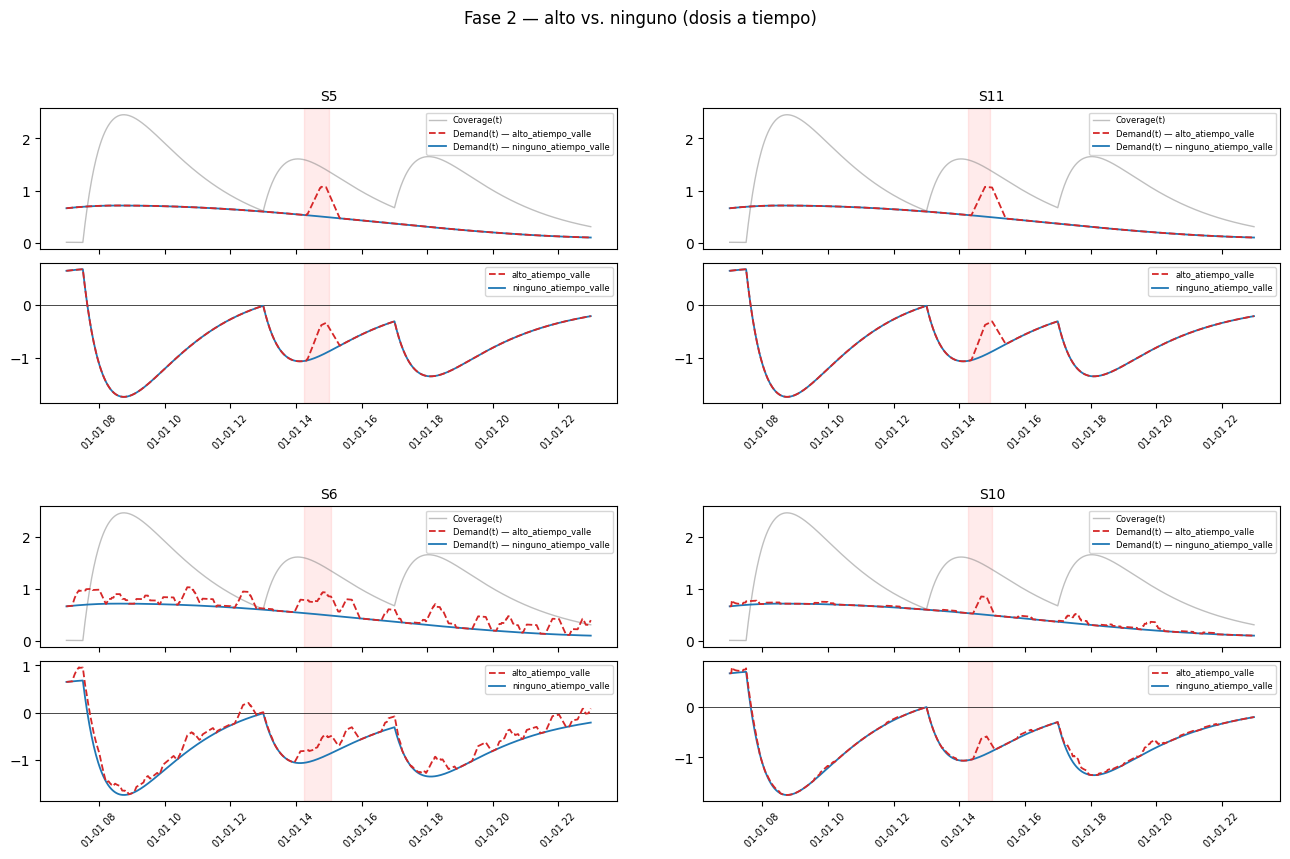

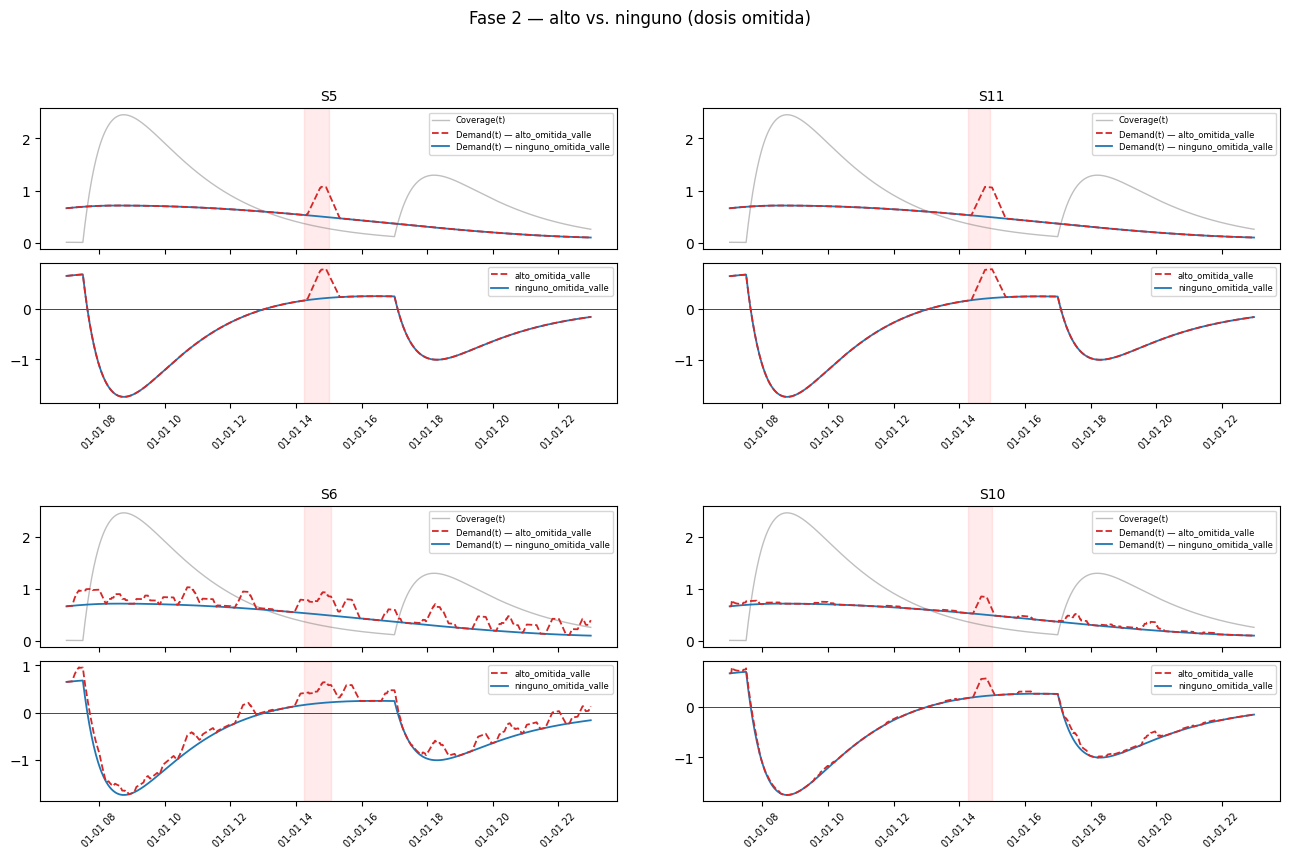

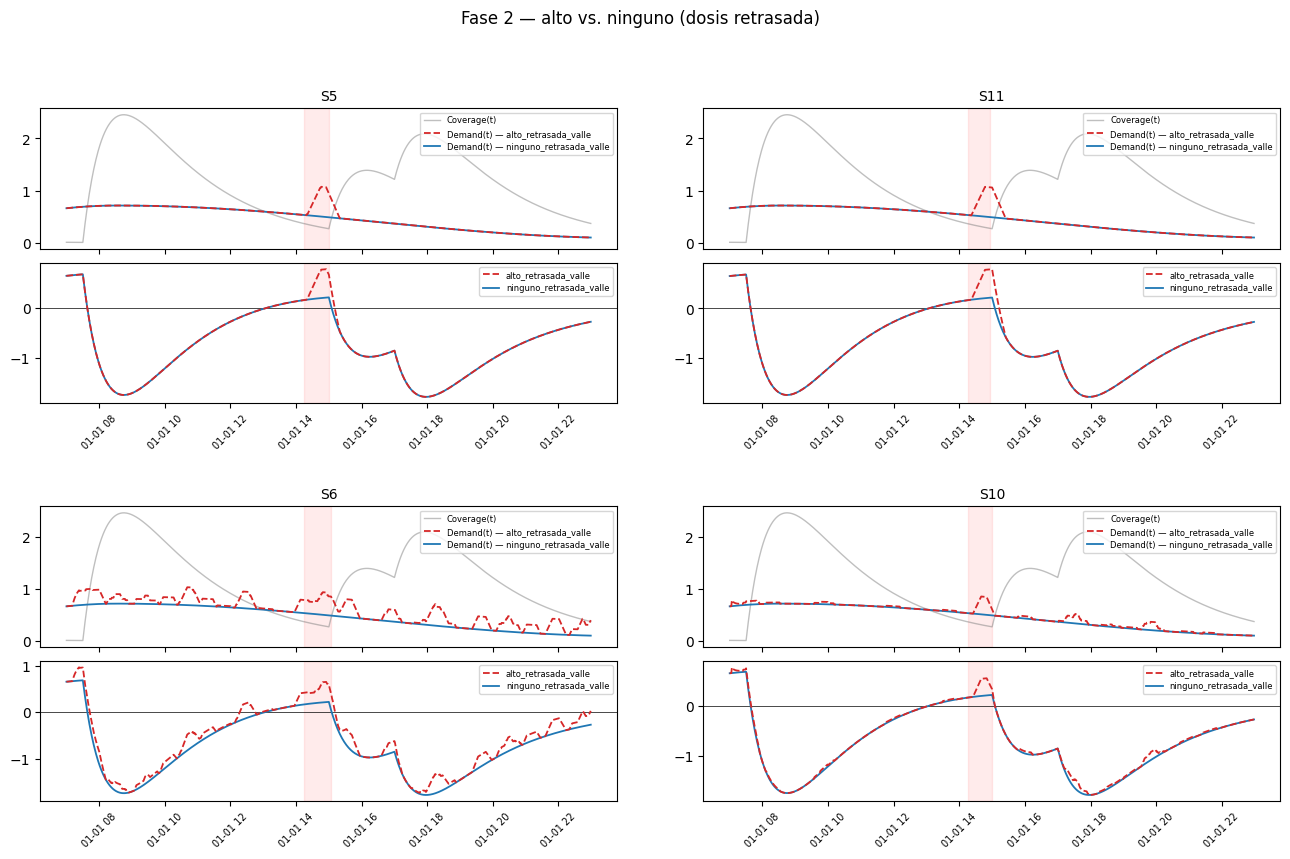

In [65]:
# A tiempo
graficar_comparacion_grid(dias_sinteticos_fase2, resultados_escenarios_fase2,
                           ['alto_atiempo_valle', 'ninguno_atiempo_valle'],
                           estilos={'alto_atiempo_valle': '--'},
                           titulo='Fase 2 — alto vs. ninguno (dosis a tiempo)')

# Omitida
graficar_comparacion_grid(dias_sinteticos_fase2, resultados_escenarios_fase2,
                           ['alto_omitida_valle', 'ninguno_omitida_valle'],
                           estilos={'alto_omitida_valle': '--'},
                           titulo='Fase 2 — alto vs. ninguno (dosis omitida)')

# Retrasada
graficar_comparacion_grid(dias_sinteticos_fase2, resultados_escenarios_fase2,
                           ['alto_retrasada_valle', 'ninguno_retrasada_valle'],
                           estilos={'alto_retrasada_valle': '--'},
                           titulo='Fase 2 — alto vs. ninguno (dosis retrasada)')

## 4.4. Funciones genéricas de métricas

Ya definidas en 3.4 y reutilizadas aquí sin cambios (parametrizadas por diccionario de resultados,
válidas para cualquier fase). No se repiten en este capítulo.

## 4.5 Verificación del mecanismo de persistencia de f(·) (Fase 2)

Misma comprobación que en 3.5.2: máximo de `f_stressload` en fondo puro (excluyendo los 25 minutos
siguientes al fin del segmento real, y su equivalente antes del inicio) frente al máximo durante el
*bout* real. No se repite aquí ni la versión con artefacto de frontera (3.5.1, ya diagnosticado y
superado) ni el barrido de `longitud_media_bloque` (3.5.3/3.5.3b): ambas son preguntas sobre el
propio fondo generado por bootstrap, independientes del timing del *bout*, y ya quedaron cerradas de forma
general en el Capítulo 3.

In [66]:
# ======================================================================================================
# FONDO PURO vs. BOUT REAL — FASE 2
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase2[sujeto]
    idx_fin_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[-1]
    idx_inicio_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[0]
    mask_fondo_puro = ((df_dia['origen'] != 'segmento_real') & (df_dia.index > idx_fin_segmento_real + VENTANA_F_STRESSLOAD_MIN))
    mask_fondo_puro = mask_fondo_puro | ((df_dia['origen'] != 'segmento_real') & (df_dia.index < idx_inicio_segmento_real))

    f_max_fondo_puro = df_dia.loc[mask_fondo_puro, 'f_stressload'].max()
    f_max_real = df_dia.loc[df_dia['origen'] == 'segmento_real', 'f_stressload'].max()
    ratio = 100 * f_max_fondo_puro / f_max_real if f_max_real > 0 else float('nan')

    print(f"{sujeto}: f_stressload máx. en fondo puro = {f_max_fondo_puro:.3f} | "
          f"máx. durante el bout real = {f_max_real:.3f} | ratio = {ratio:.1f}%")


S5: f_stressload máx. en fondo puro = 0.000 | máx. durante el bout real = 1.000 | ratio = 0.0%
S11: f_stressload máx. en fondo puro = 0.120 | máx. durante el bout real = 1.000 | ratio = 12.0%
S6: f_stressload máx. en fondo puro = 0.720 | máx. durante el bout real = 0.760 | ratio = 94.7%
S10: f_stressload máx. en fondo puro = 0.320 | máx. durante el bout real = 0.600 | ratio = 53.3%


Los ratios de contaminación son idénticos a los de la Fase 1, en los 4 sujetos: 0,0% (S5), 12,0%
(S11), 94,7% (S6), 53,3% (S10). Confirma que la contaminación depende únicamente de las semillas del
bootstrap (`seed_fondo_antes=100`, `seed_fondo_despues=200`, fijas en `ensamblar_dia_sintetico`), no
del punto del día donde se inserte el *bout* — el mecanismo de persistencia se comporta igual en las
dos fases porque el fondo generado por bootstrap es de la misma naturaleza, aunque su contenido concreto no sea idéntico (4.1.1).

## 4.6. Métricas de aceptación

### 4.6.1. Kendall's τ por pares limpios (Fase 2)

Misma metodología que 3.6.1 (orden parcial sobre 9 de los 15 pares posibles, AUC de Risk(t)>0 como
métrica de severidad) — la premisa que descartó el ranking total en la Fase 1 no depende del timing,
así que no se reevalúa aquí. La ventana de AUC se ajusta a esta fase: 13:00-17:00, en vez de
07:00-13:00, para cubrir el *bout* real (14:15) y la dosis manipulada (13:00).

In [67]:
kendall_por_pares_generico(dias_sinteticos_fase2, resultados_escenarios_fase2, SUJETOS_TODOS,
                            hora_inicio_ventana="13:00", hora_fin_ventana="17:00")

S5: 8/9 pares limpios concordantes (89%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle')]
S11: 8/9 pares limpios concordantes (89%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle')]
S6: 8/9 pares limpios concordantes (89%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle')]
S10: 8/9 pares limpios concordantes (89%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle')]


In [68]:
# ======================================================================================================
# VERIFICACIÓN: AUC de las 6 combinaciones — Fase 2 (ventana 13:00-17:00)
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    aucs = calcular_aucs(dias_sinteticos_fase2, resultados_escenarios_fase2, sujeto,
                          hora_inicio_ventana="13:00", hora_fin_ventana="17:00")
    print(f"--- {sujeto} ---")
    for nombre, valor in aucs.items():
        print(f"  {nombre}: {valor:.4f} mg")

--- S5 ---
  ninguno_atiempo_valle: 0.0000 mg
  ninguno_retrasada_valle: 0.2669 mg
  ninguno_omitida_valle: 0.7419 mg
  alto_atiempo_valle: 0.0000 mg
  alto_retrasada_valle: 0.5733 mg
  alto_omitida_valle: 1.0744 mg
--- S11 ---
  ninguno_atiempo_valle: 0.0000 mg
  ninguno_retrasada_valle: 0.2669 mg
  ninguno_omitida_valle: 0.7419 mg
  alto_atiempo_valle: 0.0000 mg
  alto_retrasada_valle: 0.5816 mg
  alto_omitida_valle: 1.1029 mg
--- S6 ---
  ninguno_atiempo_valle: 0.0000 mg
  ninguno_retrasada_valle: 0.2669 mg
  ninguno_omitida_valle: 0.7419 mg
  alto_atiempo_valle: 0.0001 mg
  alto_retrasada_valle: 0.6038 mg
  alto_omitida_valle: 1.3167 mg
--- S10 ---
  ninguno_atiempo_valle: 0.0000 mg
  ninguno_retrasada_valle: 0.2669 mg
  ninguno_omitida_valle: 0.7419 mg
  alto_atiempo_valle: 0.0000 mg
  alto_retrasada_valle: 0.4189 mg
  alto_omitida_valle: 0.9129 mg


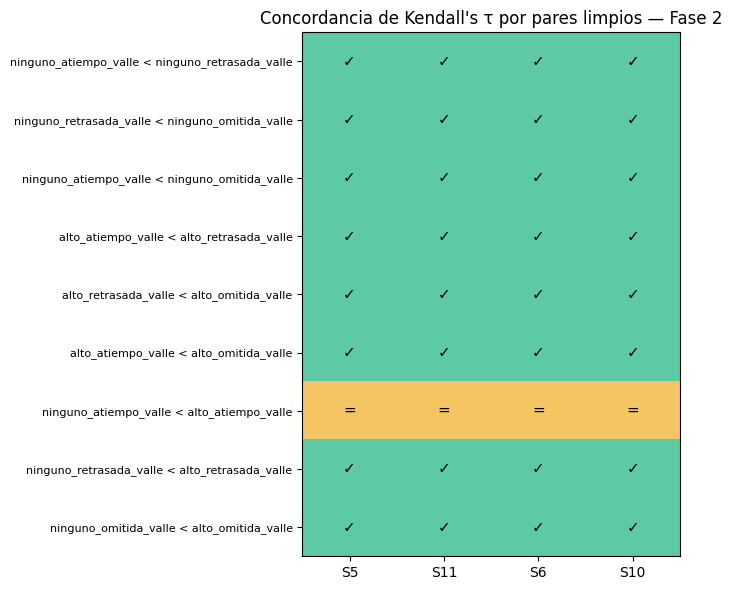

In [69]:
# ======================================================================================================
# VISUALIZACIÓN: CONCORDANCIA DE KENDALL'S τ POR PARES Y SUJETO — FASE 2
# ======================================================================================================
heatmap_concordancia_kendall(dias_sinteticos_fase2, resultados_escenarios_fase2, SUJETOS_TODOS,
                              hora_inicio_ventana="13:00", hora_fin_ventana="17:00",
                              titulo="Concordancia de Kendall's τ por pares limpios — Fase 2")

**Conclusión — pares limpios concordantes: 8/9 (89%) en los 4 sujetos, mismo patrón en todos.**

El par no concordante es el mismo en los 4: `ninguno_atiempo_valle < alto_atiempo_valle` es un empate (Δ AUC ≤ 0,0001 mg), no una inversión. Con la dosis a tiempo, Coverage(t) ya cubre Demand(t) durante todo el *bout*, incluso con estrés, así que el estrés no genera infra-cobertura medible en esta ventana (13:00-17:00). El resto de pares son concordantes: `omitida` es la pauta que más infra-cobertura produce (0,7419 mg sin estrés), seguida de `retrasada` (0,2669 mg), y el estrés la incrementa (`alto_retrasada`: 0,419-0,604 mg; `alto_omitida`: 0,913-1,317 mg). El heatmap confirma que el patrón es idéntico en los 4 sujetos, incluidos S6 y S10: el empate no está relacionado con la contaminación de fondo de esos sujetos, es un rasgo del diseño de esta fase.

### 4.6.2 Ausencia de saltos abruptos (Fase 2)

In [70]:
saltos_abruptos_generico(dias_sinteticos_fase2, resultados_escenarios_fase2, SUJETOS_TODOS, HORAS_DOSIS_POR_COMBINACION_13H)


--- S5 ---
  ninguno_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.035 | ✅ sin saltos anómalos
  ninguno_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos
  alto_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  alto_retrasada_valle: percentil 95 = 0.042 | ✅ sin saltos anómalos
  alto_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos

--- S11 ---
  ninguno_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.035 | ✅ sin saltos anómalos
  ninguno_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos
  alto_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  alto_retrasada_valle: percentil 95 = 0.045 | ✅ sin saltos anómalos
  alto_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos

--- S6 ---
  ninguno_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.033 | ✅ sin saltos 

Con la exclusión de los primeros 25 minutos del día sintético, el salto de S10 a las 07:04 —que se localiza a continuación— deja de contarse. Se mantiene el diagnóstico para documentar su origen.

In [71]:
# ======================================================================================================
# DIAGNÓSTICO: LOCALIZACIÓN DEL SALTO ANÓMALO — S10, FASE 2
# ======================================================================================================
sujeto = 'S10'
df_dia = dias_sinteticos_fase2[sujeto]
mask_fondo = df_dia['origen'] != 'segmento_real'

for nombre in ['alto_atiempo_valle', 'alto_retrasada_valle', 'alto_omitida_valle']:
    risk = np.asarray(resultados_escenarios_fase2[sujeto][nombre]['risk'])
    derivada = np.diff(risk)
    derivada_fondo = derivada[mask_fondo.values[1:]]
    percentil_95 = np.percentile(np.abs(derivada_fondo), 95)
    horas = df_dia['hora_reloj'].iloc[1:].reset_index(drop=True)

    ventanas = construir_ventanas_esperadas_generico(df_dia, nombre, HORAS_DOSIS_POR_COMBINACION_13H)
    saltos_anomalos = [
        (horas.iloc[i], d, df_dia['origen'].iloc[i+1]) for i, d in enumerate(derivada)
        if abs(d) > percentil_95 and not dentro_de_alguna_ventana(horas.iloc[i], ventanas)
    ]
    print(f"{nombre}: percentil 95 = {percentil_95:.3f}")
    for hora, delta, origen in saltos_anomalos:
        print(f"  Salto en {hora.strftime('%H:%M')} | Δ={delta:.3f} | origen={origen}")

alto_atiempo_valle: percentil 95 = 0.034
  Salto en 07:04 | Δ=0.115 | origen=fondo_antes
alto_retrasada_valle: percentil 95 = 0.035
  Salto en 07:04 | Δ=0.115 | origen=fondo_antes
alto_omitida_valle: percentil 95 = 0.034
  Salto en 07:04 | Δ=0.115 | origen=fondo_antes


**Conclusión — ausencia de saltos abruptos: superada en las 24 combinaciones×sujeto.** El salto de S10 a las 07:04 (`fondo_antes`, el mismo tramo del pico de Risk(t) de 4.2.1) cae dentro de los primeros 25 minutos del día sintético, cuyas ventanas de rolling y de persistencia están incompletas, y no se cuenta. Es la contaminación de fondo de S10 (53,3%, Sección 4.5) manifestándose en el arranque del día, no un hallazgo sobre el sistema.

### 4.6.3. Robustez frente a ruido de sensor — Monte Carlo (Fase 2, 100 repeticiones)

Misma metodología que 3.6.3: 100 repeticiones con ruido gaussiano (σ=15 bpm) inyectado en
`HR_mean_bruto`, propagado por todo el pipeline, evaluando los 6 pares genuinos (mismo estrés,
distinto patrón de dosis) en la ventana de esta fase (13:00-17:00). Los 3 pares que cruzan
estrés=ninguno vs. estrés=alto quedan fuera del reporte por el mismo motivo que en la Fase 1: su
orden está garantizado algebraicamente incluso bajo ruido, así que no aporta información sobre
robustez.

In [72]:
monte_carlo_generico(dias_sinteticos_fase2, resultados_escenarios_fase2, SUJETOS_TODOS,
                      n_repeticiones=100, hora_inicio_ventana="13:00", hora_fin_ventana="17:00")


--- S5 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_retrasada_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ ninguno_atiempo_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_retrasada_valle: 100/100 (100%)
  ✅ alto_retrasada_valle < alto_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_omitida_valle: 100/100 (100%)

--- S11 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_retrasada_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ ninguno_atiempo_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_retrasada_valle: 100/100 (100%)
  ✅ alto_retrasada_valle < alto_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_omitida_valle: 100/100 (100%)

--- S6 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_

**Conclusión — los 6 pares genuinos al 100% en los 4 sujetos.** El orden de severidad entre patrones de dosis dentro de cada nivel de estrés se mantiene en las 100 repeticiones. Como en la Fase 1, el 100% refleja la robustez de la señal de dosis frente al ruido de HR, no la del clasificador.

## 4.7 Conclusiones de la Fase 2

**Matriz completa:** 6 de 6 combinaciones (2 niveles de estrés × 3 patrones de dosis, timing=justo
tras la toma de las 13:00) calculadas para los 4 sujetos reservados (S5, S6, S10, S11).

**Pares limpios concordantes (Sección 4.6.1):** 8/9 (89%) en los 4 sujetos, mismo patrón en todos. El par sin concordancia es un empate (Δ AUC ≤ 0,0001 mg): con la dosis a tiempo, Coverage(t) ya cubre Demand(t) durante todo el *bout* y el estrés no genera infra-cobertura medible.

**Ausencia de saltos abruptos (Sección 4.6.2):** superada en las 24 combinaciones×sujeto; el salto de S10 a las 07:04 cae en los primeros 25 minutos del día sintético y no se cuenta.

**Robustez Monte Carlo (Sección 4.6.3):** 6 de 6 pares genuinos al 100% en los 4 sujetos.

**Mecanismo de persistencia de f(·) (Sección 4.5):** idéntico a la Fase 1 en los 4 sujetos — 0,0%
(S5), 12,0% (S11), 94,7% (S6), 53,3% (S10). Confirma que la contaminación depende de las semillas
del bootstrap, no del timing del *bout*.

**Comparación con la Fase 1:** el pico de Risk(t) de la "primera combinación" (4.2) no es comparable entre fases sin matizar: en la Fase 2 está dominado por el valle previo a la primera toma (Sección 4.2.1), no por el *bout* de las 14:15. La comparación válida es el AUC en la ventana relevante de cada fase: sin estrés, omitida > retrasada > a tiempo en las tres fases (en la Fase 2, 0,7419 > 0,2669 > 0,0000 mg); lo que cambia con el timing es cuánto añade el estrés a esa infra-cobertura.

# 5: Fase 3: timing a mitad del intervalo

Tercera fase: el *bout* de estrés se inserta en el punto medio del intervalo entre la toma de las
13:00 y la siguiente (17:00) — un momento de cobertura intermedia, ni el valle (Fase 1) ni el pico
de absorción reciente (Fase 2). Reutiliza `ensamblar_dia_sintetico()` (Capítulo 2) y las funciones
genéricas de métricas ya definidas en 3.4.

## 5.1 Definición del timing de la Fase 3, y ensamblaje de los días sintéticos

Igual que en la Fase 2, el timing está fijado por diseño, sin necesidad de buscar entre candidatos
(Sección 3.1): el *bout* se ancla al punto medio del intervalo 13:00-17:00 (15:00), a mitad de
camino entre el pico de absorción reciente de la Fase 2 y el próximo valle de cobertura.

In [73]:
# ======================================================================================================
# 5.1. TIMING DE LA FASE 3 Y ENSAMBLAJE DE LOS DÍAS SINTÉTICOS
# ======================================================================================================
MINUTO_INSERCION_FASE3 = 480  # 15:00 = 07:00 + 480 min (mitad del intervalo 13:00-17:00)

dias_sinteticos_fase3 = {}
for sujeto in RESERVED_SUBJECTS:
    df_dia, n_recortes = ensamblar_dia_sintetico(sujeto, minuto_insercion=MINUTO_INSERCION_FASE3)
    dias_sinteticos_fase3[sujeto] = df_dia
    minuto_bout_real = df_dia[df_dia['origen'] == 'segmento_real']['hora_reloj'].iloc[0]
    print(f"{sujeto}: día ensamblado (Fase 3) | {n_recortes} recorte(s) de cola | "
      f"bout real inicia a las {minuto_bout_real.strftime('%H:%M')}")


S5: día ensamblado (Fase 3) | 0 recorte(s) de cola | bout real inicia a las 15:00
S6: día ensamblado (Fase 3) | 0 recorte(s) de cola | bout real inicia a las 15:00
S10: día ensamblado (Fase 3) | 0 recorte(s) de cola | bout real inicia a las 15:00
S11: día ensamblado (Fase 3) | 1 recorte(s) de cola | bout real inicia a las 15:00


Ensamblaje verificado en los 4 sujetos: *bout* real insertado a las 15:00 en los 4 casos. El único
recorte de cola (1 minuto, en S11) vuelve a coincidir con el ya caracterizado en 2.2.3 — no depende
del timing de inserción.

### 5.1.1. Visualización del día sintético ensamblado

Mismo enfoque que 3.1.5.

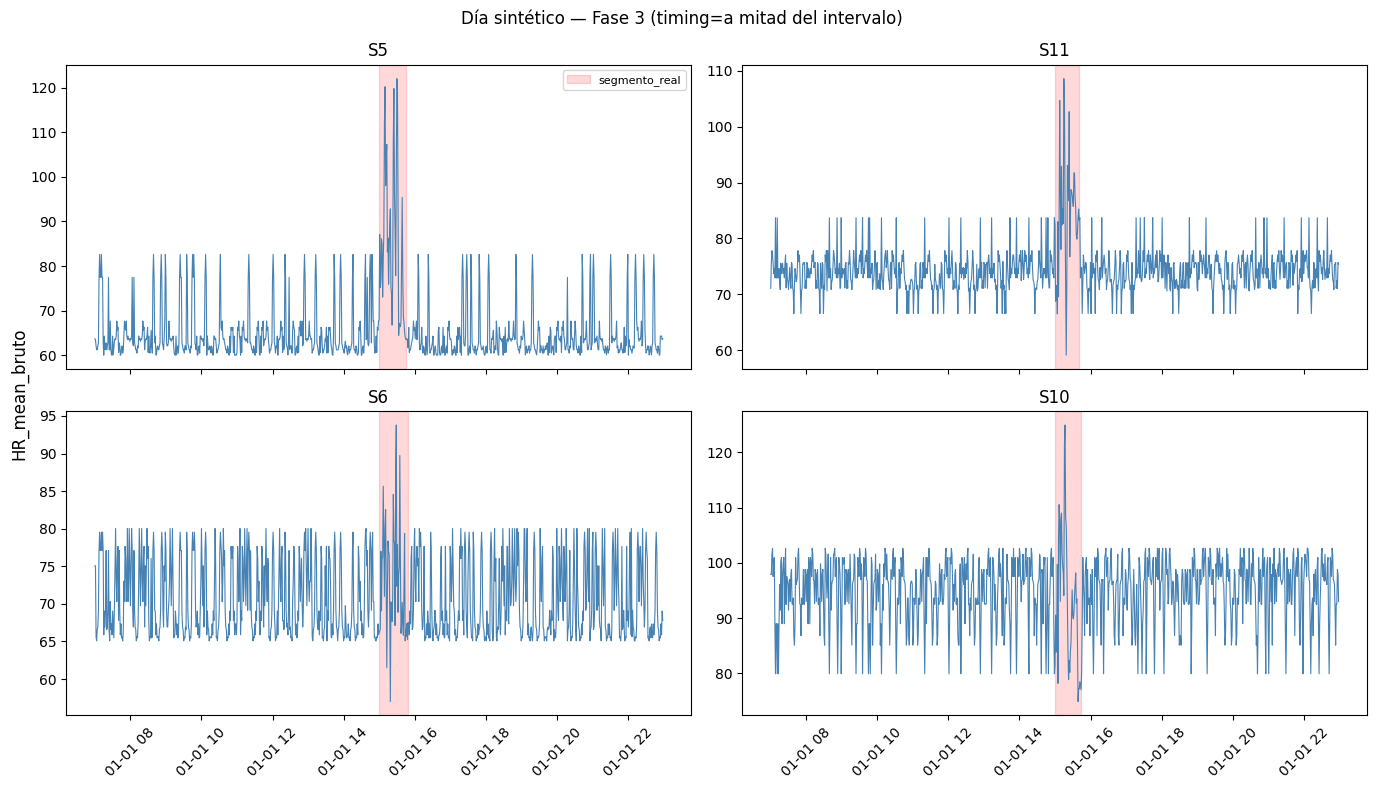

In [74]:
graficar_dia_sintetico(dias_sinteticos_fase3, SUJETOS_TODOS, titulo='Día sintético — Fase 3 (timing=a mitad del intervalo)')

Mismo patrón que en las dos fases anteriores: el *bout* real (franja roja, 15:00) es el pico más
alto del día en los 4 sujetos, y el aspecto cualitativo del fondo por sujeto se mantiene (S5/S11 con
picos dispersos, S6 con oscilación densa y sostenida, S10 con rango más amplio y elevado) — tercera
confirmación de que la contaminación de fondo depende del sujeto y la semilla, no del timing.

## 5.2. Demand(t), Coverage(t) y Risk(t) — primera combinación

Misma estructura que 4.2: Demand(t) = Demand_circadian(t) + D_ref·f(StressLoad(t)), Coverage(t) con
la pauta estándar, Risk(t) = Demand(t) − Coverage(t). Aquí el *bout* real cae a las 15:00, a mitad
de camino entre la toma de las 13:00 y la de las 17:00.

In [75]:
# ======================================================================================================
# 5.2. DEMAND(t) — FASE 3
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase3[sujeto]
    horas_del_dia = (df_dia['hora_reloj'] - df_dia['hora_reloj'].dt.normalize()) / pd.Timedelta(hours=1)
    df_dia['demand_circadian'] = demand_circadian(horas_del_dia.values)
    df_dia['f_stressload'] = df_dia['stress_pred'].rolling(window=VENTANA_F_STRESSLOAD_MIN, min_periods=1).mean()
    df_dia['demand_t'] = df_dia['demand_circadian'] + D_REF_MID * df_dia['f_stressload']

    print(f"{sujeto}: Demand_circadian(t) en [{df_dia['demand_circadian'].min():.3f}, {df_dia['demand_circadian'].max():.3f}] mg/h | "
          f"f(StressLoad) máximo = {df_dia['f_stressload'].max():.3f} | "
          f"Demand(t) en [{df_dia['demand_t'].min():.3f}, {df_dia['demand_t'].max():.3f}] mg/h")


S5: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 1.000 | Demand(t) en [0.103, 1.030] mg/h
S11: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 1.000 | Demand(t) en [0.103, 1.029] mg/h
S6: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 0.760 | Demand(t) en [0.103, 1.012] mg/h
S10: Demand_circadian(t) en [0.103, 0.716] mg/h | f(StressLoad) máximo = 0.600 | Demand(t) en [0.103, 0.808] mg/h


In [76]:
# ======================================================================================================
# 5.3. COVERAGE(t) Y RISK(t) — PRIMERA COMBINACIÓN, FASE 3
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase3[sujeto]
    fecha_dia_sintetico = df_dia['hora_reloj'].dt.normalize().iloc[0]
    schedule_dia = build_standard_schedule(fecha_dia_sintetico - pd.Timedelta(days=1), n_days=2)
    df_dia['coverage_t'] = compute_coverage(schedule_dia, df_dia['hora_reloj'], pk).values
    df_dia['risk_t'] = df_dia['demand_t'] - df_dia['coverage_t']

    print(f"{sujeto}: Coverage(t) en [{df_dia['coverage_t'].min():.3f}, {df_dia['coverage_t'].max():.3f}] mg/h "
          f"| Risk(t) en [{df_dia['risk_t'].min():.3f}, {df_dia['risk_t'].max():.3f}] mg/h")


S5: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.739, 0.737] mg/h
S11: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.739, 0.682] mg/h
S6: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.715, 0.836] mg/h
S10: Coverage(t) en [0.010, 2.455] mg/h | Risk(t) en [-1.739, 0.732] mg/h


f(StressLoad(t)) máximo vuelve a reproducir los mismos valores de las Fases 1 y 2 en los 4 sujetos
(1,000 en S5/S11, 0,760 en S6, 0,600 en S10) — tercera confirmación de que el techo alcanzado
durante el *bout* depende solo del clasificador sobre esos datos reales, no del timing.

Demand(t) máximo es el más bajo de las tres fases en los 4 sujetos (p. ej. S5: 1,030 frente a 1,075
en la Fase 2 y 1,283 en la Fase 1) — coherente con que las 15:00 están todavía más lejos del pico
circadiano que las 14:15 de la Fase 2.

Coverage(t) vuelve a ser idéntico en los 4 sujetos ([0,010, 2,455] mg/h).

Risk(t) máximo, a diferencia de las dos fases anteriores, **no coincide ni siquiera entre S5 y S11**
(0,737 y 0,682 respectivamente) — hasta ahora estos dos sujetos siempre habían dado exactamente el
mismo valor. Antes de interpretar esta diferencia, conviene repetir el mismo diagnóstico de origen
que en 4.2.1, ya que el patrón de las dos fases anteriores sugiere que el máximo global de Risk(t)
puede no estar relacionado con el *bout* de esta fase.

In [77]:
# ======================================================================================================
# DIAGNÓSTICO: ORIGEN DEL PICO DE RISK(t) — FASE 3 (mismo enfoque que 4.2.1)
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase3[sujeto]

    minuto_pico_risk = df_dia.loc[df_dia['risk_t'].idxmax()]
    minuto_valle_risk = df_dia.loc[df_dia['risk_t'].idxmin()]

    print(f"\n--- {sujeto} ---")
    print(f"Pico de Risk(t): {minuto_pico_risk['hora_reloj'].strftime('%H:%M')} "
          f"(Demand={minuto_pico_risk['demand_t']:.3f}, Coverage={minuto_pico_risk['coverage_t']:.3f}, "
          f"origen={minuto_pico_risk['origen']})")
    print(f"Valle de Risk(t): {minuto_valle_risk['hora_reloj'].strftime('%H:%M')} "
          f"(origen={minuto_valle_risk['origen']})")
    print(f"% del día con Risk(t) > 0 (infra-cobertura): {100*(df_dia['risk_t'] > 0).mean():.1f}%")


--- S5 ---
Pico de Risk(t): 07:16 (Demand=0.747, Coverage=0.011, origen=fondo_antes)
Valle de Risk(t): 08:45 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 4.1%

--- S11 ---
Pico de Risk(t): 07:30 (Demand=0.692, Coverage=0.010, origen=fondo_antes)
Valle de Risk(t): 08:45 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 4.1%

--- S6 ---
Pico de Risk(t): 07:20 (Demand=0.847, Coverage=0.010, origen=fondo_antes)
Valle de Risk(t): 08:57 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 7.3%

--- S10 ---
Pico de Risk(t): 07:07 (Demand=0.743, Coverage=0.011, origen=fondo_antes)
Valle de Risk(t): 08:45 (origen=fondo_antes)
% del día con Risk(t) > 0 (infra-cobertura): 4.1%


Confirmado: el pico de Risk(t) no tiene relación con el *bout* de la Fase 3 en ningún sujeto — cae
entre las 07:07 y las 07:30, con `origen=fondo_antes`, antes de que la primera dosis del día haga
efecto (Coverage(t)≈0,010-0,012 mg/h). Mismo valle previo a la primera toma que en la Fase 2 (Sección 4.2.1), y
es precisamente el motivo por el que S5 y S11 dejan de coincidir en esta fase: a diferencia del
*bout* real (idéntico en los 4 sujetos por construcción), el ruido de fondo de madrugada varía de
forma independiente entre sujetos, así que dos sujetos "limpios" ya no dan necesariamente el mismo
valor fuera de la ventana del *bout*.

Como en la Fase 2, el valor de Risk(t) máximo reportado en 5.2 no mide el efecto del *bout* de esta
fase — las métricas de aceptación (5.6) deben evaluarse en la ventana que cubre el *bout* real
(13:00-17:00).

## 5.3 Matriz completa: variantes de dosis y las 6 combinaciones (Fase 3)

Misma lógica que 4.3: la primera combinación (`alto_atiempo_valle`/`ninguno_atiempo_valle`, ya
calculada en 5.2) más las 4 variantes de dosis (`retrasada`/`omitida` cruzadas con estrés),
manipulando la toma de las 13:00 — la dosis inmediatamente anterior al *bout* de esta fase.

In [78]:
# ======================================================================================================
# MATRIZ COMPLETA DE LA FASE 3 — 6 COMBINACIONES
# ======================================================================================================
resultados_escenarios_fase3 = {sujeto: {} for sujeto in SUJETOS_TODOS}

for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase3[sujeto]
    fecha_dia_sintetico = df_dia['hora_reloj'].dt.normalize().iloc[0]
    demand_sin_estres = df_dia['demand_circadian'].values

    resultados_escenarios_fase3[sujeto]['alto_atiempo_valle'] = {
        'demand': df_dia['demand_t'].values, 'coverage': df_dia['coverage_t'].values, 'risk': df_dia['risk_t'].values,
    }
    resultados_escenarios_fase3[sujeto]['ninguno_atiempo_valle'] = {
        'demand': demand_sin_estres, 'coverage': df_dia['coverage_t'].values,
        'risk': demand_sin_estres - df_dia['coverage_t'].values,
    }

    schedule_base = build_standard_schedule(fecha_dia_sintetico - pd.Timedelta(days=1), n_days=2)
    for tipo, nombre_alto, nombre_ninguno in [
        ('retrasada', 'alto_retrasada_valle', 'ninguno_retrasada_valle'),
        ('omitida', 'alto_omitida_valle', 'ninguno_omitida_valle'),
    ]:
        schedule_variante = aplicar_variante_dosis(schedule_base, fecha_dia_sintetico, '13:00', tipo, RETRASO_HORAS)
        coverage_variante = compute_coverage(schedule_variante, df_dia['hora_reloj'], pk).values

        resultados_escenarios_fase3[sujeto][nombre_alto] = {
            'demand': df_dia['demand_t'].values, 'coverage': coverage_variante,
            'risk': df_dia['demand_t'].values - coverage_variante,
        }
        resultados_escenarios_fase3[sujeto][nombre_ninguno] = {
            'demand': demand_sin_estres, 'coverage': coverage_variante,
            'risk': demand_sin_estres - coverage_variante,
        }

    print(f"{sujeto}: {len(resultados_escenarios_fase3[sujeto])} combinaciones registradas (Fase 3)")


S5: 6 combinaciones registradas (Fase 3)
S11: 6 combinaciones registradas (Fase 3)
S6: 6 combinaciones registradas (Fase 3)
S10: 6 combinaciones registradas (Fase 3)


Las 6 combinaciones quedan registradas en `resultados_escenarios_fase3`, en los 4 sujetos, sin
incidencias.

### 5.3.1. Comparación gráfica de las 6 combinaciones — 4 sujetos

Mismo formato que 4.3.1. La franja roja marca aquí el *bout* real a las 15:00.

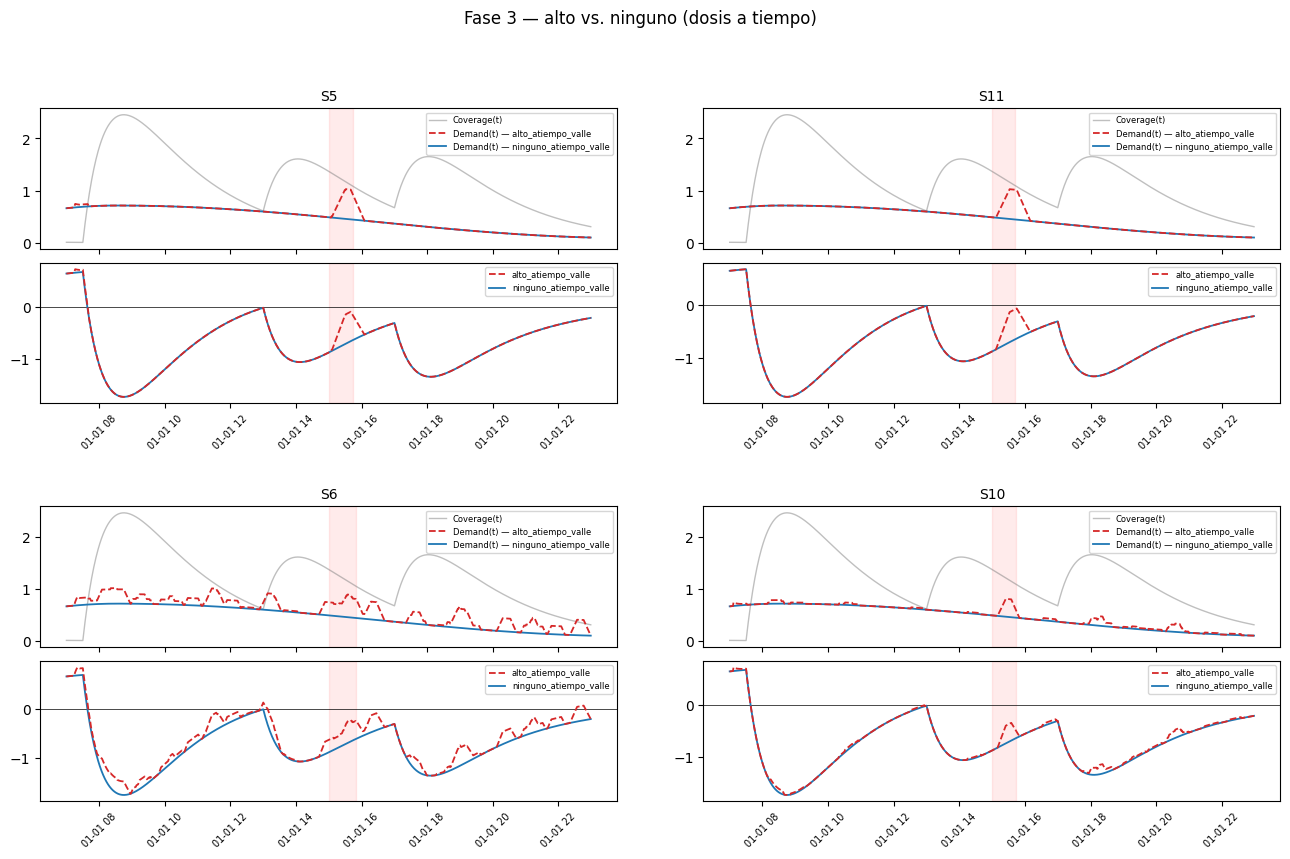

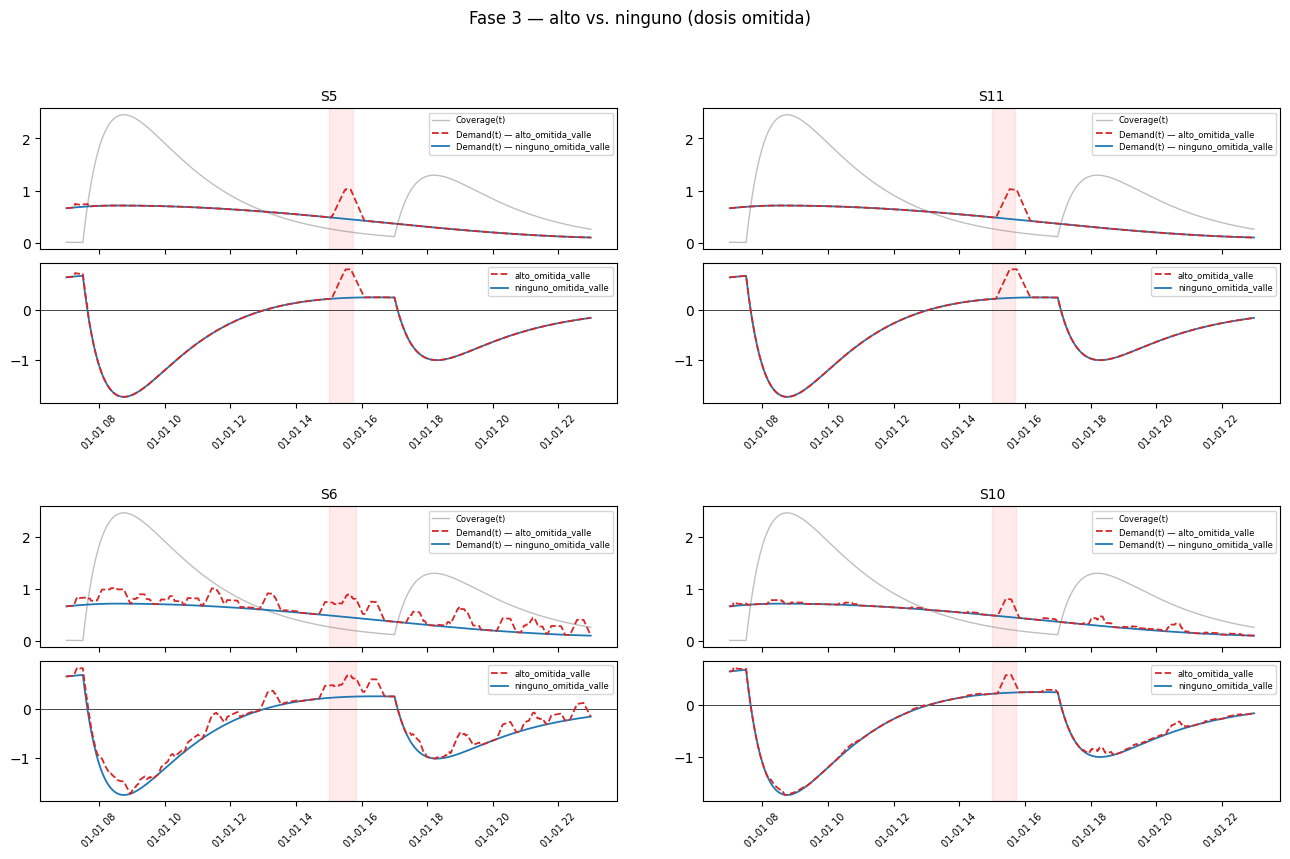

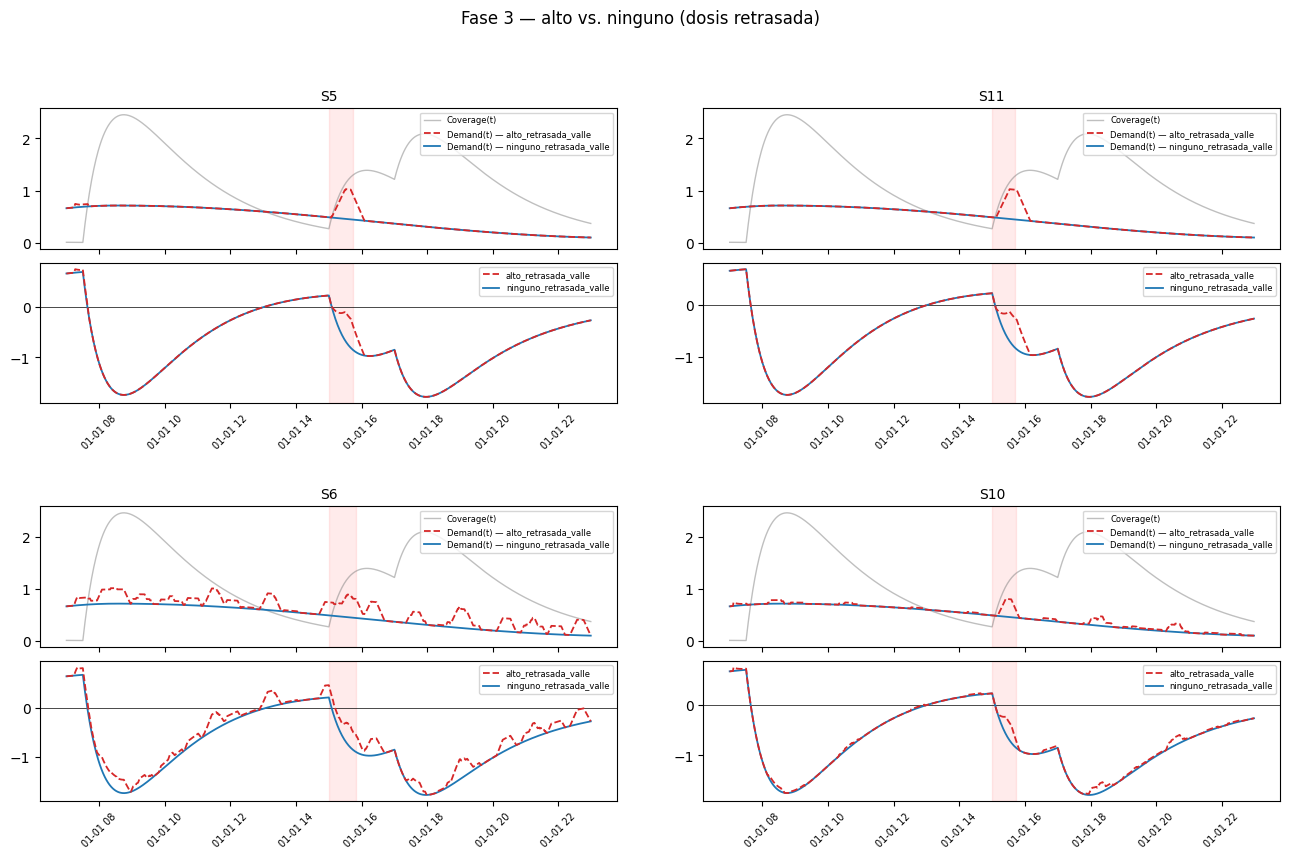

In [79]:
# A tiempo
graficar_comparacion_grid(dias_sinteticos_fase3, resultados_escenarios_fase3,
                           ['alto_atiempo_valle', 'ninguno_atiempo_valle'],
                           estilos={'alto_atiempo_valle': '--'},
                           titulo='Fase 3 — alto vs. ninguno (dosis a tiempo)')

# Omitida
graficar_comparacion_grid(dias_sinteticos_fase3, resultados_escenarios_fase3,
                           ['alto_omitida_valle', 'ninguno_omitida_valle'],
                           estilos={'alto_omitida_valle': '--'},
                           titulo='Fase 3 — alto vs. ninguno (dosis omitida)')

# Retrasada
graficar_comparacion_grid(dias_sinteticos_fase3, resultados_escenarios_fase3,
                           ['alto_retrasada_valle', 'ninguno_retrasada_valle'],
                           estilos={'alto_retrasada_valle': '--'},
                           titulo='Fase 3 — alto vs. ninguno (dosis retrasada)')

Mismo patrón cualitativo que en la Fase 2: en `atiempo`, Risk(t) se mantiene negativo durante todo
el *bout* (15:00, franja roja) en los 4 sujetos. En `omitida` y `retrasada`, Risk(t) sube por encima
de 0 justo en esa franja, con una subida más visible que en la Fase 2 — coherente con que a las
15:00 (mitad del intervalo) el margen de cobertura restante de la dosis de las 13:00 es menor que a
las 14:15, así que un retraso o una omisión de esa dosis deja un hueco de cobertura más claro.

El patrón se repite igual en los 4 sujetos, incluidos S6 y S10, por el mismo motivo que en la Fase 2:
el efecto observado aquí es de Coverage(t) (idéntico entre sujetos), no de Demand(t).

## 5.4. Funciones genéricas de métricas

Ya definidas en 3.4 y reutilizadas aquí sin cambios (parametrizadas por diccionario de resultados,
válidas para cualquier fase). No se repiten en este capítulo.

## 5.5 Verificación del mecanismo de persistencia de f(·) (Fase 3)

In [80]:
# ======================================================================================================
# FONDO PURO vs. BOUT REAL — FASE 3
# ======================================================================================================
for sujeto in SUJETOS_TODOS:
    df_dia = dias_sinteticos_fase3[sujeto]
    idx_fin_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[-1]
    idx_inicio_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[0]
    mask_fondo_puro = ((df_dia['origen'] != 'segmento_real') & (df_dia.index > idx_fin_segmento_real + VENTANA_F_STRESSLOAD_MIN))
    mask_fondo_puro = mask_fondo_puro | ((df_dia['origen'] != 'segmento_real') & (df_dia.index < idx_inicio_segmento_real))

    f_max_fondo_puro = df_dia.loc[mask_fondo_puro, 'f_stressload'].max()
    f_max_real = df_dia.loc[df_dia['origen'] == 'segmento_real', 'f_stressload'].max()
    ratio = 100 * f_max_fondo_puro / f_max_real if f_max_real > 0 else float('nan')

    print(f"{sujeto}: f_stressload máx. en fondo puro = {f_max_fondo_puro:.3f} | "
          f"máx. durante el bout real = {f_max_real:.3f} | ratio = {ratio:.1f}%")


S5: f_stressload máx. en fondo puro = 0.118 | máx. durante el bout real = 1.000 | ratio = 11.8%
S11: f_stressload máx. en fondo puro = 0.120 | máx. durante el bout real = 1.000 | ratio = 12.0%
S6: f_stressload máx. en fondo puro = 0.720 | máx. durante el bout real = 0.760 | ratio = 94.7%
S10: f_stressload máx. en fondo puro = 0.320 | máx. durante el bout real = 0.600 | ratio = 53.3%


In [81]:
# ======================================================================================================
# DIAGNÓSTICO: LOCALIZACIÓN DEL 11,8% EN S5 — FASE 3, FONDO PURO
# ======================================================================================================
sujeto = 'S5'
df_dia = dias_sinteticos_fase3[sujeto]
idx_fin_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[-1]
idx_inicio_segmento_real = df_dia[df_dia['origen'] == 'segmento_real'].index[0]
mask_fondo_puro = ((df_dia['origen'] != 'segmento_real') & (df_dia.index > idx_fin_segmento_real + VENTANA_F_STRESSLOAD_MIN))
mask_fondo_puro = mask_fondo_puro | ((df_dia['origen'] != 'segmento_real') & (df_dia.index < idx_inicio_segmento_real))

df_fondo_puro = df_dia.loc[mask_fondo_puro]
idx_max = df_fondo_puro['f_stressload'].idxmax()
fila_max = df_dia.loc[idx_max]

print(f"Pico de f_stressload en fondo puro (S5, Fase 3): {fila_max['hora_reloj'].strftime('%H:%M')} "
      f"| origen={fila_max['origen']} | f_stressload={fila_max['f_stressload']:.3f} "
      f"| stress_pred={fila_max['stress_pred']}")

# Contexto: ¿cuántos

Pico de f_stressload en fondo puro (S5, Fase 3): 07:16 | origen=fondo_antes | f_stressload=0.118 | stress_pred=1


**Conclusión — contaminación de fondo idéntica a las Fases 1 y 2 en 3 de los 4 sujetos; S5 rompe el
patrón con 11,8% (frente a 0,0% en las otras dos fases).**

S11 (12,0%), S6 (94,7%) y S10 (53,3%) se mantienen exactos en las tres fases. En S5, el 11,8% se
localiza en varios falsos positivos puntuales. No es ruido nuevo: es el mismo tramo
"sobrante" de `fondo_antes` (Sección 5.2), que en las Fases 1 y 2 no contenía ningún falso positivo
para S5, pero en la Fase 3 sí, al ser un contenido generado por bootstrap distinto por la diferente longitud
total de fondo requerida.

El mecanismo de persistencia sigue funcionando igual de bien: unos pocos minutos puntuales (fuera del propio bout) generan 11,8%
 en la ventana de 25 minutos, muy por debajo del 94,7%/53,3% de S6/S10,
que sí son ruido sostenido. La diferencia entre fases es un efecto del contenido concreto del fondo
generado en cada una, no una limitación distinta del filtro de persistencia.

## 5.6. Métricas de aceptacion

### 5.6.1 Kendall's τ por pares (Fase 3)

In [82]:
kendall_por_pares_generico(dias_sinteticos_fase3, resultados_escenarios_fase3, SUJETOS_TODOS,
                            hora_inicio_ventana="13:00", hora_fin_ventana="17:00")

S5: 7/9 pares limpios concordantes (78%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle'), ('ninguno_retrasada_valle', 'alto_retrasada_valle')]
S11: 7/9 pares limpios concordantes (78%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle'), ('ninguno_retrasada_valle', 'alto_retrasada_valle')]
S6: 8/9 pares limpios concordantes (89%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle')]
S10: 7/9 pares limpios concordantes (78%) | empates: [('ninguno_atiempo_valle', 'alto_atiempo_valle'), ('ninguno_retrasada_valle', 'alto_retrasada_valle')]


**Conclusión — pares limpios concordantes: 7/9 (78%) en S5, S11 y S10; 8/9 (89%) en S6.**

En S5, S11 y S10 hay dos empates (frente a uno en la Fase 2): `ninguno_atiempo < alto_atiempo` (Δ AUC = 0,0000 mg) y `ninguno_retrasada < alto_retrasada` (Δ AUC de 0,0003, 0,0000 y 0,0095 mg, bajo la tolerancia de 0,01 mg). Con el *bout* a las 15:00, la toma retrasada 2 h (13:00 → 15:00) llega justo en el instante del *bout*: el estrés no añade infra-cobertura medible a esa pauta. Es una consecuencia de la geometría del diseño (el retraso y el instante del *bout* no son independientes en esta fase), no una sensibilidad intrínseca del sistema al retraso.

S6 mantiene un solo empate (`ninguno_atiempo < alto_atiempo`, Δ AUC de 0,0075 mg): su contaminación de fondo añade `f(StressLoad(t))` espurio en `alto_*` y separa el segundo par, igual que en 3.6.1; no es una mejora real.

### 5.6.2 Ausencia de saltos abruptos (Fase 3)

In [83]:
saltos_abruptos_generico(dias_sinteticos_fase3, resultados_escenarios_fase3, SUJETOS_TODOS, HORAS_DOSIS_POR_COMBINACION_13H)


--- S5 ---
  ninguno_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.029 | ✅ sin saltos anómalos
  ninguno_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos
  alto_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  alto_retrasada_valle: percentil 95 = 0.031 | ✅ sin saltos anómalos
  alto_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos

--- S11 ---
  ninguno_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.029 | ✅ sin saltos anómalos
  ninguno_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos
  alto_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  alto_retrasada_valle: percentil 95 = 0.031 | ✅ sin saltos anómalos
  alto_omitida_valle: percentil 95 = 0.032 | ✅ sin saltos anómalos

--- S6 ---
  ninguno_atiempo_valle: percentil 95 = 0.034 | ✅ sin saltos anómalos
  ninguno_retrasada_valle: percentil 95 = 0.029 | ✅ sin saltos 

In [84]:
# ======================================================================================================
# DIAGNÓSTICO: LOCALIZACIÓN DEL SALTO ANÓMALO — S10, alto_retrasada_valle, FASE 3
# ======================================================================================================
sujeto = 'S10'
df_dia = dias_sinteticos_fase3[sujeto]
mask_fondo = df_dia['origen'] != 'segmento_real'
nombre = 'alto_retrasada_valle'

risk = np.asarray(resultados_escenarios_fase3[sujeto][nombre]['risk'])
derivada = np.diff(risk)
derivada_fondo = derivada[mask_fondo.values[1:]]
percentil_95 = np.percentile(np.abs(derivada_fondo), 95)
horas = df_dia['hora_reloj'].iloc[1:].reset_index(drop=True)

ventanas = construir_ventanas_esperadas_generico(df_dia, nombre, HORAS_DOSIS_POR_COMBINACION_13H)
saltos_anomalos = [
    (horas.iloc[i], d, df_dia['origen'].iloc[i+1]) for i, d in enumerate(derivada)
    if abs(d) > percentil_95 and not dentro_de_alguna_ventana(horas.iloc[i], ventanas)
]
print(f"{nombre}: percentil 95 = {percentil_95:.3f}")
for hora, delta, origen in saltos_anomalos:
    print(f"  Salto en {hora.strftime('%H:%M')} | Δ={delta:.3f} | origen={origen}")

alto_retrasada_valle: percentil 95 = 0.031
  Salto en 07:07 | Δ=0.072 | origen=fondo_antes
  Salto en 10:20 | Δ=0.032 | origen=fondo_antes
  Salto en 10:31 | Δ=0.032 | origen=fondo_antes


**Conclusión — ausencia de saltos abruptos (excluidos los primeros 25 minutos y las ventanas esperadas por diseño): sin saltos en las combinaciones sin estrés ni en S5/S11; con estrés, S6 acumula 10 saltos en `alto_retrasada_valle` y 7 en `alto_omitida_valle`, y S10, 2 en `alto_retrasada_valle`.**

El salto de S10 a las 07:07 (`fondo_antes`) cae dentro de los 25 minutos excluidos y no se cuenta; los 2 que quedan (10:20 y 10:31) se localizan en la celda anterior. Como en las otras fases, todos los saltos están en combinaciones con estrés y en los sujetos con falsos positivos de fondo sostenidos (S6, S10); no se ha comprobado minuto a minuto su origen. Como el umbral es el percentil 95 de la derivada del propio fondo, el recuento depende de las características de cada serie.

### 5.6.3 Robustez frente a ruido de sensor — Monte Carlo (Fase 3, 100 repeticiones)

Misma metodología que 3.6.3/4.6.3, ventana ajustada a esta fase (13:00-17:00).

In [85]:
monte_carlo_generico(dias_sinteticos_fase3, resultados_escenarios_fase3, SUJETOS_TODOS,
                      n_repeticiones=100, hora_inicio_ventana="13:00", hora_fin_ventana="17:00")


--- S5 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_retrasada_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ ninguno_atiempo_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_retrasada_valle: 100/100 (100%)
  ✅ alto_retrasada_valle < alto_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_omitida_valle: 100/100 (100%)

--- S11 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_retrasada_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ ninguno_atiempo_valle < ninguno_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_retrasada_valle: 100/100 (100%)
  ✅ alto_retrasada_valle < alto_omitida_valle: 100/100 (100%)
  ✅ alto_atiempo_valle < alto_omitida_valle: 100/100 (100%)

--- S6 ---
Pares genuinamente puestos a prueba:
  ✅ ninguno_atiempo_valle < ninguno_retrasada_valle: 100/100 (100%)
  ✅ ninguno_

**Conclusión — los 6 pares genuinos al 100% en los 4 sujetos.** Como en las Fases 1 y 2, el orden de severidad entre patrones de dosis se mantiene en las 100 repeticiones; refleja la robustez de la señal de dosis frente al ruido de HR, no la del clasificador para detectar estrés.

## 5.7 Conclusiones de la Fase 3

**Matriz completa:** 6 de 6 combinaciones (2 niveles de estrés × 3 patrones de dosis, timing=mitad
del intervalo 13:00-17:00) calculadas para los 4 sujetos reservados (S5, S6, S10, S11).

**Pares limpios concordantes (Sección 5.6.1):** 7/9 (78%) en S5, S11 y S10; 8/9 (89%) en S6. Los pares sin concordancia son empates, no inversiones: además del de la dosis a tiempo (`ninguno_atiempo`/`alto_atiempo`), aparece `ninguno_retrasada`/`alto_retrasada`, porque la toma retrasada 2 h llega a las 15:00h, instante del *bout*, y el estrés no añade infra-cobertura medible. S6 mantiene un solo empate: su contaminación de fondo separa el segundo par, no es una mejora real.

**Ausencia de saltos abruptos (Sección 5.6.2):** sin saltos en las combinaciones sin estrés ni en S5/S11; con estrés, S6 (10 en `alto_retrasada`, 7 en `alto_omitida`) y S10 (2 en `alto_retrasada`), compatibles con cambios de decisión del clasificador que desplazan f(t).

**Robustez Monte Carlo (Sección 5.6.3):** 6 de 6 pares genuinos al 100% en los 4 sujetos.

**Mecanismo de persistencia de f(·) (Sección 5.5):** idéntico a las Fases 1 y 2 en S11 (12,0%), S6
(94,7%) y S10 (53,3%). S5 rompe el patrón con 11,8% (frente a 0,0% en las otras dos fases) — falsos positivos puntuales
 en el mismo instante de madrugada ya identificado en 5.2.1, atribuibles
al contenido concreto del fondo generado por bootstrap generado para esta fase, no a un cambio en el
mecanismo de filtrado.

**Comparación con las Fases 1 y 2:** el pico de Risk(t) de la "primera combinación" (5.2) tampoco es comparable entre fases sin matizar, por el mismo valle previo a la primera toma. La comparación válida sigue siendo el AUC en la ventana relevante: sin estrés, omitida > retrasada > a tiempo en las tres fases (en la Fase 3, 0,7419 > 0,2669 > 0,0000 mg), pero la contribución del estrés a la dosis retrasada es prácticamente nula (0,0000-0,0095 mg en S5, S10 y S11), porque el retraso de 2 h hace coincidir la llegada de la dosis con el inicio del *bout*.


# 6. Conclusiones generales


Objetivo de este capítulo: sintetizar qué demuestra la validación de escenarios sintéticos en
conjunto (coherencia interna del sistema) —
no repetir las conclusiones de cada fase, sino cruzarlas.

## 6.1 Tabla comparativa entre las tres fases

| Métrica | Fase 1 (valle) | Fase 2 (justo tras la toma) | Fase 3 (mitad del intervalo) |
|---|---|---|---|
| Timing exacto | 07:30 | 14:15 | 15:00 |
| Pares concordantes (S5/S11) | 8/9 (89%) | 8/9 (89%) | 7/9 (78%) |
| Pares concordantes (S10) | 9/9 (100%) | 8/9 (89%) | 7/9 (78%) |
| Pares concordantes (S6) | 9/9 (100%, contaminado) | 8/9 (89%) | 8/9 (89%) |
| Saltos abruptos (series con saltos, de 24) | 6 (solo con estrés) | 0 | 3 (solo con estrés) |
| Monte Carlo (pares genuinos) | 6/6 en 100% | 6/6 en 100% | 6/6 en 100% |
| Persistencia f(·) — fondo puro S5 | 0,0% | 0,0% | 11,8% |
| Persistencia f(·) — fondo puro S11 | 12,0% | 12,0% | 12,0% |
| Persistencia f(·) — fondo puro S6 | 94,7% | 94,7% | 94,7% |
| Persistencia f(·) — fondo puro S10 | 53,3% | 53,3% | 53,3% |

Los saltos se concentran en S6 y S10 y en combinaciones con estrés. Se retira la fila del pico de Risk(t), que no es comparable entre fases: en las tres está dominado por el valle previo a la primera toma, no por el *bout* insertado.

## 6.2 Preguntas a responder con la comparación entre fases

**¿El timing más próximo a la toma (Fase 2) reduce el riesgo máximo respecto al valle (Fase 1)?**
No de la forma en que se planteó la pregunta: el "riesgo máximo" global no es una medida válida del efecto del *bout* en ninguna de las tres fases (lo domina el valle previo a la primera toma). La comparación correcta es el AUC en la ventana relevante. Sin estrés, el orden omitida > retrasada > a tiempo se cumple en las tres fases; lo que varía es cuánto añade el estrés a esa infra-cobertura: es pequeño con la dosis a tiempo y se concentra en las dosis retrasadas u omitidas, y en la Fase 3 es prácticamente nulo para la dosis retrasada, porque el retraso de 2 h hace coincidir la llegada de la dosis con el inicio del *bout*. Esta lectura es consecuencia de la geometría del diseño, no una sensibilidad intrínseca del sistema al retraso, y no hay un gradiente monótono entre fases.

**¿El mecanismo de persistencia se sostiene igual en las tres fases?** En S11, S6 y S10, sí, de
forma exacta. En S5, no: 0,0% en las Fases 1 y 2, pero 11,8% en la Fase 3 (Sección 5.5) — no por un
cambio en el propio mecanismo de filtrado, sino porque el contenido concreto del fondo generado por bootstrap
antes del *bout* depende de la duración total de fondo requerida en cada fase, no
solo de la posición fisiológica del *bout* en el ciclo de dosis.

**¿Cambia el par discordante de Kendall's τ en las Fases 2 y 3, donde el valle previo a la primera toma ya no coincide con el *bout*?**
El par `ninguno_atiempo_valle` vs. `alto_atiempo_valle` sigue en empate en las tres fases, pero por motivos distintos: en la Fase 1, por la coincidencia entre el valle previo a la primera toma y el *bout*; en las Fases 2 y 3, porque Coverage(t) cubre sobradamente Demand(t) durante el *bout* con la dosis a tiempo. En la Fase 3 aparece además un segundo empate (`ninguno_retrasada`/`alto_retrasada`) en S5, S11 y S10, por la coincidencia entre la llegada de la dosis retrasada (15:00) y el *bout*.

**¿Sigue siendo necesaria la distinción entre pares "genuinos" y "garantizados" en las otras
fases?** Sí, sin cambios: la garantía algebraica (Demand(alto,t) ≥ Demand(ninguno,t) para el mismo
Coverage(t)) no depende del timing del *bout*, así que los 3 pares `ninguno` vs. `alto` quedan fuera
del reporte de Monte Carlo en las tres fases por el mismo motivo.

## 6.3 Conclusión general de la validación mediante escenarios sintéticos

La validación mediante escenarios sintéticos demuestra coherencia interna del sistema —no validez
externa frente a datos clínicos reales, que Demand(t) no puede tener por la ausencia estructural de
ground truth —, sostenida a través de tres timings distintos y 18 combinaciones en
total. Tres resultados se sostienen sin excepción en las tres fases: Coverage(t) depende únicamente
del `schedule` de dosis, nunca de Demand(t) ni del sujeto; el mecanismo de persistencia de 25 min de
f(StressLoad(t)) distingue con el mismo patrón el ruido disperso (S5/S11, filtrado casi por
completo) del ruido sostenido (S6/S10, con un modo de fallo acotado y caracterizado); y la
separación entre pares "genuinos" y "garantizados por construcción" en el análisis Monte Carlo es
estructural, no una particularidad de una fase concreta.

Donde el sistema sí responde al timing, lo hace de forma coherente con el diseño: sin estrés, omitida > retrasada > a tiempo en las tres fases, y la contribución del estrés a ese orden es pequeña con la dosis a tiempo y se concentra en las dosis retrasadas u omitidas. La validación no pone a prueba la detección del estrés: el orden alto ≥ ninguno es algebraico y, con la dosis a tiempo, esos pares empatan.

Las limitaciones declaradas (contaminación de fondo en S6/S10, valle previo a la primera toma en el pico global de Risk(t), sensibilidad del contenido del fondo generado por bootstrap, y la coincidencia entre el retraso de la dosis y el instante del *bout* en la Fase 3) son consistentes entre fases y ya están caracterizadas en cada capítulo; el criterio de saltos, además, depende del percentil 95 del propio fondo y se reporta como recuento.

# Apendice

In [86]:
import pandas as pd

fases = {
    'Fase 1': (dias_sinteticos_fase1, resultados_escenarios_fase1, "07:00", "13:00"),
    'Fase 2': (dias_sinteticos_fase2, resultados_escenarios_fase2, "13:00", "17:00"),
    'Fase 3': (dias_sinteticos_fase3, resultados_escenarios_fase3, "13:00", "17:00"),
}

filas = []
for nombre_fase, (dias, resultados, h_ini, h_fin) in fases.items():
    for sujeto in SUJETOS_TODOS:
        aucs = calcular_aucs(dias, resultados, sujeto, h_ini, h_fin)
        for combo, valor in aucs.items():
            filas.append({'Fase': nombre_fase, 'Sujeto': sujeto, 'Combinación': combo, 'AUC (mg)': round(valor, 4)})

df_b1 = pd.DataFrame(filas)
df_b1_pivot = df_b1.pivot_table(index=['Fase', 'Combinación'], columns='Sujeto', values='AUC (mg)')
print(df_b1_pivot.to_string())

Sujeto                             S10     S11      S5      S6
Fase   Combinación                                            
Fase 1 alto_atiempo_valle       0.1126  0.1022  0.1051  0.2159
       alto_omitida_valle       4.0703  4.1398  4.1113  4.6335
       alto_retrasada_valle     1.6749  1.8744  1.8459  1.9855
       ninguno_atiempo_valle    0.1018  0.1018  0.1018  0.1018
       ninguno_omitida_valle    3.7788  3.7788  3.7788  3.7788
       ninguno_retrasada_valle  1.5134  1.5134  1.5134  1.5134
Fase 2 alto_atiempo_valle       0.0000  0.0000  0.0000  0.0001
       alto_omitida_valle       0.9129  1.1029  1.0744  1.3167
       alto_retrasada_valle     0.4189  0.5816  0.5733  0.6038
       ninguno_atiempo_valle    0.0000  0.0000  0.0000  0.0000
       ninguno_omitida_valle    0.7419  0.7419  0.7419  0.7419
       ninguno_retrasada_valle  0.2669  0.2669  0.2669  0.2669
Fase 3 alto_atiempo_valle       0.0000  0.0000  0.0000  0.0075
       alto_omitida_valle       0.9129  1.1029  1.0744 

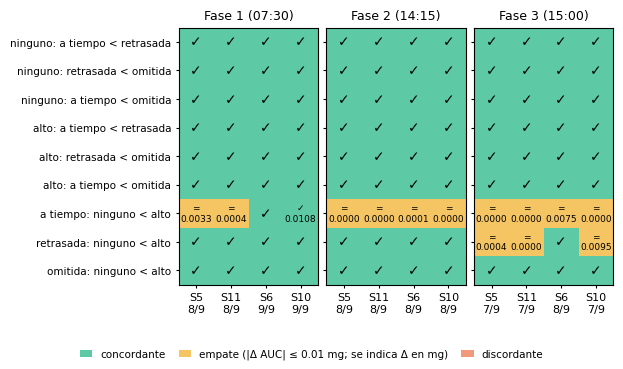

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

ANCHO_IN, ALTO_IN = 6.3, 3.7          # 16 cm de ancho útil en A4: se inserta al 100 %, sin reescalar
FS_TICK, FS_LAB, FS_TIT, FS_CELL, FS_DELTA = 8, 7.5, 9, 10, 6.5

fases = [
    ("Fase 1 (07:30)", dias_sinteticos_fase1, resultados_escenarios_fase1, "07:00", "13:00"),
    ("Fase 2 (14:15)", dias_sinteticos_fase2, resultados_escenarios_fase2, "13:00", "17:00"),
    ("Fase 3 (15:00)", dias_sinteticos_fase3, resultados_escenarios_fase3, "13:00", "17:00"),
]

def _etiqueta_par(par):
    a, b = [p.replace("_valle", "") for p in par]
    ea, pa = a.split("_"); eb, pb = b.split("_")
    pa, pb = pa.replace("atiempo", "a tiempo"), pb.replace("atiempo", "a tiempo")
    return f"{ea}: {pa} < {pb}" if ea == eb else f"{pa}: {ea} < {eb}"

cmap = ListedColormap(["#F0997B", "#F5C563", "#5DCAA5"])   # discordante / empate / concordante
fig, axes = plt.subplots(1, 3, figsize=(ANCHO_IN, ALTO_IN), sharey=True)
for ax, (titulo, dias, res, ini, fin) in zip(axes, fases):
    clase = np.zeros((len(PARES_LIMPIOS), len(SUJETOS_TODOS)))
    delta = np.zeros_like(clase)
    for j, s in enumerate(SUJETOS_TODOS):
        aucs = calcular_aucs(dias, res, s, ini, fin)
        for i, (menor, mayor) in enumerate(PARES_LIMPIOS):
            delta[i, j] = aucs[mayor] - aucs[menor]
            clase[i, j] = comparar_auc(aucs[menor], aucs[mayor]) + 1      # 0, 1 ó 2
    ax.imshow(clase, cmap=cmap, vmin=0, vmax=2, aspect="auto")
    for i in range(clase.shape[0]):
        for j in range(clase.shape[1]):
            if clase[i, j] == 2 and delta[i, j] < 2 * TOL_EMPATE_MG:      # concordante por poco margen
                ax.text(j, i, f"✓\n{delta[i, j]:.4f}", ha="center", va="center", fontsize=FS_DELTA)
            elif clase[i, j] == 2:
                ax.text(j, i, "✓", ha="center", va="center", fontsize=FS_CELL)
            elif clase[i, j] == 1:
                ax.text(j, i, f"=\n{delta[i, j]:.4f}", ha="center", va="center", fontsize=FS_DELTA)
            else:
                ax.text(j, i, "✗", ha="center", va="center", fontsize=FS_CELL)
    n_conc = (clase == 2).sum(axis=0)
    ax.set_xticks(range(len(SUJETOS_TODOS)))
    ax.set_xticklabels([f"{s}\n{n}/{len(PARES_LIMPIOS)}" for s, n in zip(SUJETOS_TODOS, n_conc)], fontsize=FS_TICK)
    ax.set_yticks(range(len(PARES_LIMPIOS)))
    ax.set_yticklabels([_etiqueta_par(p) for p in PARES_LIMPIOS], fontsize=FS_LAB)
    ax.set_title(titulo, fontsize=FS_TIT)
    ax.tick_params(length=2)
leyenda = [Patch(facecolor="#5DCAA5", label="concordante"),
           Patch(facecolor="#F5C563", label=f"empate (|Δ AUC| ≤ {TOL_EMPATE_MG} mg; se indica Δ en mg)"),
           Patch(facecolor="#F0997B", label="discordante")]
fig.legend(handles=leyenda, loc="lower center", ncol=3, frameon=False, fontsize=FS_TICK - 0.5,
           handlelength=1.2, columnspacing=1.2)
fig.subplots_adjust(left=0.30, right=0.99, top=0.91, bottom=0.215, wspace=0.06)
# plt.savefig("ilustracion_concordancia_pares.png", dpi=300)       # sin bbox_inches="tight": conserva los 16 cm
plt.show()

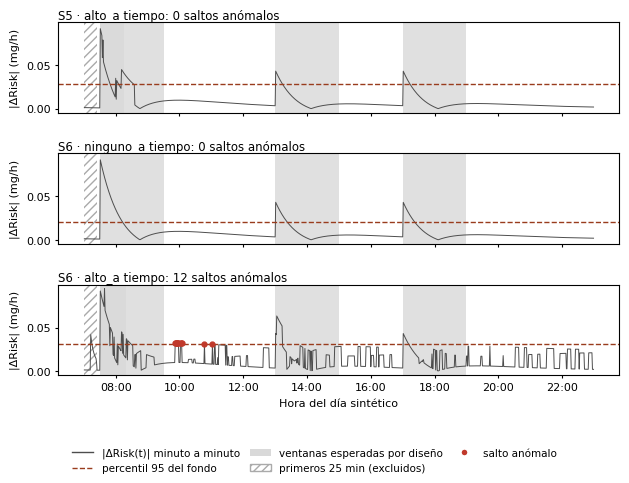

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

ANCHO_IN, ALTO_IN = 6.3, 4.8
FS_TICK, FS_LAB, FS_TIT = 8, 8, 8.5

casos = [("S5", "alto_atiempo_valle"), ("S6", "ninguno_atiempo_valle"), ("S6", "alto_atiempo_valle")]
dias, res = dias_sinteticos_fase1, resultados_escenarios_fase1      # Fase 1: sin horas de dosis explícitas

fig, axes = plt.subplots(len(casos), 1, figsize=(ANCHO_IN, ALTO_IN), sharex=True, sharey=True)
for ax, (sujeto, nombre) in zip(axes, casos):
    df = dias[sujeto]
    horas_all = df["hora_reloj"]
    t_ini = horas_all.iloc[0] + pd.Timedelta(minutes=MIN_CALENTAMIENTO)
    mask_fondo = (df["origen"] != "segmento_real").values
    mask_ok = (horas_all >= t_ini).values
    d = np.diff(np.asarray(res[sujeto][nombre]["risk"]))
    horas = horas_all.iloc[1:].reset_index(drop=True)
    p95 = np.percentile(np.abs(d[(mask_fondo & mask_ok)[1:]]), 95)
    ventanas = construir_ventanas_esperadas_generico(df, nombre)
    en_ventana = np.array([dentro_de_alguna_ventana(h, ventanas) for h in horas])
    anomalo = (np.abs(d) > p95) & (horas >= t_ini).values & ~en_ventana

    ax.axvspan(horas_all.iloc[0], t_ini, facecolor="none", edgecolor="#AAAAAA", hatch="////", lw=0)
    for ini, fin in ventanas:
        ax.axvspan(ini, fin, color="#D9D9D9", alpha=0.8, lw=0)
    ax.plot(horas, np.abs(d), color="#4D4D4D", lw=0.7)
    ax.axhline(p95, color="#993C1D", ls="--", lw=1)
    ax.plot(horas[anomalo], np.abs(d)[anomalo], "o", color="#C0392B", ms=3.5, zorder=5)
    ax.set_title(f"{sujeto} · {nombre.replace('_valle', '').replace('atiempo', 'a tiempo')}: {anomalo.sum()} saltos anómalos",
                 fontsize=FS_TIT, loc="left", pad=2)
    ax.tick_params(labelsize=FS_TICK, length=2)
    ax.set_ylabel("|ΔRisk| (mg/h)", fontsize=FS_LAB)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[-1].set_xlabel("Hora del día sintético", fontsize=FS_LAB)
leyenda = [Line2D([0], [0], color="#4D4D4D", lw=1, label="|ΔRisk(t)| minuto a minuto"),
           Line2D([0], [0], color="#993C1D", ls="--", lw=1, label="percentil 95 del fondo"),
           Patch(facecolor="#D9D9D9", label="ventanas esperadas por diseño"),
           Patch(facecolor="none", edgecolor="#AAAAAA", hatch="////", label="primeros 25 min (excluidos)"),
           Line2D([0], [0], marker="o", color="w", markerfacecolor="#C0392B", ms=5, label="salto anómalo")]
fig.legend(handles=leyenda, loc="lower center", ncol=3, frameon=False, fontsize=FS_TICK - 0.5, columnspacing=1.0)
fig.subplots_adjust(left=0.10, right=0.99, top=0.95, bottom=0.215, hspace=0.45)
# plt.savefig("ilustracion_saltos.png", dpi=300)       # sin bbox_inches="tight"
plt.show()